# NeqSim × Equinor TimeSeriesAnalysis
## From a large process model to an explainable dynamic digital twin

**An executable engineering mini-book · synthetic gas-processing facility · Python, Java and .NET**

[Open in Colab](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/advanced_analytics/neqsim_timeseriesanalysis_large_process.ipynb)

How can we use a thermodynamic simulator and industrial time-series models together to make better operating decisions? This notebook builds a six-train facility, checks its balances, learns dynamic responses, detects a compressor-efficiency change and evaluates constrained load allocation. It then uses **PlantSimulator** for steady replay, dynamic networks, six simultaneous PID feedback loops, shared disturbances and scaling to 194 connected models.

The actual Equinor [TimeSeriesAnalysis](https://github.com/equinor/TimeSeriesAnalysis) .NET library is called through Python.NET. NeqSim is called through JPype. No commercial simulator, historian credentials or proprietary plant data are required.

### Reading route

1. **Reproducible setup:** load both runtimes and prove their origins.
2. **Steady-state facility:** six composable NeqSim trains, a common export header and balance audits.
3. **Steady analytics:** operating envelopes and constrained load allocation, with full-physics replay.
4. **Dynamic analytics:** physical thermal storage, system identification and chronological validation.
5. **Plant analytics:** connected models, compressor diagnostics and six PID feedback loops.
6. **Scale and handoff:** measured timing, validity limits, machine-readable outputs and exercises.

**Model boundary.** The steady process uses NeqSim equipment and SRK phase equilibrium. Dynamics use an explicitly defined lumped thermal balance and TimeSeriesAnalysis reduced models. These are real time-dependent calculations, but they do not resolve vessel phase inventories, pipeline waves, compressor surge or native NeqSim transient equipment. The distinction matters when choosing a model for an operating decision.

**This revision:** explicit Python interface tests, native PlantSimulator feedback and PID limits, graph serialization, repeatability, and a portable binding-comparison case for the proposed Equinor Python wrapper. See Section 1.1 for wrapper availability.

**New cases in Sections 10–12:** turn native process input JSON into a directed material graph, find recycle groups, compare two engineered condensate-return routes, optimize separator pressures in NeqSim, and build an eight-model local dynamic projection in TSA. The original facility, identification, diagnostic, PID and interoperability cases remain available.


**TSA-led full-process extension (Sections 12.1–12.5):** native multivariable identification, static/dynamic validation, TSA-assisted setpoint search, an 11-model PlantSimulator with two PidModels, native residual filtering and serialized model handoff. NeqSim supplies nonlinear equilibrium and conservation; TSA learns and executes time-dependent responses. Read the responsibility table below before interpreting the synthetic results.

| Task | NeqSim contributes | TimeSeriesAnalysis contributes |
|---|---|---|
| Define the process | EOS, equipment, material connections and recycle closure | Named time-series inputs/outputs and model connections |
| Learn normal response | Nonlinear operating-point targets for synthetic experiments | `UnitIdentifier` fits gains, bias and response time; static reference fit |
| Improve operation | Verify power, recovery, utility and temperature constraints | Learned equilibrium predictions accelerate a bounded setpoint search |
| Implement a move | Fresh nonlinear checks at accepted conditions | `PlantSimulator` executes native PID feedback and connected learned responses |
| Diagnose deviations | Physical efficiency-change scenario and independent temperature evidence | Predicted responses and causal `LowPass` residual filtering |
| Reuse the result | Accepted native process input JSON | Serialized learned plant, parameter and tag/units contract |

SciPy orchestrates the constrained search; it is not a TSA optimizer. Pandas and NumPy handle tables, arrays and metrics. The simulator and identification calculations remain in their respective native libraries.


## 1. Reproducible setup

Run in a **fresh Linux x86-64 Colab runtime** with Python 3.12 and Java 17 or later. The first run downloads a pinned .NET SDK and compiles a pinned NeqSim master revision; allow several minutes and roughly 1 GB of free disk space. Subsequent calculations reuse the runtimes. Restart the notebook runtime before changing either Java or .NET assemblies.

The NeqSim revision below was master when this notebook was prepared. Pinning it makes the saved results reproducible. TimeSeriesAnalysis 1.4.38 is obtained from NuGet, including its declared dependencies. The older Python examples in its source repository do not all use the current signatures; the calls here have been executed against the pinned assembly.

An optional `NEQSIM_VALIDATED_RUNTIME` manifest supports an already compiled, audited local runtime. Its source revision and JAR hash must match. This is the route used for the saved execution; the fresh-Colab download/build route is provided but was not independently exercised in Google's hosted service.

In [1]:
import hashlib
import importlib.metadata as metadata
import json
import os
from pathlib import Path
import platform
import shutil
import subprocess
import sys
import tarfile
import time
import urllib.request
import zipfile

PYTHON_PACKAGES = {
    "numpy": "2.3.5",
    "pandas": "2.2.3",
    "scipy": "1.17.0",
    "matplotlib": "3.10.8",
    "JPype1": "1.7.1",
    "pythonnet": "3.1.0",
    "networkx": "3.5",
}
missing = []
for package, required_version in PYTHON_PACKAGES.items():
    try:
        present_version = metadata.version(package)
    except metadata.PackageNotFoundError:
        present_version = None
    if present_version != required_version:
        missing.append(f"{package}=={required_version}")
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

NEQSIM_SOURCE_REF = "1165998ef6a4658ee7ee1bff05bde327c3801178"
TSA_VERSION = "1.4.38"
SDK_VERSION = "8.0.414"
SDK_SHA512 = (
    "bdf6b151f787ac57d393e625e8b8fc8e19ac75902e76227da736f20e042cf7ff9"
    "8bfd1a6669b77fdea7bfe678a0f23103e0cace1db83e9aee568ccd6f1b5b264"
)
work = Path("neqsim_tsa_runtime").resolve()
work.mkdir(exist_ok=True)
manifest_path = os.environ.get("NEQSIM_VALIDATED_RUNTIME")


def run_logged(command, cwd, filename, env=None):
    log = work / filename
    with log.open("w") as handle:
        result = subprocess.run(command, cwd=cwd, env=env, stdout=handle, stderr=handle)
    if result.returncode:
        raise RuntimeError(f"Command failed; inspect {log}\n{log.read_text()[-5000:]}")


if manifest_path:
    runtime = json.loads(Path(manifest_path).read_text())
    assert runtime["source_commit"] == NEQSIM_SOURCE_REF
    source_root = Path(runtime["source_root"])
    source_jar = Path(runtime["jar"])
    assert hashlib.sha256(source_jar.read_bytes()).hexdigest() == runtime["jar_sha256"]
    dotnet_root = Path(runtime["dotnet_root"])
    tsa_dir = Path(runtime["tsa_dir"])
    setup_route = "Audited prebuilt source and .NET runtime"
else:
    assert platform.system() == "Linux" and platform.machine() in ("x86_64", "AMD64")
    source_root = work / "neqsim-source"
    if not (source_root / ".git").exists():
        source_root.mkdir(exist_ok=True)
        run_logged(["git", "init"], source_root, "git-init.log")
        run_logged(
            ["git", "remote", "add", "origin", "https://github.com/equinor/neqsim.git"],
            source_root,
            "git-remote.log",
        )
        run_logged(
            ["git", "fetch", "--depth", "1", "origin", NEQSIM_SOURCE_REF],
            source_root,
            "git-fetch.log",
        )
        run_logged(["git", "checkout", "--detach", "FETCH_HEAD"], source_root, "git.log")
    resolved = subprocess.check_output(
        ["git", "rev-parse", "HEAD"], cwd=source_root, text=True
    ).strip()
    assert resolved == NEQSIM_SOURCE_REF
    if not shutil.which("javac"):
        run_logged(["apt-get", "update", "-qq"], work, "apt-update.log")
        run_logged(
            ["apt-get", "install", "-y", "-qq", "openjdk-17-jdk-headless"],
            work,
            "jdk-install.log",
        )
    run_logged(
        [
            "bash",
            "mvnw",
            "-q",
            "-Dmaven.test.skip=true",
            "-Dspotless.skip=true",
            "compile",
            "dependency:copy-dependencies",
            "-DincludeScope=runtime",
        ],
        source_root,
        "neqsim-build.log",
    )
    source_jar = source_root / "target/neqsim-verified.jar"
    with zipfile.ZipFile(source_jar, "w", zipfile.ZIP_DEFLATED) as archive:
        for item in sorted((source_root / "target/classes").rglob("*")):
            if item.is_file():
                archive.write(item, item.relative_to(source_root / "target/classes"))
    dotnet_root = work / "dotnet"
    if not (dotnet_root / "dotnet").exists():
        sdk_archive = work / "dotnet-sdk.tar.gz"
        sdk_url = (
            f"https://builds.dotnet.microsoft.com/dotnet/Sdk/{SDK_VERSION}/"
            f"dotnet-sdk-{SDK_VERSION}-linux-x64.tar.gz"
        )
        urllib.request.urlretrieve(sdk_url, sdk_archive)
        assert hashlib.sha512(sdk_archive.read_bytes()).hexdigest() == SDK_SHA512
        with tarfile.open(sdk_archive) as archive:
            archive.extractall(dotnet_root, filter="data")
    bridge = work / "bridge"
    bridge.mkdir(exist_ok=True)
    project = bridge / "TsaBridge.csproj"
    project.write_text(
        '<Project Sdk="Microsoft.NET.Sdk"><PropertyGroup>'
        "<TargetFramework>net8.0</TargetFramework>"
        "<GenerateRuntimeConfigurationFiles>true</GenerateRuntimeConfigurationFiles>"
        "<CopyLocalLockFileAssemblies>true</CopyLocalLockFileAssemblies>"
        "</PropertyGroup><ItemGroup>"
        f'<PackageReference Include="TimeSeriesAnalysis" Version="{TSA_VERSION}" />'
        "</ItemGroup></Project>"
    )
    tsa_dir = work / "tsa"
    build_env = dict(os.environ, DOTNET_ROOT=str(dotnet_root), DOTNET_CLI_TELEMETRY_OPTOUT="1")
    run_logged(
        [
            str(dotnet_root / "dotnet"),
            "publish",
            str(project),
            "-c",
            "Release",
            "-o",
            str(tsa_dir),
            "-v",
            "quiet",
        ],
        work,
        "tsa-build.log",
        build_env,
    )
    setup_route = "Pinned source build and pinned NuGet restore"
print(setup_route)
print("NeqSim source:", NEQSIM_SOURCE_REF)
print("TimeSeriesAnalysis NuGet:", TSA_VERSION)

Audited prebuilt source and .NET runtime
NeqSim source: 1165998ef6a4658ee7ee1bff05bde327c3801178
TimeSeriesAnalysis NuGet: 1.4.38


In [2]:
os.environ["DOTNET_ROOT"] = str(dotnet_root)
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
from pythonnet import load

load("coreclr", runtime_config=str(tsa_dir / "TsaBridge.runtimeconfig.json"))
sys.path.insert(0, str(tsa_dir))
import clr

tsa_assembly = clr.AddReference("TimeSeriesAnalysis")
from System import Array, Double
from System.Collections.Generic import List
from TimeSeriesAnalysis import TimeSeriesDataSet, LowPass, CorrelationCalculator
from TimeSeriesAnalysis.Dynamic import (
    ISimulatableModel,
    PidModel,
    PidParameters,
    PlantSimulator,
    SignalType,
    UnitDataSet,
    UnitIdentifier,
    UnitModel,
    UnitParameters,
)

import jpype
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import numpy as np
import pandas as pd
from scipy.interpolate import PchipInterpolator
from scipy.optimize import brentq, minimize
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", None)

assert not jpype.isJVMStarted(), "Restart the runtime before reloading the source JAR."
jpype.addClassPath(str(source_jar))
for dependency in sorted((source_root / "target/dependency").glob("*.jar")):
    jpype.addClassPath(str(dependency))
jpype.startJVM("-Xmx3g", convertStrings=True)
jneqsim = jpype.JPackage("neqsim")
SystemSrkEos = jpype.JClass("neqsim.thermo.system.SystemSrkEos")
class_origin = str(SystemSrkEos.class_.getProtectionDomain().getCodeSource().getLocation())
assert source_jar.name in class_origin
# This source sentinel is absent from the released 3.20.0 Java bundle.
# It verifies the source runtime; this notebook does not use automatic recycle construction.
SourceSentinel = jpype.JClass("neqsim.process.processmodel.AutoRecycleBuilder")
sentinel_origin = str(SourceSentinel.class_.getProtectionDomain().getCodeSource().getLocation())
assert sentinel_origin == class_origin
assert Path(str(tsa_assembly.Location)).resolve() == (tsa_dir / "TimeSeriesAnalysis.dll").resolve()
assert str(tsa_assembly.GetName().Version).startswith(TSA_VERSION)
provenance = {
    "NeqSim source": NEQSIM_SOURCE_REF,
    "Source runtime assertion": "SRK and master-only sentinel loaded from source JAR",
    "JAR SHA-256": hashlib.sha256(source_jar.read_bytes()).hexdigest(),
    "TSA assembly": str(tsa_assembly.GetName().Version),
    "TSA DLL SHA-256": hashlib.sha256(
        (tsa_dir / "TimeSeriesAnalysis.dll").read_bytes()
    ).hexdigest(),
    "Python": platform.python_version(),
    "Java": str(jpype.JClass("java.lang.System").getProperty("java.version")),
    "setup": setup_route,
    "Binding backend": "Direct Python.NET 3.1.0",
    "Official Python wrapper": "Not executed: repository unavailable on 2026-09-16",
}
display(pd.Series(provenance, name="Executed runtime").to_frame())

plt.rcParams.update(
    {
        "figure.figsize": (11, 5),
        "figure.dpi": 120,
        "savefig.dpi": 150,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.18,
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
    }
)
COLORS = ["#007C91", "#EC6B35", "#4353A3", "#AB4680", "#679B32", "#8A663A"]
outdir = Path("neqsim_tsa_results")
outdir.mkdir(exist_ok=True)
figures = []
checks = []


def check(name, condition, detail):
    checks.append({"Check": name, "Passed": bool(condition), "Evidence": str(detail)})
    assert condition, f"{name}: {detail}"


def finish(fig, name):
    fig.tight_layout()
    fig.savefig(outdir / f"{name}.png", bbox_inches="tight")
    figures.append(name)
    plt.show()


def netarray(values):
    return Array[Double]([float(value) for value in values])


def unit_model(name, gains, bias=0.0, tau=0.0, reference=None):
    parameters = UnitParameters()
    parameters.LinearGains = netarray(gains)
    parameters.U0 = netarray(np.zeros(len(gains)) if reference is None else reference)
    parameters.Bias = float(bias)
    parameters.TimeConstant_s = float(tau)
    return UnitModel(parameters, name)


print("Both libraries loaded; runtime origins and assembly version verified.")

Both libraries loaded; runtime origins and assembly version verified.


,Executed runtime
NeqSim source,1165998ef6a4658ee7ee1bff05bde327c3801178
Source runtime assertion,SRK and master-only sentinel loaded from source JAR
JAR SHA-256,b16b6a38a707a14824a61e08d69f379b6efdab235cfb1925914b3effc5e6bfa2
TSA assembly,1.4.38.0
TSA DLL SHA-256,4a1294abf307dbc617b1426c8f24e92166f18d4e6fceb9e90a07818db32d7624
Python,3.12.14
Java,17.0.20
setup,Audited prebuilt source and .NET runtime
Binding backend,Direct Python.NET 3.1.0
Official Python wrapper,Not executed: repository unavailable on 2026-09-16


### 1.1. PlantSimulator, UnitModel and the Python wrapper

`UnitModel` is one model element; **`PlantSimulator` executes a graph of model elements**,
including `PidModel` feedback. Calling a UnitModel to fit or check an isolated response is
compatible with using PlantSimulator for the plant. Sections 6 and 9 of the initial notebook
already used PlantSimulator; this revision also puts the PID calculations inside its engine.

The proposed [equinor/timeseriesanalysis-py wrapper](https://github.com/equinor/timeseriesanalysis-py)
is the intended next integration target. On **16 September 2026**, its repository and README
returned 404 through the connected GitHub account; its imports, version and API could not be
inspected. The executable backend here is therefore the verified C# assembly through
**Python.NET 3.1.0**. The helper below is local notebook code, not that Equinor package.

The first test crosses the suspected interface boundary explicitly: concrete CLR objects go
into `List[ISimulatableModel]`, their outputs are connected, `double[]` inputs are supplied,
and `Simulate` returns a Python tuple containing its success flag and `out` dataset. The
two-model response is checked against an independent discrete analytical solution.
No Python class implements a CLR interface in this example.

The helper validates a regular elapsed-second index and qualified finite samples, then maps
dataframes to and from .NET. Missing historian values need an explicit quality policy before
this boundary. Later, Section 8.1 exports a portable multi-model case and expected outputs
so a real wrapper adapter can be checked against the same calculation.

In [3]:
from System import DateTime, DateTimeKind
from TimeSeriesAnalysis.Dynamic import PlantSimulatorSerializer


class DotNetPlantBridge:
    """Notebook conversion helper; not equinor/timeseriesanalysis-py."""

    @staticmethod
    def plant(models, name, description=""):
        items = list(models)
        identifiers = [str(model.GetID()) for model in items]
        if len(set(identifiers)) != len(items):
            raise ValueError("Every model must have a unique ID.")
        typed_models = List[ISimulatableModel]()
        for model in items:
            if not isinstance(model, ISimulatableModel):
                raise TypeError("Expected a .NET ISimulatableModel implementation.")
            typed_models.Add(model)
        return PlantSimulator(typed_models, name, description)

    @staticmethod
    def dataset(frame, sample_interval_s):
        # Rows are synchronized time samples; columns are exact signal IDs.
        values = frame.to_numpy(dtype=float)
        if len(frame) < 2 or not frame.columns.is_unique or frame.shape[1] == 0:
            raise ValueError("At least two samples and unique signal columns are required.")
        if not np.isfinite(values).all():
            raise ValueError("Qualify NaN/Inf samples before simulation.")
        if not np.isfinite(sample_interval_s) or sample_interval_s <= 0:
            raise ValueError("Sample interval must be finite and positive.")
        expected_time = np.arange(len(frame)) * sample_interval_s
        if not np.allclose(np.asarray(frame.index, dtype=float), expected_time):
            raise ValueError("Index must be elapsed seconds on a regular grid starting at zero.")
        dataset = TimeSeriesDataSet()
        for signal in frame.columns:
            if not dataset.Add(str(signal), netarray(frame[signal])):
                raise ValueError(f"Could not add signal {signal}.")
        start = DateTime(2026, 1, 1, 0, 0, 0, DateTimeKind.Utc)
        dataset.CreateTimestamps(float(sample_interval_s), len(frame), start)
        return dataset

    @staticmethod
    def simulate(plant, frame, sample_interval_s, output_ids):
        dataset = DotNetPlantBridge.dataset(frame, sample_interval_s)
        # C# bool + out TimeSeriesDataSet is returned as a Python tuple.
        success, output = plant.Simulate(dataset, doEstimateDisturbances=False)
        if not success or output is None:
            raise RuntimeError("PlantSimulator.Simulate failed.")
        result = {}
        for signal in output_ids:
            values = output.GetValues(str(signal))
            if values is None:
                raise KeyError(f"Simulation did not produce {signal}.")
            vector = np.asarray(list(values), dtype=float)
            if vector.shape != (len(frame),) or not np.isfinite(vector).all():
                raise ValueError(f"Invalid output shape or values for {signal}.")
            result[str(signal)] = vector
        return pd.DataFrame(result, index=frame.index.copy())


bridge = DotNetPlantBridge()
probe_models = [unit_model("probe_a", [2.0], bias=1.0, tau=8.0)]
probe_models.append(unit_model("probe_b", [0.5], bias=3.0))
probe_plant = bridge.plant(probe_models, "Python boundary check")
assert probe_plant.ConnectModels(probe_models[0], probe_models[1], 0)
probe_signal = probe_plant.AddExternalSignal(probe_models[0], SignalType.External_U, 0)
probe_input = np.r_[np.zeros(10), np.ones(30)]
probe_frame = pd.DataFrame({str(probe_signal): probe_input}, index=np.arange(40) * 2.0)
probe_ids = [str(model.GetOutputID()) for model in probe_models]
probe_output = bridge.simulate(probe_plant, probe_frame, 2.0, probe_ids)
# Independent backward-Euler first-order solution (TSA's discrete filter).
expected = np.ones(40)
for k in range(1, len(expected)):
    target = 1.0 + 2.0 * probe_input[k]
    expected[k] = 0.8 * expected[k - 1] + 0.2 * target
check("Typed interface list and out tuple", len(probe_output) == 40, "Two connected CLR models")
check(
    "Connected model analytical response",
    np.allclose(probe_output.iloc[:, 0], expected),
    float(np.max(abs(probe_output.iloc[:, 0] - expected))),
)
check(
    "Downstream signal propagation",
    np.allclose(probe_output.iloc[:, 1], 3 + 0.5 * expected),
    "Connected input index 0; gain 0.5 and bias 3",
)
display(probe_output.iloc[[0, 9, 10, 39]].rename_axis("Elapsed time [s]").round(6))

,probe_a-Output_Y,probe_b-Output_Y
Elapsed time [s],,
0.0,1.000000,3.500000
18.0,1.000000,3.500000
20.0,1.400000,3.700000
78.0,2.997524,4.498762


## 2. The facility: six trains and one export header

Each train contains a feed, inlet separator, three compressors, three coolers and three knockout drums: **11 named NeqSim units per train**, plus the common mixer. The six `ProcessSystem` objects and header system are added to a `ProcessModel` and remain available for extension. Intermediate streams are held in a train dictionary.

Feed conditions are 30 bara and 45 °C. Compression proceeds to 65, 115 and 180 bara, with each cooler specified at 32 °C. The six nominal isentropic efficiencies differ. A synthetic off-design efficiency curve is used in the load-allocation and diagnostic experiments. Pressure losses, anti-surge recycle, driver losses and compressor maps are outside this example.

The fluid uses the SRK equation of state, classical mixing rule 2 and multiphase checking. Composition is on a molar basis. Water is a small illustrative component; this is not a qualified water-solubility or dehydration model. Liquid streams include every liquid phase from each separator.

In [4]:
composition = {
    "methane": 0.82,
    "ethane": 0.08,
    "propane": 0.045,
    "n-butane": 0.025,
    "n-pentane": 0.012,
    "n-hexane": 0.007,
    "CO2": 0.009,
    "water": 0.002,
}
check("Mole fractions sum to one", abs(sum(composition.values()) - 1) < 1e-12, composition)
TRAIN_NAMES = [f"Train {letter}" for letter in "ABCDEF"]
ETA_NOMINAL = np.array([0.78, 0.76, 0.75, 0.79, 0.73, 0.77])
DRIVER_MW = np.array([5.6, 5.8, 5.75, 5.7, 5.9, 5.7])


def build_train(name, rate=20.0, nominal_efficiency=0.76, suction_bara=30.0):
    fluid = SystemSrkEos(318.15, float(suction_bara))
    for component, mole_fraction in composition.items():
        fluid.addComponent(component, mole_fraction)
    fluid.setMixingRule(2)
    fluid.setMultiPhaseCheck(True)
    process = jneqsim.process.processmodel.ProcessSystem(name)
    feed = jneqsim.process.equipment.stream.Stream(f"{name}: feed", fluid)
    feed.setFlowRate(float(rate), "kg/sec")
    separator = jneqsim.process.equipment.separator.Separator(f"{name}: inlet KO", feed)
    process.add(feed)
    process.add(separator)
    current = separator.getGasOutStream()
    liquids = [separator.getLiquidOutStream()]
    compressors, coolers, stages = [], [], []
    efficiency = nominal_efficiency - 0.08 * ((rate - 20.0) / 20.0) ** 2
    for stage_number, pressure in enumerate([65.0, 115.0, 180.0], start=1):
        compressor = jneqsim.process.equipment.compressor.Compressor(
            f"{name}: compressor {stage_number}", current
        )
        compressor.setOutletPressure(pressure)
        compressor.setIsentropicEfficiency(float(efficiency))
        cooler = jneqsim.process.equipment.heatexchanger.Cooler(
            f"{name}: cooler {stage_number}", compressor.getOutletStream()
        )
        cooler.setOutTemperature(305.15)
        knockout = jneqsim.process.equipment.separator.Separator(
            f"{name}: KO {stage_number}", cooler.getOutletStream()
        )
        for equipment in [compressor, cooler, knockout]:
            process.add(equipment)
        compressors.append(compressor)
        coolers.append(cooler)
        stages.append((compressor, cooler, knockout))
        liquids.append(knockout.getLiquidOutStream())
        current = knockout.getGasOutStream()
    return {
        "name": name,
        "process": process,
        "feed": feed,
        "gas": current,
        "liquids": liquids,
        "compressors": compressors,
        "coolers": coolers,
        "stages": stages,
        "efficiency": efficiency,
    }


def enthalpy_kw(stream):
    return stream.getFluid().getEnthalpy("J/kg") * stream.getFlowRate("kg/sec") / 1000.0


def train_results(train):
    feed = train["feed"].getFlowRate("kg/sec")
    gas = train["gas"].getFlowRate("kg/sec")
    liquid = sum(stream.getFlowRate("kg/sec") for stream in train["liquids"])
    power = sum(item.getPower("kW") for item in train["compressors"])
    signed_heat = sum(item.getDuty("kW") for item in train["coolers"])
    outlet_h = enthalpy_kw(train["gas"]) + sum(enthalpy_kw(s) for s in train["liquids"])
    residual = enthalpy_kw(train["feed"]) + power + signed_heat - outlet_h
    return {
        "Train": train["name"],
        "Feed [kg/s]": feed,
        "Export [kg/s]": gas,
        "Liquids [kg/s]": liquid,
        "Power [MW]": power / 1000,
        "Cooling [MW]": -signed_heat / 1000,
        "Mass error [kg/s]": feed - gas - liquid,
        "Energy error [kW]": residual,
    }


t0 = time.perf_counter()
trains = [build_train(name, nominal_efficiency=eta) for name, eta in zip(TRAIN_NAMES, ETA_NOMINAL)]
facility = jneqsim.process.processmodel.ProcessModel()
for train in trains:
    facility.add(train["name"], train["process"])
    train["process"].run()
header_process = jneqsim.process.processmodel.ProcessSystem("Common export")
export_header = jneqsim.process.equipment.mixer.Mixer("Export header")
for train in trains:
    export_header.addStream(train["gas"])
header_process.add(export_header)
facility.add("Common export", header_process)
header_process.run()
facility_seconds = time.perf_counter() - t0
baseline = pd.DataFrame([train_results(train) for train in trains]).set_index("Train")
unit_count = sum(int(train["process"].getUnitOperations().size()) for train in trains) + 1
display(baseline.round(5))
print(f"Facility: {unit_count} NeqSim units, {baseline['Feed [kg/s]'].sum():.1f} kg/s feed")
print(f"Total compression: {baseline['Power [MW]'].sum():.3f} MW")
print(f"Initial construction and run: {facility_seconds:.2f} s on this runtime")

Facility: 67 NeqSim units, 120.0 kg/s feed
Total compression: 32.079 MW
Initial construction and run: 2.15 s on this runtime


,Feed [kg/s],Export [kg/s],Liquids [kg/s],Power [MW],Cooling [MW],Mass error [kg/s],Energy error [kW]
Train,,,,,,,
Train A,20.0,19.52694,0.47306,5.22879,9.37425,0.0,-0.0
Train B,20.0,19.52694,0.47306,5.36639,9.51185,0.0,-0.0
Train C,20.0,19.52694,0.47306,5.43794,9.58340,0.0,-0.0
Train D,20.0,19.52694,0.47306,5.16260,9.30806,0.0,-0.0
Train E,20.0,19.52694,0.47306,5.58692,9.73239,0.0,-0.0
Train F,20.0,19.52694,0.47306,5.29669,9.44216,0.0,-0.0


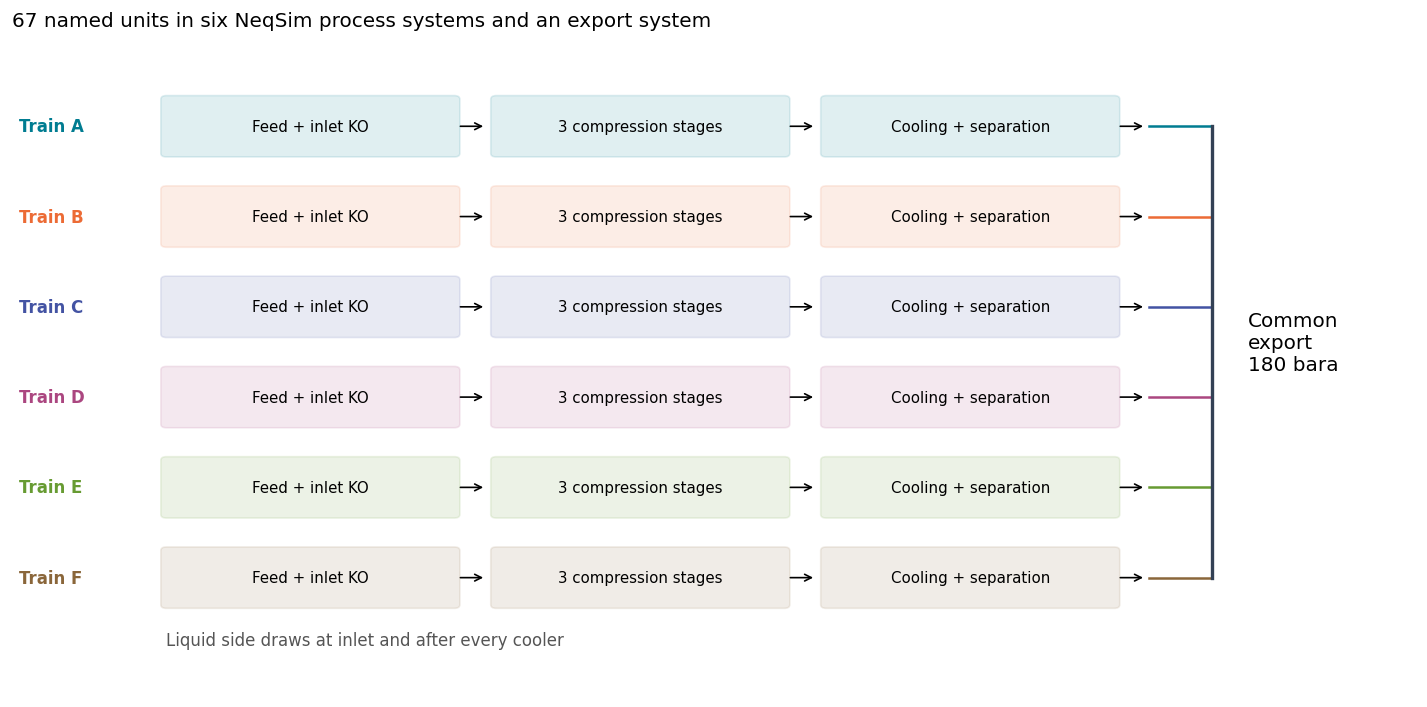

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.set(xlim=(0, 10), ylim=(-0.8, 6.5))
ax.axis("off")
labels = ["Feed + inlet KO", "3 compression stages", "Cooling + separation", "Export header"]
for train_index, name in enumerate(TRAIN_NAMES):
    y = 5.5 - train_index
    ax.text(0.05, y, name, va="center", weight="bold", color=COLORS[train_index])
    for x, label in zip([1.1, 3.45, 5.8], labels[:3]):
        box = FancyBboxPatch(
            (x, y - 0.3),
            2.05,
            0.6,
            boxstyle="round,pad=0.04",
            facecolor=COLORS[train_index],
            alpha=0.12,
            edgecolor=COLORS[train_index],
        )
        ax.add_patch(box)
        ax.text(x + 1.025, y, label, ha="center", va="center", fontsize=9)
        ax.annotate("", (x + 2.28, y), (x + 2.07, y), arrowprops={"arrowstyle": "->"})
    ax.plot([8.1, 8.55], [y, y], color=COLORS[train_index])
ax.plot([8.55, 8.55], [0.5, 5.5], color="#334155", lw=2)
ax.text(8.8, 3.1, "Common\nexport\n180 bara", va="center", fontsize=12)
ax.text(1.1, -0.25, "Liquid side draws at inlet and after every cooler", color="#555555")
ax.set_title(
    f"{unit_count} named units in six NeqSim process systems and an export system", loc="left"
)
finish(fig, "01_facility")

### Balance audit before analytics

For a steady open system, with heat into the fluid positive and compressor work positive:

$$\dot m_{in}-\sum_j\dot m_{out,j}=0$$
$$\dot H_{in}+\dot W+\dot Q-\sum_j\dot H_{out,j}=0$$

Mass flow is in kg/s; enthalpy rates, work and heat are in kW. Cooler duties from NeqSim are negative. The audit includes every liquid side draw. A component-molar balance provides a separate check against accidentally losing a light or heavy component.

,Check,Passed,Evidence
4,Train total mass balances,True,1.9617918400882672e-11
5,Train enthalpy balances,True,2.4556356947869062e-11
6,Component molar balances,True,9.948747990190384e-13
7,Header mass balance,True,-2.842170943040401e-14
8,Header energy balance,True,0.0
9,Physical power and cooling signs,True,All compressor powers and cooling requirements positive


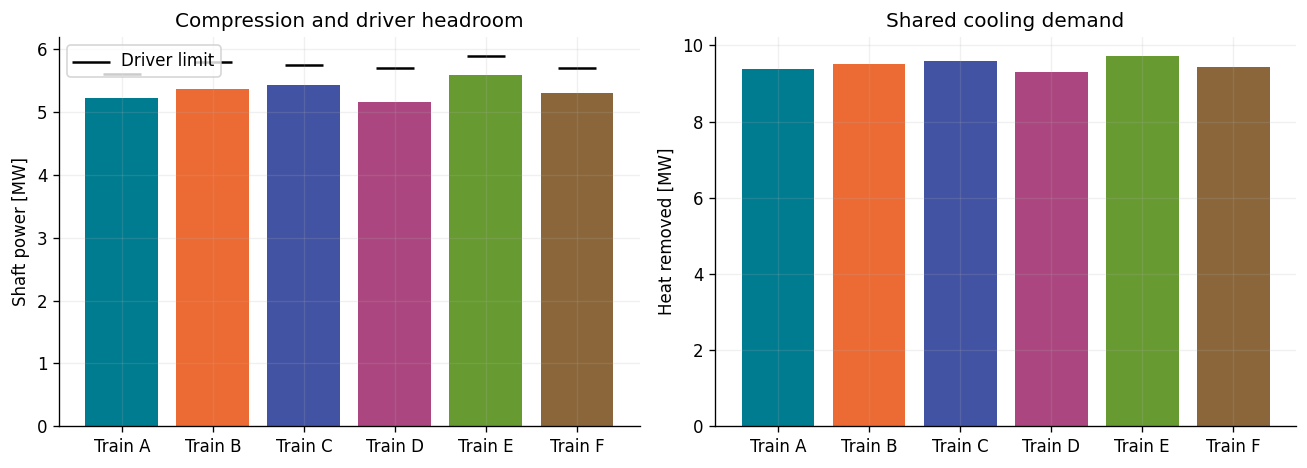

In [6]:
check(
    "Train total mass balances",
    baseline["Mass error [kg/s]"].abs().max() < 1e-7,
    baseline["Mass error [kg/s]"].abs().max(),
)
check(
    "Train enthalpy balances",
    baseline["Energy error [kW]"].abs().max() < 0.2,
    baseline["Energy error [kW]"].abs().max(),
)
component_errors = []
for train in trains:
    incoming = train["feed"].getFluid()
    products = [train["gas"], *train["liquids"]]
    for component in composition:
        feed_moles = incoming.getComponent(component).getNumberOfmoles()
        outlet_moles = sum(
            s.getFluid().getComponent(component).getNumberOfmoles() for s in products
        )
        component_errors.append(abs(feed_moles - outlet_moles) / max(abs(feed_moles), 1e-12))
check("Component molar balances", max(component_errors) < 1e-7, max(component_errors))
header_mass_error = (
    export_header.getOutletStream().getFlowRate("kg/sec") - baseline["Export [kg/s]"].sum()
)
header_energy_error = enthalpy_kw(export_header.getOutletStream()) - sum(
    enthalpy_kw(t["gas"]) for t in trains
)
check("Header mass balance", abs(header_mass_error) < 1e-7, header_mass_error)
check("Header energy balance", abs(header_energy_error) < 0.2, header_energy_error)
check(
    "Physical power and cooling signs",
    bool((baseline[["Power [MW]", "Cooling [MW]"]] > 0).all().all()),
    "All compressor powers and cooling requirements positive",
)
display(pd.DataFrame(checks).tail(6))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(TRAIN_NAMES, baseline["Power [MW]"], color=COLORS)
axes[0].scatter(TRAIN_NAMES, DRIVER_MW, marker="_", s=500, color="black", label="Driver limit")
axes[0].set(ylabel="Shaft power [MW]", title="Compression and driver headroom")
axes[0].legend()
axes[1].bar(TRAIN_NAMES, baseline["Cooling [MW]"], color=COLORS)
axes[1].set(ylabel="Heat removed [MW]", title="Shared cooling demand")
finish(fig, "02_energy")

## 3. Steady-state analytics: allocate load with constraints

We sample each train at 13–27 kg/s using NeqSim, fit shape-preserving interpolation curves and minimize total shaft power at a fixed facility feed. Driver power, per-train flow bounds and a shared cooling limit are enforced. A 5 kW reserve below each driver rating accommodates interpolation error; the final NeqSim replay must stay below the actual ratings. The trained response curves are only valid inside this sampled range and at the stated pressure, composition and cooler temperature.

$$\min_{\dot m_1,\ldots,\dot m_6}\sum_i W_i(\dot m_i)$$
$$\sum_i\dot m_i=120\ \mathrm{kg/s},\quad W_i\leq W_{i,max},\quad\sum_i Q_i\leq Q_{max}$$

Here $W_i$ is shaft power in MW and $Q_i$ is the positive cooling requirement in MW. The optimization holds **feed** constant; it does not claim an export-gas optimum. After optimization, we rebuild the six full NeqSim trains at the candidate settings and check feasibility and balances again.

54 full train simulations in 4.57 s


Power [MW]        Cooling [MW]        
               min    max          min     max
Train                                         
Train A      3.442  7.149        6.137  12.745
Train B      3.534  7.339        6.228  12.936
Train C      3.581  7.438        6.276  13.035
Train D      3.398  7.057        6.092  12.653
Train E      3.681  7.645        6.375  13.241
Train F      3.487  7.243        6.182  12.839

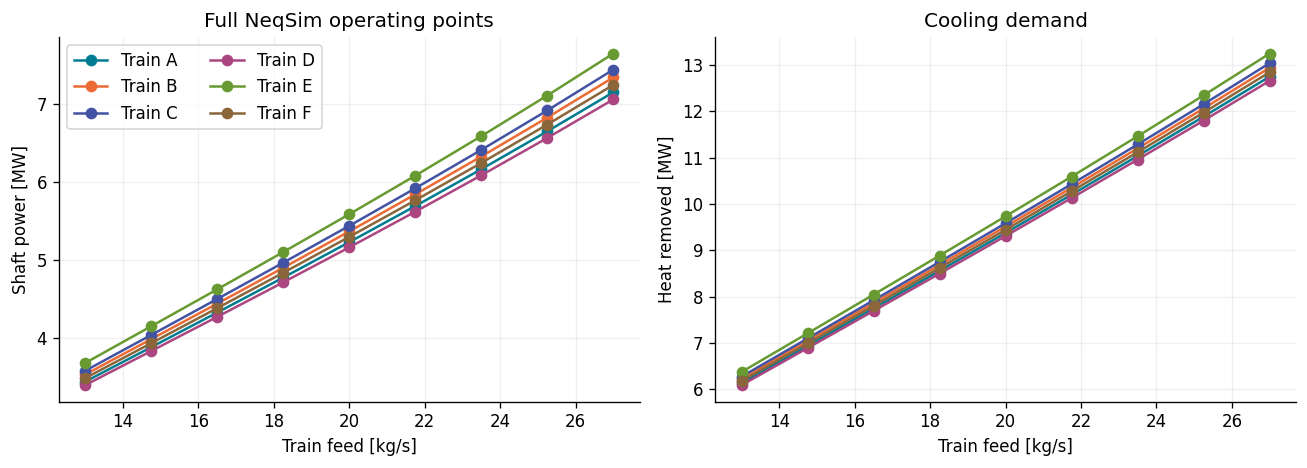

In [7]:
flow_grid = np.linspace(13, 27, 9)
scan_rows = []
scan_start = time.perf_counter()
for train_index, (name, efficiency) in enumerate(zip(TRAIN_NAMES, ETA_NOMINAL)):
    for flow in flow_grid:
        trial = build_train(name, float(flow), float(efficiency))
        trial["process"].run()
        result = train_results(trial)
        result["train_index"] = train_index
        scan_rows.append(result)
scan = pd.DataFrame(scan_rows)
scan_seconds = time.perf_counter() - scan_start
power_curves, cooling_curves = [], []
for train_index in range(6):
    subset = scan[scan.train_index == train_index]
    power_curves.append(
        PchipInterpolator(subset["Feed [kg/s]"], subset["Power [MW]"], extrapolate=False)
    )
    cooling_curves.append(
        PchipInterpolator(subset["Feed [kg/s]"], subset["Cooling [MW]"], extrapolate=False)
    )
check(
    "Scan balance closure",
    scan["Energy error [kW]"].abs().max() < 0.2,
    scan["Energy error [kW]"].abs().max(),
)
print(f"{len(scan)} full train simulations in {scan_seconds:.2f} s")
display(scan.groupby("Train")[["Power [MW]", "Cooling [MW]"]].agg(["min", "max"]).round(3))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for index, name in enumerate(TRAIN_NAMES):
    subset = scan[scan.train_index == index]
    axes[0].plot(flow_grid, subset["Power [MW]"], "o-", color=COLORS[index], label=name)
    axes[1].plot(flow_grid, subset["Cooling [MW]"], "o-", color=COLORS[index], label=name)
axes[0].set(
    xlabel="Train feed [kg/s]", ylabel="Shaft power [MW]", title="Full NeqSim operating points"
)
axes[1].set(xlabel="Train feed [kg/s]", ylabel="Heat removed [MW]", title="Cooling demand")
axes[0].legend(ncol=2)
finish(fig, "03_operating_envelopes")

Synthetic-case shaft-power reduction at fixed feed: 0.051 MW
This is a local candidate under the assumed efficiency curves, not a proven global optimum.


,Base feed [kg/s],Candidate feed [kg/s],Replay power [MW],Driver margin [MW]
Train,,,,
Train A,20.0,21.390,5.595,0.005
Train B,20.0,20.529,5.509,0.291
Train C,20.0,19.278,5.242,0.508
Train D,20.0,22.039,5.695,0.005
Train E,20.0,15.272,4.292,1.608
Train F,20.0,21.492,5.695,0.005


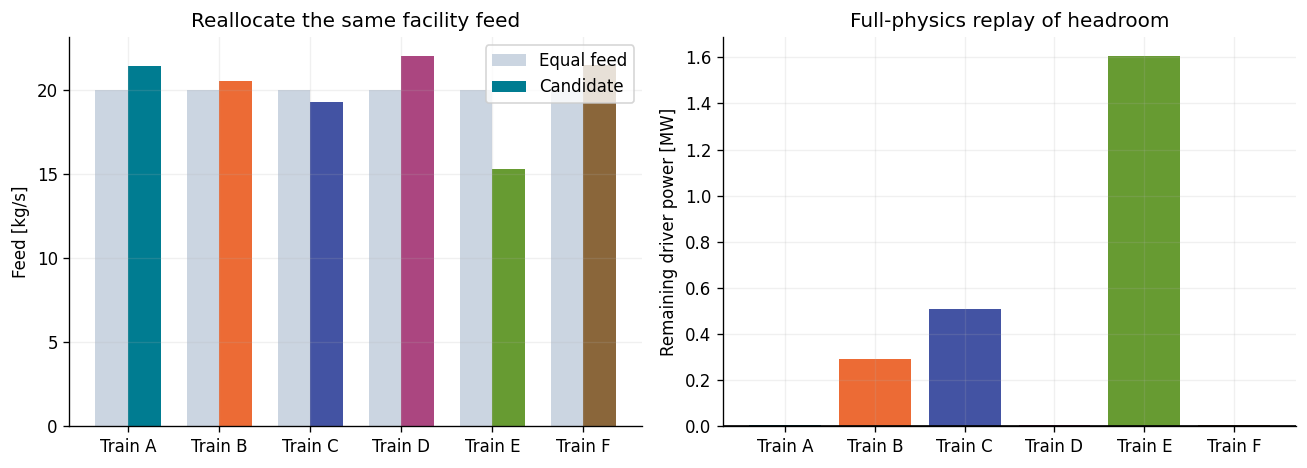

In [8]:
def response(curves, rates):
    return np.array([float(curve(rate)) for curve, rate in zip(curves, rates)])


cooling_limit = float(baseline["Cooling [MW]"].sum() * 1.02)
constraints = [
    {"type": "eq", "fun": lambda rates: rates.sum() - 120.0},
    {"type": "ineq", "fun": lambda rates: DRIVER_MW - 0.005 - response(power_curves, rates)},
    {"type": "ineq", "fun": lambda rates: cooling_limit - response(cooling_curves, rates).sum()},
]
opt = minimize(
    lambda rates: response(power_curves, rates).sum(),
    np.full(6, 20.0),
    method="SLSQP",
    bounds=[(13.0, 27.0)] * 6,
    constraints=constraints,
    options={"ftol": 1e-10, "maxiter": 150},
)
check("Load allocation solver", opt.success, opt.message)
replay_trains = [
    build_train(name, float(flow), float(efficiency))
    for name, flow, efficiency in zip(TRAIN_NAMES, opt.x, ETA_NOMINAL)
]
for train in replay_trains:
    train["process"].run()
replay = pd.DataFrame([train_results(train) for train in replay_trains]).set_index("Train")
check(
    "Replay fixed total feed",
    abs(replay["Feed [kg/s]"].sum() - 120) < 1e-6,
    replay["Feed [kg/s]"].sum(),
)
check(
    "Replay driver constraints",
    np.all(replay["Power [MW]"].values <= DRIVER_MW),
    float(np.max(replay["Power [MW]"].values - DRIVER_MW)),
)
check(
    "Replay cooling constraint",
    replay["Cooling [MW]"].sum() <= cooling_limit + 0.005,
    replay["Cooling [MW]"].sum(),
)
check(
    "Replay energy balances",
    replay["Energy error [kW]"].abs().max() < 0.2,
    replay["Energy error [kW]"].abs().max(),
)
interpolation_error = replay["Power [MW]"].values - response(power_curves, opt.x)
check(
    "Response curve accuracy at candidate",
    np.max(abs(interpolation_error)) < 0.005,
    np.max(abs(interpolation_error)),
)
saving_mw = baseline["Power [MW]"].sum() - replay["Power [MW]"].sum()
allocation = pd.DataFrame(
    {
        "Base feed [kg/s]": baseline["Feed [kg/s]"],
        "Candidate feed [kg/s]": opt.x,
        "Replay power [MW]": replay["Power [MW]"],
        "Driver margin [MW]": DRIVER_MW - replay["Power [MW]"],
    }
)
display(allocation.round(3))
print(f"Synthetic-case shaft-power reduction at fixed feed: {saving_mw:.3f} MW")
print(
    "This is a local candidate under the assumed efficiency curves, not a proven global optimum."
)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
x = np.arange(6)
axes[0].bar(x - 0.18, np.full(6, 20), 0.36, label="Equal feed", color="#CBD5E1")
axes[0].bar(x + 0.18, opt.x, 0.36, label="Candidate", color=COLORS)
axes[0].set(
    xticks=x,
    xticklabels=TRAIN_NAMES,
    ylabel="Feed [kg/s]",
    title="Reallocate the same facility feed",
)
axes[0].legend()
axes[1].bar(TRAIN_NAMES, DRIVER_MW - replay["Power [MW]"], color=COLORS)
axes[1].axhline(0, color="black", lw=1)
axes[1].set(ylabel="Remaining driver power [MW]", title="Full-physics replay of headroom")
finish(fig, "04_load_allocation")

## 4. A physical dynamic experiment

A thermodynamic operating point does not contain a time constant. We add an explicit effective thermal capacitance for the first aftercooler of Train A. NeqSim supplies the inlet temperature, gas flow and heat capacity; the effective conductance is chosen so its steady outlet is 32 °C at an 18 °C cooling-water temperature.

$$C\frac{dT}{dt}=\dot m c_p(T_{in}-T)-UA(T-T_{cw})$$
$$T_{ss}=\frac{\dot m c_pT_{in}+UA T_{cw}}{\dot m c_p+UA},\qquad\tau=\frac{C}{\dot m c_p+UA}$$

$T$, $T_{in}$ and $T_{cw}$ are temperatures in °C, with differences in K. The effective capacitance $C$ is in kJ/K, $c_p$ in kJ/(kg K), $UA$ in kW/K and time $t$ in seconds. We set $C$ to give a nominal 45 s time constant. This is a stated synthetic equipment assumption, not a value inferred from NeqSim steady-state calculations.

The experiment varies inlet temperature and cooling-water temperature independently. Flow and heat capacity are fixed at the reference value. This lumped approximation is used to validate the integration and identification workflow; the phase-changing NeqSim cooler remains the steady reference, not the dynamic truth model. Real-data work needs independently excited inputs and a physically appropriate storage model.

The update below solves the linear energy equation exactly for each piecewise-constant input interval. That lets us check integrated energy storage independently of the TimeSeriesAnalysis discretization.

,Reference model
Hot inlet [°C],110.1383
Gas flow [kg/s],20.0000
NeqSim cp [kJ/(kg K)],2.5987
UA [kW/K],290.0799
Effective C [kJ/K],15392.4022
Physical tau [s],45.0000


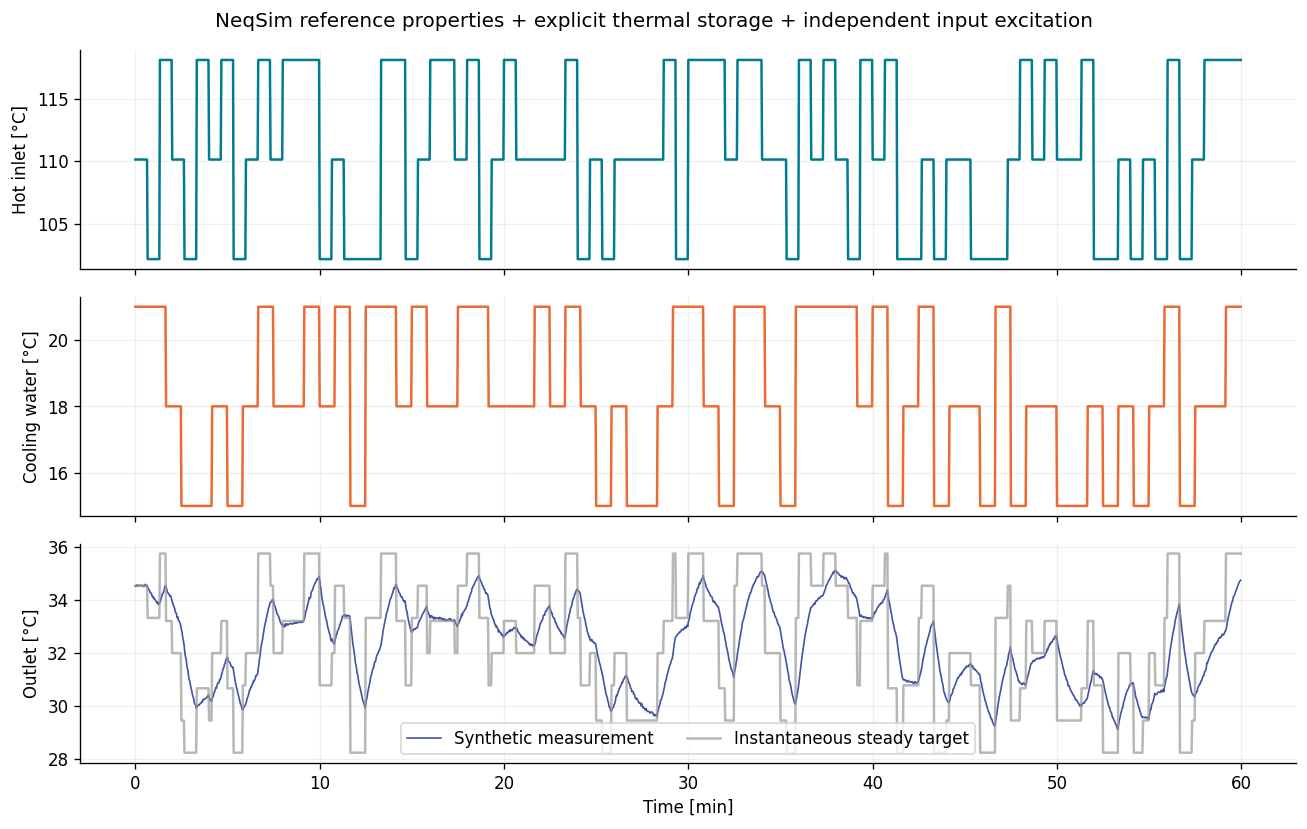

In [9]:
reference_hot_stream = trains[0]["compressors"][0].getOutletStream()
hot_temperature = reference_hot_stream.getTemperature("C")
gas_flow = reference_hot_stream.getFlowRate("kg/sec")
cp = reference_hot_stream.getFluid().getCp("kJ/kgK")
heat_capacity_rate = gas_flow * cp
coolant_reference = 18.0
outlet_reference = 32.0
conductance = (
    heat_capacity_rate
    * (hot_temperature - outlet_reference)
    / (outlet_reference - coolant_reference)
)
tau_true = 45.0
capacitance = tau_true * (heat_capacity_rate + conductance)
gains_true = np.array([heat_capacity_rate, conductance]) / (heat_capacity_rate + conductance)
dt = 2.0
sample_count = 1800
seconds = np.arange(sample_count) * dt
rng = np.random.default_rng(20260914)
inputs = np.column_stack(
    [
        hot_temperature + np.repeat(rng.choice([-8.0, 0.0, 8.0], 90), 20),
        coolant_reference + np.repeat(rng.choice([-3.0, 0.0, 3.0], 72), 25),
    ]
)
steady_temperature = inputs @ gains_true
temperature = np.empty(sample_count)
temperature[0] = steady_temperature[0]
decay = np.exp(-dt / tau_true)
energy_errors = []
for index in range(1, sample_count):
    target = steady_temperature[index]
    previous = temperature[index - 1]
    temperature[index] = target + (previous - target) * decay
    mean_temperature = target + (previous - target) * tau_true / dt * (1 - decay)
    net_heat = heat_capacity_rate * (inputs[index, 0] - mean_temperature)
    net_heat -= conductance * (mean_temperature - inputs[index, 1])
    stored_energy = capacitance * (temperature[index] - previous)
    energy_errors.append(stored_energy - dt * net_heat)
measurement = temperature + rng.normal(0, 0.025, sample_count)
check(
    "Integrated dynamic energy balance",
    max(abs(np.array(energy_errors))) < 1e-7,
    f"Maximum interval residual {max(abs(np.array(energy_errors))):.3g} kJ",
)
display(
    pd.Series(
        {
            "Hot inlet [°C]": hot_temperature,
            "Gas flow [kg/s]": gas_flow,
            "NeqSim cp [kJ/(kg K)]": cp,
            "UA [kW/K]": conductance,
            "Effective C [kJ/K]": capacitance,
            "Physical tau [s]": tau_true,
        }
    )
    .round(4)
    .to_frame("Reference model")
)
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
axes[0].plot(seconds / 60, inputs[:, 0], color=COLORS[0])
axes[0].set(ylabel="Hot inlet [°C]")
axes[1].plot(seconds / 60, inputs[:, 1], color=COLORS[1])
axes[1].set(ylabel="Cooling water [°C]")
axes[2].plot(seconds / 60, measurement, color=COLORS[2], lw=1, label="Synthetic measurement")
axes[2].plot(
    seconds / 60,
    steady_temperature,
    color="#999999",
    alpha=0.7,
    label="Instantaneous steady target",
)
axes[2].set(xlabel="Time [min]", ylabel="Outlet [°C]")
axes[2].legend(ncol=2)
fig.suptitle(
    "NeqSim reference properties + explicit thermal storage + independent input excitation"
)
finish(fig, "05_dynamic_experiment")

### Historian quality and leakage rules

Preserve time order, units and quality flags. Do not bridge long gaps, treat frozen tags as measured dynamics, or randomly shuffle a dynamic experiment into training and test rows. Here we inject a short dropout and a frozen sensor period into a separate raw view, flag them, and show their positions. For fitting, a complete contiguous qualified interval is selected from the original synthetic experiment; the damaged copy is not silently interpolated into the training data.

Training uses the first 60% of the experiment, calibration the next 20%, and final testing the last 20%. Model coefficients are learned on training only. Calibration selects a residual threshold; test data assess its behavior. Final validation simulation is a continuous forward pass using inputs only. It never resets the model with future measured outputs.

,Flagged samples
missing,10
frozen,26


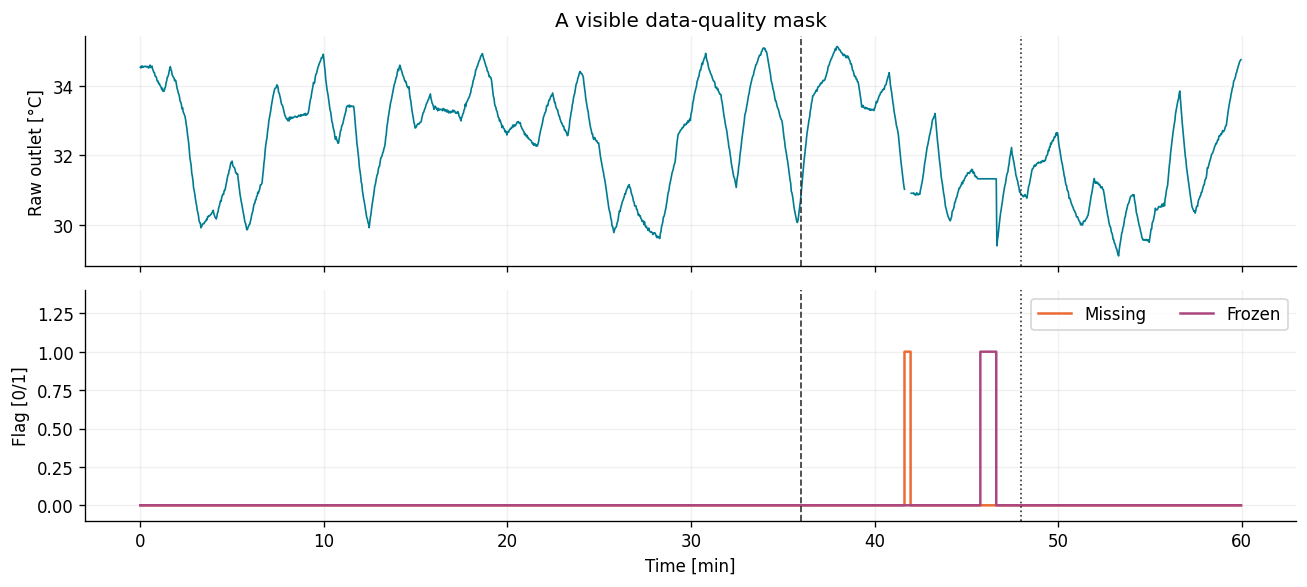

In [10]:
timestamps = pd.date_range("2026-01-01", periods=sample_count, freq="2s", tz="UTC")
historian = pd.DataFrame(
    {
        "hot_inlet_C": inputs[:, 0],
        "cooling_water_C": inputs[:, 1],
        "outlet_C": measurement,
    },
    index=timestamps,
)
raw_historian = historian.copy()
raw_historian.iloc[1250:1260, 2] = np.nan
raw_historian.iloc[1370:1400, 2] = raw_historian.iloc[1369, 2]
missing_flag = raw_historian.isna().any(axis=1)
frozen_flag = raw_historian.outlet_C.diff().abs().lt(1e-10).rolling(5).sum().ge(5)
quality = pd.DataFrame({"missing": missing_flag, "frozen": frozen_flag})
train_end, calibration_end = 1080, 1440
check(
    "Qualified contiguous training segment",
    not quality.iloc[:train_end].any().any(),
    f"Samples 0–{train_end - 1} have no injected quality failures",
)
display(quality.sum().rename("Flagged samples").to_frame())
fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
axes[0].plot(seconds / 60, raw_historian.outlet_C, color=COLORS[0], lw=1)
axes[0].set(ylabel="Raw outlet [°C]", title="A visible data-quality mask")
axes[1].step(seconds / 60, missing_flag.astype(int), label="Missing", color=COLORS[1])
axes[1].step(seconds / 60, frozen_flag.astype(int), label="Frozen", color=COLORS[3])
axes[1].set(xlabel="Time [min]", ylabel="Flag [0/1]", ylim=(-0.1, 1.4))
axes[1].legend(ncol=2)
for ax in axes:
    ax.axvline(seconds[train_end] / 60, color="#333333", ls="--", lw=1)
    ax.axvline(seconds[calibration_end] / 60, color="#333333", ls=":", lw=1)
finish(fig, "06_historian_quality")

## 5. Identify the dynamics with TimeSeriesAnalysis

The current API uses `UnitDataSet.SetU`, `CreateTimeStamps` and the static `UnitIdentifier.IdentifyLinear` method. Python.NET returns the model and updated `ref` dataset as a tuple. The fitted model is then simulated with `UnitModel.Iterate`.

We constrain this example to linear gains and disable transport-delay estimation because the known energy equation has no dead time. A measured plant may require a justified delay search, input nonlinearities or closed-loop identification. Residual performance alone is not evidence that all physical parameters are uniquely identifiable.

TimeSeriesAnalysis's first-order filter uses a backward-Euler coefficient, while the synthetic plant uses the exact exponential solution. Consequently, the fitted discrete-equivalent time constant differs slightly from the continuous 45 s value. We report both instead of treating that numerical difference as physical model error.

Both the dynamic fit and static reference now use native TSA identification (`IdentifyLinear` and `IdentifyLinearAndStatic`), so their held-out comparison uses the same library and training boundary.


In [11]:
training = UnitDataSet("Aftercooler training")
training.SetU(netarray(inputs[:train_end, 0]), netarray(inputs[:train_end, 1]))
training.Y_meas = netarray(measurement[:train_end])
training.CreateTimeStamps(dt)
fit_start = time.perf_counter()
identified, fitted_data = UnitIdentifier.IdentifyLinear(training, None, False)
fit_seconds = time.perf_counter() - fit_start
fit_parameters = identified.GetModelParameters()
check(
    "TSA identification succeeded",
    fit_parameters.Fitting.WasAbleToIdentify,
    str(fit_parameters.Fitting.SolverID),
)
identified.WarmStart()
predicted = np.array([identified.Iterate(netarray(row), dt)[0] for row in inputs])
static_identified, _ = UnitIdentifier.IdentifyLinearAndStatic(training, None, False)
check(
    "TSA static identification succeeded",
    static_identified.GetModelParameters().Fitting.WasAbleToIdentify,
    "Static and dynamic models now both use the native TSA identifier",
)
static_prediction = np.array(
    [static_identified.GetSteadyStateOutput(netarray(row)) for row in inputs]
)
tau_discrete_equivalent = dt / (np.exp(dt / tau_true) - 1)
fit_gains = np.array(list(fit_parameters.LinearGains))
parameter_table = pd.DataFrame(
    {
        "Physical model": [*gains_true, tau_true],
        "Expected discrete equivalent": [*gains_true, tau_discrete_equivalent],
        "Identified": [*fit_gains, fit_parameters.TimeConstant_s],
    },
    index=["Hot-inlet gain [K/K]", "Cooling-water gain [K/K]", "Time constant [s]"],
)
display(parameter_table.round(4))
warnings = [str(value) for value in fit_parameters.GetWarningList()]
print("Identification warnings:", warnings or "none")
print(f"Fit runtime: {fit_seconds:.3f} s; fitted time delay: {fit_parameters.TimeDelay_s:.1f} s")
check("Recovered process gains", np.max(abs(fit_gains - gains_true)) < 0.04, fit_gains)
check(
    "Recovered discrete time constant",
    abs(fit_parameters.TimeConstant_s - tau_discrete_equivalent) < 7,
    fit_parameters.TimeConstant_s,
)

Identification warnings: none
Fit runtime: 0.277 s; fitted time delay: 0.0 s


,Physical model,Expected discrete equivalent,Identified
Hot-inlet gain [K/K],0.1519,0.1519,0.1512
Cooling-water gain [K/K],0.8481,0.8481,0.8440
Time constant [s],45.0000,44.0074,43.6430


Calibration residual threshold: 0.060 K
Test threshold-exceedance fraction: 3.06%
The empirical calibration quantile does not guarantee the same exceedance rate on new data.


,TSA dynamic RMSE [K],Static regression RMSE [K]
Partition,,
Training,0.0254,1.0916
Calibration,0.0234,1.2559
Held-out test,0.0264,1.2810


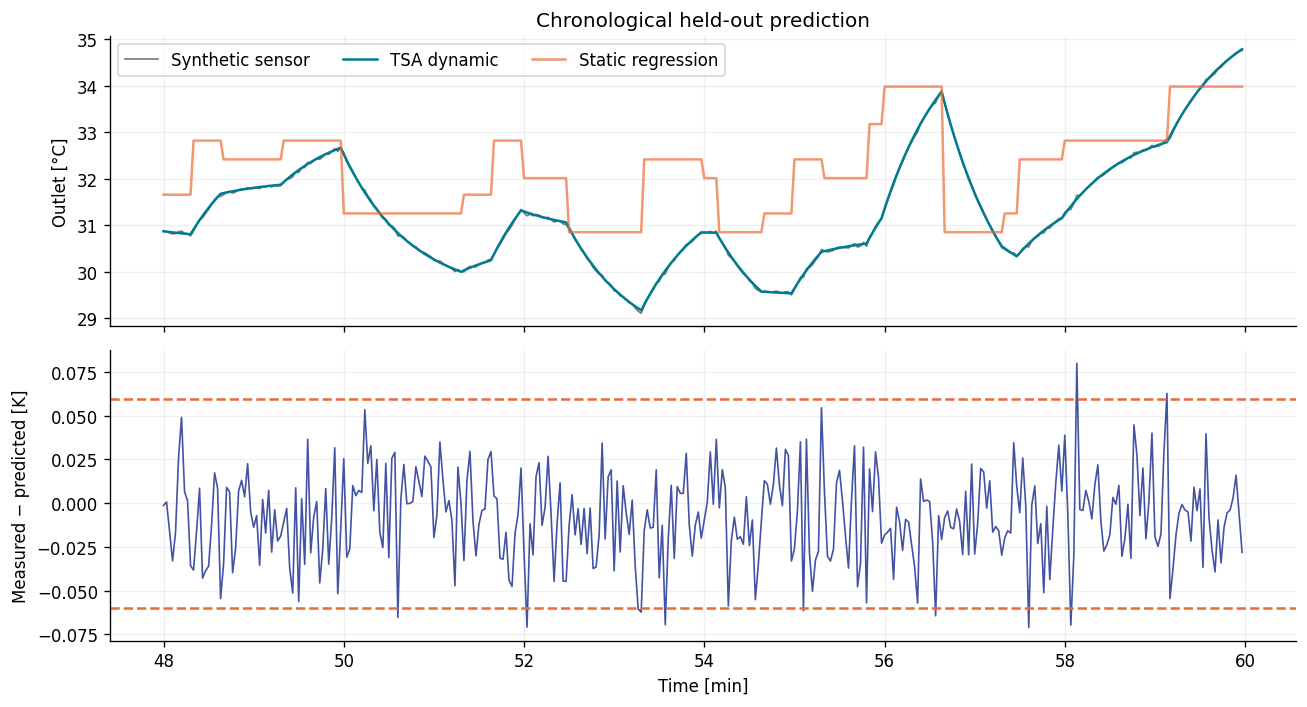

In [12]:
def rmse(observed, estimated):
    return float(np.sqrt(np.mean((np.asarray(observed) - np.asarray(estimated)) ** 2)))


partitions = {
    "Training": slice(100, train_end),
    "Calibration": slice(train_end, calibration_end),
    "Held-out test": slice(calibration_end, sample_count),
}
scores = pd.DataFrame(
    [
        {
            "Partition": name,
            "TSA dynamic RMSE [K]": rmse(measurement[part], predicted[part]),
            "Static regression RMSE [K]": rmse(measurement[part], static_prediction[part]),
        }
        for name, part in partitions.items()
    ]
).set_index("Partition")
residuals = measurement - predicted
calibration_threshold = float(np.quantile(abs(residuals[train_end:calibration_end]), 0.995))
test_alarm_rate = float(np.mean(abs(residuals[calibration_end:]) > calibration_threshold))
check(
    "Dynamic prediction improves held-out RMSE",
    scores.loc["Held-out test", "TSA dynamic RMSE [K]"]
    < 0.25 * scores.loc["Held-out test", "Static regression RMSE [K]"],
    scores.loc["Held-out test"].to_dict(),
)
display(scores.round(4))
print(f"Calibration residual threshold: {calibration_threshold:.3f} K")
print(f"Test threshold-exceedance fraction: {100 * test_alarm_rate:.2f}%")
print(
    "The empirical calibration quantile does not guarantee the same exceedance rate on new data."
)
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
test_time = seconds[calibration_end:] / 60
axes[0].plot(
    test_time, measurement[calibration_end:], color="#777777", label="Synthetic sensor", lw=1
)
axes[0].plot(test_time, predicted[calibration_end:], color=COLORS[0], label="TSA dynamic")
axes[0].plot(
    test_time,
    static_prediction[calibration_end:],
    color=COLORS[1],
    label="Static regression",
    alpha=0.7,
)
axes[0].set(ylabel="Outlet [°C]", title="Chronological held-out prediction")
axes[0].legend(ncol=3)
axes[1].plot(test_time, residuals[calibration_end:], color=COLORS[2], lw=1)
axes[1].axhline(calibration_threshold, color=COLORS[1], ls="--")
axes[1].axhline(-calibration_threshold, color=COLORS[1], ls="--")
axes[1].set(xlabel="Time [min]", ylabel="Measured − predicted [K]")
finish(fig, "07_identification")

### Independent time-step check

We now prescribe the physical 45 s time constant directly in TimeSeriesAnalysis and compare its step response with the analytical exponential solution. Halving the step should reduce the backward-Euler error. This check concerns numerical integration; the held-out experiment above concerns identified predictive performance.

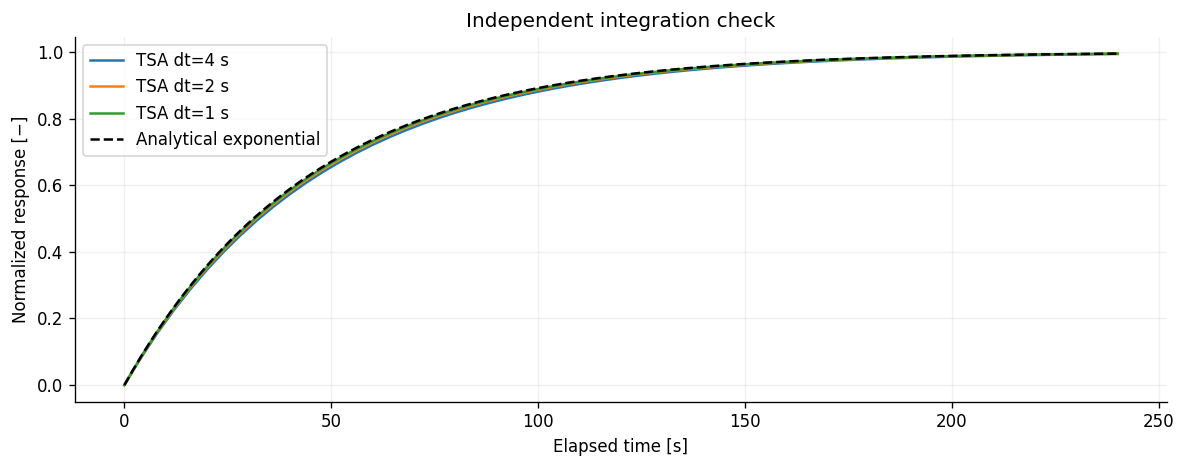

,dt [s],Max normalized error
0,4.0,0.015759
1,2.0,0.008027
2,1.0,0.004050


In [13]:
step_rows = []
fig, ax = plt.subplots(figsize=(10, 4))
for step in [4.0, 2.0, 1.0]:
    step_times = np.arange(0, 240 + step, step)
    model = unit_model(f"Step {step}", [1.0], tau=tau_true)
    values = []
    for index, instant in enumerate(step_times):
        values.append(model.Iterate(netarray([0.0 if index == 0 else 1.0]), step)[0])
    exact = 1 - np.exp(-step_times / tau_true)
    error = np.max(abs(np.array(values) - exact))
    step_rows.append({"dt [s]": step, "Max normalized error": error})
    ax.plot(step_times, values, label=f"TSA dt={step:g} s")
ax.plot(step_times, exact, "k--", label="Analytical exponential")
ax.set(
    xlabel="Elapsed time [s]",
    ylabel="Normalized response [−]",
    title="Independent integration check",
)
ax.legend()
finish(fig, "08_timestep")
display(pd.DataFrame(step_rows))
check(
    "Time-step refinement reduces error",
    step_rows[2]["Max normalized error"]
    < step_rows[1]["Max normalized error"]
    < step_rows[0]["Max normalized error"],
    step_rows,
)

## 6. Connect the reduced models into a plant

**PlantSimulator** executes a network of connected unit models. We instantiate six copies of the identified cooler, prescribe different effective time constants for their different assumed inventories, and connect them to a common export-temperature signal. Each train has two external temperature inputs. A cooling-water disturbance reaches all trains; individual hot-inlet changes occur at different times.

The header model uses fixed gas-mass weights and a 12 s sensor lag. A mass-weighted temperature is an approximation valid for similar compositions and heat capacities. The exact NeqSim header uses enthalpy mixing. No pressure coupling or shared cooling-water feedback is implied by this feed-forward network.

Connected network runtime: 0.013 s


,Train,Header weight [−],Initial outlet [°C],Final outlet [°C]
0,Train A,0.1667,32.0035,35.4429
1,Train B,0.1667,32.0035,35.4429
2,Train C,0.1667,32.0035,35.4429
3,Train D,0.1667,32.0035,35.4429
4,Train E,0.1667,32.0035,35.4429
5,Train F,0.1667,32.0035,35.4429


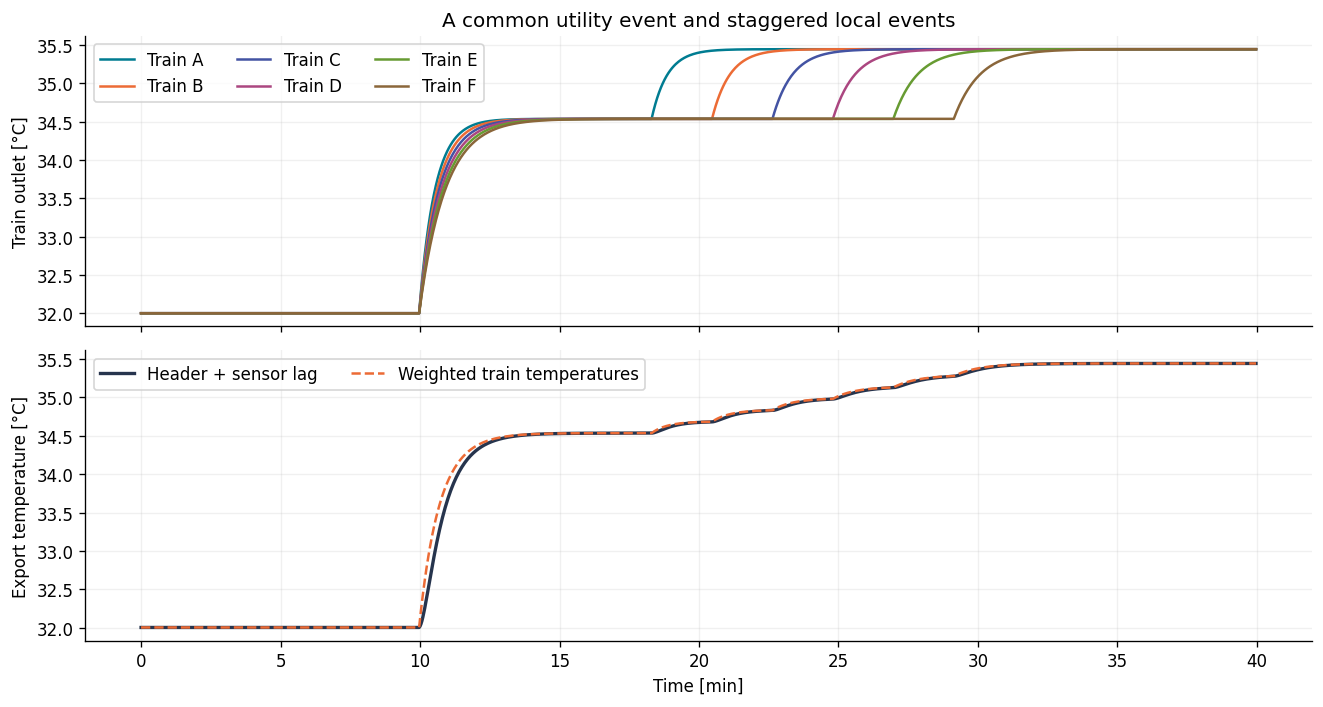

In [14]:
network_models = List[ISimulatableModel]()
cooler_models = []
for index, name in enumerate(TRAIN_NAMES):
    parameters = fit_parameters.CreateCopy()
    parameters.TimeConstant_s *= 0.75 + 0.1 * index
    model = UnitModel(parameters, f"cooler_{index}")
    cooler_models.append(model)
    network_models.Add(model)
weights = baseline["Export [kg/s]"].values / baseline["Export [kg/s]"].sum()
header_model = unit_model("export_temperature", weights, tau=12.0)
network_models.Add(header_model)
network = PlantSimulator(network_models, "Six-train thermal twin", "Synthetic identified network")
network_data = TimeSeriesDataSet()
network_count = 1200
network_seconds = np.arange(network_count) * dt
network_coolant = np.full(network_count, coolant_reference)
network_coolant[300:] += 3.0
for index, model in enumerate(cooler_models):
    network.ConnectModels(model, header_model, index)
    hot_input = np.full(network_count, hot_temperature)
    hot_input[550 + 65 * index :] += 6.0
    hot_signal = network.AddExternalSignal(model, SignalType.External_U, 0)
    coolant_signal = network.AddExternalSignal(model, SignalType.External_U, 1)
    network_data.Add(hot_signal, netarray(hot_input))
    network_data.Add(coolant_signal, netarray(network_coolant))
network_data.CreateTimestamps(dt, network_count)
network_start = time.perf_counter()
network_ok, network_output = network.Simulate(network_data)
network_seconds_elapsed = time.perf_counter() - network_start
check("Connected TSA plant simulation", network_ok, f"7 models × {network_count} time steps")
network_temperatures = np.column_stack(
    [list(network_output.GetValues(model.GetOutputID())) for model in cooler_models]
)
header_temperature = np.array(list(network_output.GetValues(header_model.GetOutputID())))
check(
    "Finite network outputs",
    np.isfinite(network_temperatures).all() and np.isfinite(header_temperature).all(),
    f"{network_temperatures.size + header_temperature.size} output samples",
)
display(
    pd.DataFrame(
        {
            "Train": TRAIN_NAMES,
            "Header weight [−]": weights,
            "Initial outlet [°C]": network_temperatures[0],
            "Final outlet [°C]": network_temperatures[-1],
        }
    ).round(4)
)
print(f"Connected network runtime: {network_seconds_elapsed:.3f} s")
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for index, name in enumerate(TRAIN_NAMES):
    axes[0].plot(
        network_seconds / 60, network_temperatures[:, index], color=COLORS[index], label=name
    )
axes[0].set(ylabel="Train outlet [°C]", title="A common utility event and staggered local events")
axes[0].legend(ncol=3)
axes[1].plot(
    network_seconds / 60, header_temperature, color="#26344D", lw=2, label="Header + sensor lag"
)
axes[1].plot(
    network_seconds / 60,
    network_temperatures @ weights,
    color=COLORS[1],
    ls="--",
    label="Weighted train temperatures",
)
axes[1].set(xlabel="Time [min]", ylabel="Export temperature [°C]")
axes[1].legend(ncol=2)
finish(fig, "09_connected_network")

### 6.1. Run the same topology at steady state

For this feed-forward graph, zeroing time constants and delays gives the algebraic
steady target at every input sample. We build fresh model objects and run that graph through
PlantSimulator too, then check the header against direct steady-output calculations.
The dynamic graph approaches these targets with storage and sensor lag. This is steady
replay of the reduced model, with its fixed mass weights; NeqSim supplies the thermodynamic
steady plant in Sections 2–3. Setting time constants to zero is not a general method for
finding the equilibrium of PID integrators or arbitrary recycle networks.

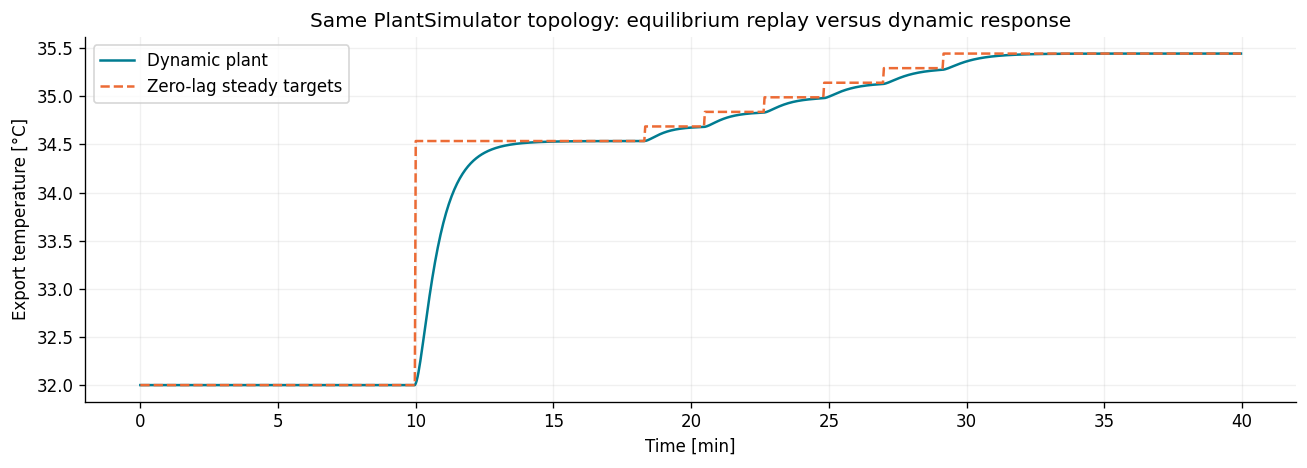

In [15]:
static_coolers = []
for index in range(6):
    params = fit_parameters.CreateCopy()
    params.TimeConstant_s = 0.0
    params.TimeDelay_s = 0.0
    static_coolers.append(UnitModel(params, f"cooler_{index}"))
static_header = unit_model("export_temperature", weights)
static_network = bridge.plant([*static_coolers, static_header], "Steady-state TSA replay")
static_signals = {}
for index, model in enumerate(static_coolers):
    assert static_network.ConnectModels(model, static_header, index)
    for input_index in [0, 1]:
        signal = static_network.AddExternalSignal(model, SignalType.External_U, input_index)
        static_signals[str(signal)] = list(network_data.GetValues(signal))
static_frame = pd.DataFrame(static_signals, index=network_seconds)
static_ids = [str(model.GetOutputID()) for model in [*static_coolers, static_header]]
static_outputs = bridge.simulate(static_network, static_frame, dt, static_ids)
static_reference = (
    np.column_stack(
        [
            [
                model.GetSteadyStateOutput(netarray(row))
                for row in static_frame.iloc[:, 2 * i : 2 * i + 2].to_numpy()
            ]
            for i, model in enumerate(static_coolers)
        ]
    )
    @ weights
)
check(
    "Steady-state PlantSimulator matches algebraic target",
    np.allclose(static_outputs.iloc[:, -1], static_reference, atol=1e-8),
    float(np.max(abs(static_outputs.iloc[:, -1] - static_reference))),
)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(network_seconds / 60, header_temperature, label="Dynamic plant", color=COLORS[0])
ax.plot(
    network_seconds / 60,
    static_reference,
    label="Zero-lag steady targets",
    color=COLORS[1],
    ls="--",
)
ax.set(
    xlabel="Time [min]",
    ylabel="Export temperature [°C]",
    title="Same PlantSimulator topology: equilibrium replay versus dynamic response",
)
ax.legend()
finish(fig, "09b_steady_dynamic_plant")

## 7. Diagnose compressor degradation with physical residuals

A higher power reading can reflect increased flow, pressure ratio, reduced efficiency or a faulty meter. First calculate the expected power and discharge temperature with NeqSim at each observed operating condition. Then monitor deviations from that moving physical baseline.

We generate 96 independent steady historian windows for Train A's **first compressor**, varying feed flow and suction pressure. Windows 0–63 are healthy, 64–83 have a five-percentage-point efficiency loss, and 84–95 return to healthy operation but have a positive power-meter offset. These labels generate and evaluate the synthetic case; the residual classifier does not receive them.

$$r_W=W_{measured}-W_{NeqSim},\qquad r_T=T_{measured}-T_{NeqSim}$$

Power residuals are in MW; temperature residuals are in K. Standardize each residual using the first 40 healthy windows, then use the native TSA `LowPass` causal filter with the same exponential weights. A sustained increase in both residuals suggests a physical efficiency change; an isolated power residual suggests a measurement or driver-model discrepancy. This is diagnostic evidence, not unique proof of the root cause. Composition errors, heat transfer, driver losses and sensor bias can confound this interpretation in a real plant.

Full NeqSim monitoring calculations: 4.41 s
Efficiency-change detection delay: 0 historian windows


,Window,Feed [kg/s],Suction [bara],Power measured [MW],Power expected [MW],Discharge measured [°C],Discharge expected [°C],Diagnosis
40,40,18.653,28.240,2.557,2.562,115.264,115.294,within baseline
63,63,21.030,31.699,2.434,2.439,105.444,105.478,within baseline
65,65,20.347,31.862,2.516,2.341,108.041,105.032,physical change candidate
75,75,17.598,31.721,2.165,2.041,108.540,105.474,physical change candidate
85,85,18.973,30.253,2.576,2.363,109.469,109.440,physical change candidate
95,95,22.110,28.590,3.199,2.988,114.333,114.282,power measurement/model candidate


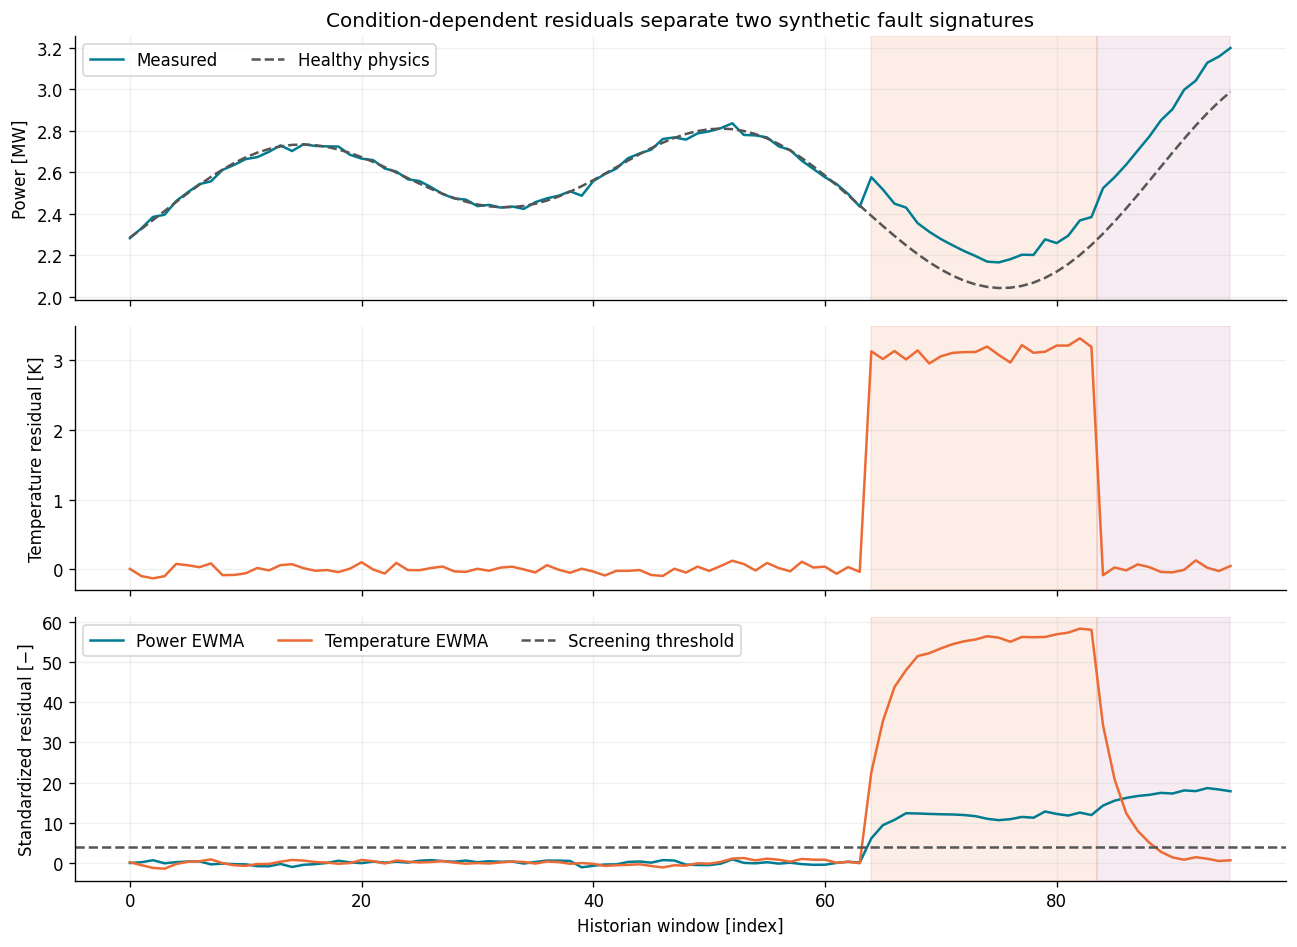

In [16]:
def compressor_point(rate, suction, efficiency):
    train = build_train("Diagnostic compressor", float(rate), float(efficiency), float(suction))
    train["process"].run()
    first = train["compressors"][0]
    return first.getPower("kW") / 1000.0, first.getOutletStream().getTemperature("C")


monitor_count = 96
window = np.arange(monitor_count)
monitor_rng = np.random.default_rng(2048)
monitor_rate = 20 + 2.5 * np.sin(window / 7)
monitor_pressure = 30 + 2 * np.cos(window / 11)
true_eta = np.full(monitor_count, ETA_NOMINAL[0])
true_eta[64:84] -= 0.05
monitor_start = time.perf_counter()
healthy_prediction = np.array(
    [
        compressor_point(rate, pressure, ETA_NOMINAL[0])
        for rate, pressure in zip(monitor_rate, monitor_pressure)
    ]
)
plant_observation = healthy_prediction.copy()
for index in range(64, 84):
    plant_observation[index] = compressor_point(
        monitor_rate[index], monitor_pressure[index], true_eta[index]
    )
plant_observation += monitor_rng.normal(size=(monitor_count, 2)) * [0.012, 0.06]
plant_observation[84:, 0] += 0.22
monitor_seconds_elapsed = time.perf_counter() - monitor_start
physical_residuals = plant_observation - healthy_prediction
calibration_mean = physical_residuals[:40].mean(axis=0)
calibration_scale = physical_residuals[:40].std(axis=0, ddof=1)
standard_residuals = (physical_residuals - calibration_mean) / calibration_scale
residual_filters = [LowPass(1.0), LowPass(1.0)]
# dt = 1 historian window; tau = 1.5 windows gives the former alpha = 0.4.
smoothed_residuals = np.array(
    [
        [float(residual_filters[column].Filter(float(row[column]), 1.5)) for column in range(2)]
        for row in standard_residuals
    ]
)
power_alarm = smoothed_residuals[:, 0] > 4
temperature_alarm = smoothed_residuals[:, 1] > 4
diagnosis = np.full(monitor_count, "within baseline", dtype=object)
diagnosis[power_alarm & temperature_alarm] = "physical change candidate"
diagnosis[power_alarm & ~temperature_alarm] = "power measurement/model candidate"
monitoring = pd.DataFrame(
    {
        "Window": window,
        "Feed [kg/s]": monitor_rate,
        "Suction [bara]": monitor_pressure,
        "Power measured [MW]": plant_observation[:, 0],
        "Power expected [MW]": healthy_prediction[:, 0],
        "Discharge measured [°C]": plant_observation[:, 1],
        "Discharge expected [°C]": healthy_prediction[:, 1],
        "Diagnosis": diagnosis,
    }
)
healthy_false_alarms = int(np.sum(power_alarm[40:64] | temperature_alarm[40:64]))
physical_detection = np.flatnonzero(
    (window >= 64) & (window < 84) & power_alarm & temperature_alarm
)
check(
    "Detect injected efficiency change",
    len(physical_detection) > 0,
    f"First detected window {physical_detection[0] if len(physical_detection) else 'none'}",
)
check(
    "Healthy validation remains quiet",
    healthy_false_alarms <= 1,
    f"{healthy_false_alarms} flagged windows of 24",
)
print(f"Full NeqSim monitoring calculations: {monitor_seconds_elapsed:.2f} s")
print(f"Efficiency-change detection delay: {physical_detection[0] - 64} historian windows")
display(monitoring.iloc[[40, 63, 65, 75, 85, 95]].round(3))
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
axes[0].plot(window, plant_observation[:, 0], color=COLORS[0], label="Measured")
axes[0].plot(window, healthy_prediction[:, 0], color="#555555", ls="--", label="Healthy physics")
axes[0].set(
    ylabel="Power [MW]",
    title="Condition-dependent residuals separate two synthetic fault signatures",
)
axes[0].legend(ncol=2)
axes[1].plot(window, physical_residuals[:, 1], color=COLORS[1])
axes[1].set(ylabel="Temperature residual [K]")
axes[2].plot(window, smoothed_residuals[:, 0], color=COLORS[0], label="Power EWMA")
axes[2].plot(window, smoothed_residuals[:, 1], color=COLORS[1], label="Temperature EWMA")
axes[2].axhline(4, color="#555555", ls="--", label="Screening threshold")
axes[2].set(xlabel="Historian window [index]", ylabel="Standardized residual [−]")
axes[2].legend(ncol=3)
for ax in axes:
    ax.axvspan(64, 83.5, color=COLORS[1], alpha=0.12)
    ax.axvspan(83.5, 95, color=COLORS[3], alpha=0.10)
finish(fig, "10_compressor_diagnostics")

### Estimate a parameter and cross-check a second sensor

For one flagged window, solve for the compressor efficiency that explains measured power, then predict discharge temperature without fitting that temperature. For comparison, repeat at a window containing only a power-meter bias. The synthetic efficiency curve's off-design term is preserved in both forward and inverse calculations.

The fitted parameter is the nominal isentropic efficiency, before the stated off-design correction. A successful scalar inverse solution by itself is insufficient; the independent temperature check makes the engineering interpretation more useful.

In [17]:
inverse_rows = []
for sample, label in [(75, "Efficiency-loss window"), (95, "Power-meter-offset window")]:

    def power_mismatch(efficiency):
        modeled_power, _ = compressor_point(
            monitor_rate[sample], monitor_pressure[sample], efficiency
        )
        return modeled_power - plant_observation[sample, 0]

    estimated_eta = brentq(power_mismatch, 0.55, 0.88, xtol=1e-6)
    _, independent_temperature = compressor_point(
        monitor_rate[sample], monitor_pressure[sample], estimated_eta
    )
    inverse_rows.append(
        {
            "Case": label,
            "Nominal efficiency estimate [−]": estimated_eta,
            "Injected nominal efficiency [−]": true_eta[sample],
            "Independent temperature error [K]": independent_temperature
            - plant_observation[sample, 1],
        }
    )
inverse_results = pd.DataFrame(inverse_rows).set_index("Case")
display(inverse_results.round(4))
check(
    "Efficiency inverse recovery",
    abs(inverse_rows[0]["Nominal efficiency estimate [−]"] - true_eta[75]) < 0.01,
    inverse_rows[0],
)
check(
    "Temperature distinguishes meter-only case",
    abs(inverse_rows[1]["Independent temperature error [K]"]) > 1.0,
    inverse_rows[1],
)

,Nominal efficiency estimate [−],Injected nominal efficiency [−],Independent temperature error [K]
Case,,,
Efficiency-loss window,0.7356,0.73,-0.3616
Power-meter-offset window,0.7286,0.78,3.6117


## 8. Six PID loops inside PlantSimulator

One **14-model PlantSimulator** contains six identified cooler models, six `PidModel`
controllers, one common utility-lag model and one export-header model. Each cooler output
feeds its controller's measurement input; the controller output feeds cooler input 1.
The common utility output feeds input 2 of every cooler, and the six cooler outputs feed
the header. Python assembles the graph and passes the complete dataset; **PlantSimulator
performs every simulation time step**, including feedback and controller limits.

The effective cooling-water temperature is the controller command plus a common utility
offset. The new third input has the same identified cooling-water gain and a zero reference.
The utility model is a prescribed 30 s lag, not a cooling-system energy balance: train loads
do not feed back to it. Header mass weights and the 12 s sensor lag match Section 6.

| Event | Time | Meaning |
|---|---:|---|
| Train A inlet increases by 7 K | 200 s onward | Local load disturbance |
| Utility target rises by 3 K, then returns | 600–1000 s | Common disturbance in nominal cases |
| Every outlet setpoint falls by 0.5 K | 1200 s onward | Coordinated setpoint change |
| Separate utility stress uses 12 K | 600–1000 s | Deliberate limit and recovery test |

Two nominal PI tunings use lambda = 45 and 90 s, with proportional gain based on the
identified cooler gain and each assumed time constant. The manipulated command is in °C,
not valve percent. Native `PidParameters.Scaling` enforces **8–28 °C** and gain scaling is
disabled because the gain is already in engineering units. No Python clamp or manual
controller stepping is used. The 12 K utility stress can leave the identification domain;
it checks numerical limit handling and recovery, not equipment or controller qualification.

**Initialization matters.** For this graph, TSA 1.4.38 did not initialize PID outputs
automatically when the cooler had both PID and utility-model inputs. The case supplies
consistent initial controller outputs at the nominal steady point and disables disturbance
estimation for this forward simulation. TSA's dataset API requires vectors for these seeds.
Section 8.1 changes every seed value after the first sample and checks that results are
unchanged: subsequent controller actions come from the simulator, not a prescribed history.
This observed initialization limitation is distinct from a Python.NET interface failure.

$$IAE=\int_0^{t_f}|T(t)-T_{set}(t)|\,dt$$

Per-train IAE is in K·s. Peak and final error, native saturation counts, and header response
make the tuning comparison visible. Real valve dynamics, cooling capacity, transport delays
and field closed-loop data remain necessary before deployment.

,Scenario,Train,IAE [K s],Peak error [K],Final error [K],Saturated samples
0,PI lambda 45 s,Train A,277.5120,0.8515,0.0,0
1,PI lambda 45 s,Train B,226.6529,0.8183,-0.0,0
2,PI lambda 45 s,Train C,223.2893,0.7877,-0.0,0
3,PI lambda 45 s,Train D,220.1732,0.7592,-0.0,0
4,PI lambda 45 s,Train E,217.4695,0.7330,-0.0,0
5,PI lambda 45 s,Train F,215.1578,0.7086,-0.0,0
6,PI lambda 90 s,Train A,494.1884,1.2218,-0.0,0
7,PI lambda 90 s,Train B,398.0249,1.1786,-0.0,0
8,PI lambda 90 s,Train C,396.9909,1.1446,-0.0,0
9,PI lambda 90 s,Train D,395.7933,1.1123,-0.0,0


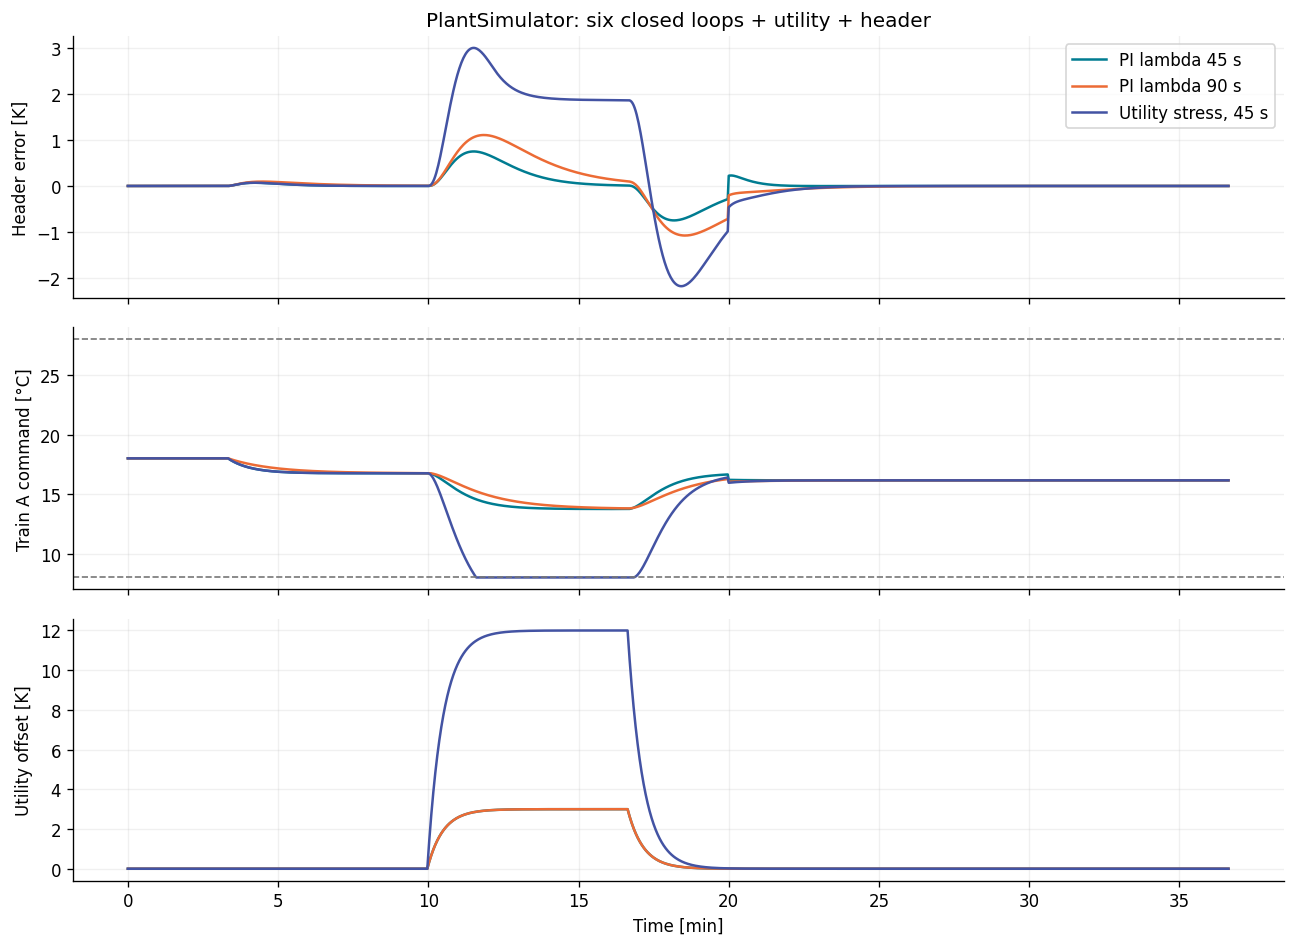

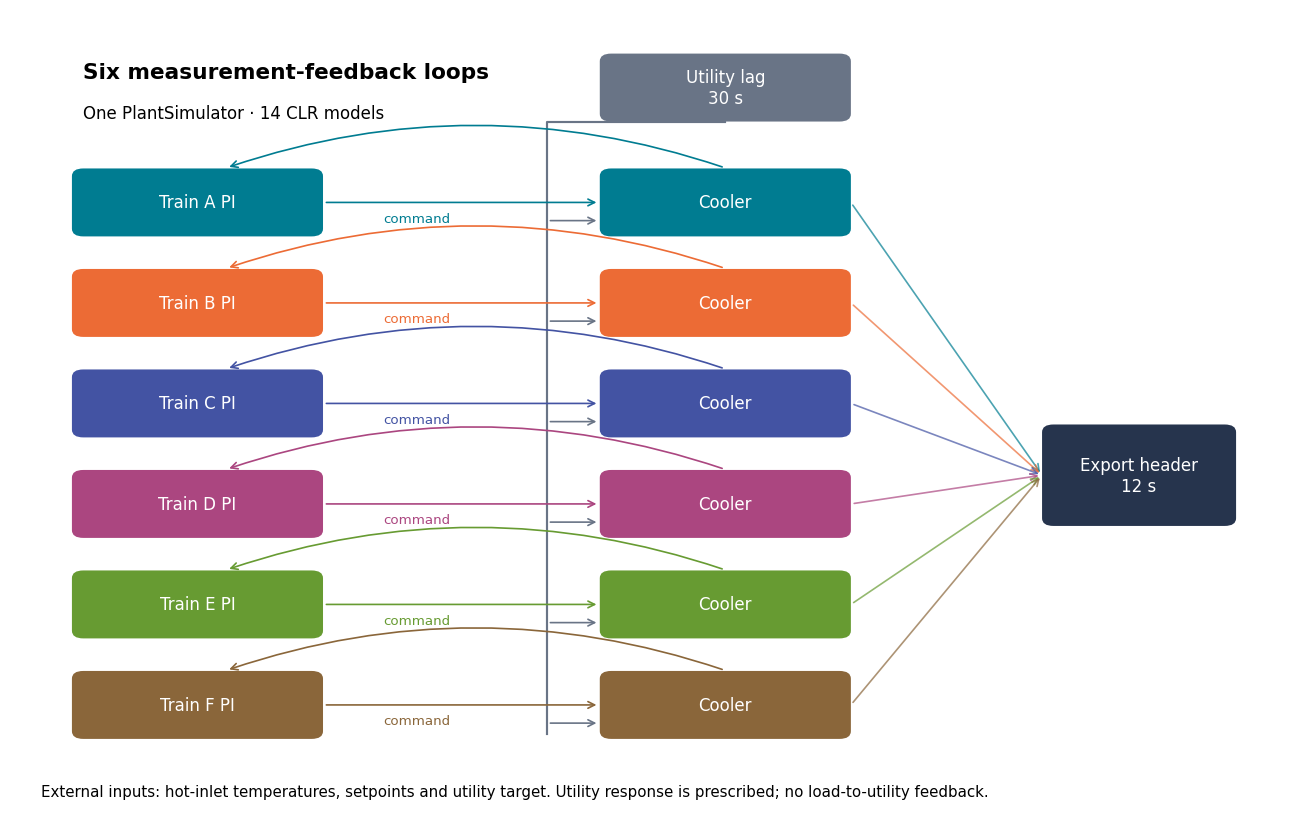

In [18]:
def make_control_case(copies=6, lambda_s=45.0, samples=1100, utility_step_K=3.0):
    """Portable model specification for the Python binding comparison."""
    timeline = np.arange(samples) * dt
    reference = list(fit_parameters.U0)
    target = float(identified.GetSteadyStateOutput(netarray([hot_temperature, coolant_reference])))
    header_weights = weights.tolist() if copies == 6 else [1.0 / copies] * copies
    models = [
        {
            "id": "utility",
            "type": "unit",
            "gains": [1.0],
            "reference": [0.0],
            "bias": 0.0,
            "tau_s": 30.0,
        },
        {
            "id": "header",
            "type": "unit",
            "gains": header_weights,
            "reference": [0.0] * copies,
            "bias": 0.0,
            "tau_s": 12.0,
        },
    ]
    connections, external = [], []
    signals = {
        "utility_event_K": np.where(
            (timeline >= 600) & (timeline < 1000), utility_step_K, 0.0
        ).tolist()
    }
    external.append(["utility", "utility_event_K", "External_U", 0])
    for i in range(copies):
        cooler, controller = f"cooler_{i}", f"pid_{i}"
        tau = float(fit_parameters.TimeConstant_s * (0.75 + 0.1 * (i % 6)))
        models.extend(
            [
                {
                    "id": cooler,
                    "type": "unit",
                    "gains": [*fit_gains, float(fit_gains[1])],
                    "reference": [*reference, 0.0],
                    "bias": float(fit_parameters.Bias),
                    "tau_s": tau,
                },
                {
                    "id": controller,
                    "type": "pid",
                    "kp": tau / (float(fit_gains[1]) * lambda_s),
                    "ti_s": tau,
                    "u0": coolant_reference,
                    "u_min": 8.0,
                    "u_max": 28.0,
                },
            ]
        )
        # None uses PlantSimulator's process-to-PID Y_meas inference.
        connections.extend(
            [
                [cooler, controller, None],
                [controller, cooler, 1],
                ["utility", cooler, 2],
                [cooler, "header", i],
            ]
        )
        external.extend(
            [
                [cooler, f"hot_{i}_C", "External_U", 0],
                [controller, f"set_{i}_C", "Setpoint_Yset", 0],
            ]
        )
        signals[f"hot_{i}_C"] = (hot_temperature + 7.0 * (timeline >= 200) * (i == 0)).tolist()
        signals[f"set_{i}_C"] = (target - 0.5 * (timeline >= 1200)).tolist()
    return {
        "schema_version": 1,
        "name": f"{copies}-loop cooler plant",
        "dt_s": dt,
        "models": models,
        "connections": connections,
        "external": external,
        "signals": signals,
        "outputs": [model["id"] for model in models],
    }


def build_dotnet_case(case):
    models = {}
    for spec in case["models"]:
        if spec["type"] == "unit":
            model = unit_model(
                spec["id"], spec["gains"], spec["bias"], spec["tau_s"], spec["reference"]
            )
        elif spec["type"] == "pid":
            params = PidParameters()
            params.Kp, params.Ti_s, params.u0 = spec["kp"], spec["ti_s"], spec["u0"]
            # Engineering-unit gain; native controller output limits, no Python clipping.
            params.Scaling.Set(0.0, 100.0, spec["u_min"], spec["u_max"], False)
            model = PidModel(params, spec["id"])
        else:
            raise ValueError(f"Unsupported model type: {spec['type']}")
        if spec["id"] in models:
            raise ValueError("Duplicate model ID")
        models[spec["id"]] = model
    plant = bridge.plant(models.values(), case["name"], "Six loops and common utility event")
    for upstream, downstream, input_index in case["connections"]:
        if input_index is None:
            signal = plant.ConnectModels(models[upstream], models[downstream])
        else:
            signal = plant.ConnectModels(models[upstream], models[downstream], int(input_index))
        if signal is None:
            raise ValueError(f"Could not connect {upstream} to {downstream}.")
    for model_id, signal_id, signal_type, input_index in case["external"]:
        result = plant.AddAndConnectExternalSignal(
            models[model_id], signal_id, getattr(SignalType, signal_type), int(input_index)
        )
        if result is None:
            raise ValueError(f"Could not connect external signal {signal_id}.")
    frame = pd.DataFrame(case["signals"])
    # TSA 1.4.38 needs explicit steady PID seeds for this multi-input graph.
    # Only the first value initializes state; simulated outputs drive subsequent steps.
    for spec in case["models"]:
        if spec["type"] == "pid":
            frame[str(models[spec["id"]].GetOutputID())] = spec["u0"]
    frame.index = pd.Index(np.arange(len(frame)) * case["dt_s"], name="Elapsed time [s]")
    output_map = {str(models[name].GetOutputID()): name for name in case["outputs"]}
    return plant, frame, output_map


def run_dotnet_case(case):
    plant, frame, output_map = build_dotnet_case(case)
    return bridge.simulate(plant, frame, case["dt_s"], output_map).rename(columns=output_map)


control_cases = {
    "PI lambda 45 s": make_control_case(lambda_s=45.0),
    "PI lambda 90 s": make_control_case(lambda_s=90.0),
    "Utility stress, 45 s": make_control_case(lambda_s=45.0, utility_step_K=12.0),
}
control_results = {name: run_dotnet_case(case) for name, case in control_cases.items()}
control_rows = []
for name, result in control_results.items():
    case = control_cases[name]
    for i, train in enumerate(TRAIN_NAMES):
        error = result[f"cooler_{i}"].values - np.array(case["signals"][f"set_{i}_C"])
        command = result[f"pid_{i}"].values
        saturated = np.isclose(command, 8.0, atol=1e-7) | np.isclose(command, 28.0, atol=1e-7)
        control_rows.append(
            {
                "Scenario": name,
                "Train": train,
                "IAE [K s]": abs(error).sum() * dt,
                "Peak error [K]": abs(error).max(),
                "Final error [K]": error[-1],
                "Saturated samples": int(saturated.sum()),
            }
        )
    check(
        f"{name}: native command bounds",
        result.filter(like="pid_").min().min() >= 8 - 1e-8
        and result.filter(like="pid_").max().max() <= 28 + 1e-8,
        "All six controllers",
    )
control_summary = pd.DataFrame(control_rows)
display(control_summary.round(4))
check(
    "Six-loop settling after events",
    control_summary["Final error [K]"].abs().max() < 0.01,
    float(control_summary["Final error [K]"].abs().max()),
)
nominal_rows = control_summary[control_summary.Scenario != "Utility stress, 45 s"]
check(
    "Nominal scenarios unsaturated",
    nominal_rows["Saturated samples"].sum() == 0,
    int(nominal_rows["Saturated samples"].sum()),
)
check(
    "Utility stress reaches actuator limit",
    control_summary.query("Scenario == 'Utility stress, 45 s'")["Saturated samples"].min() > 0,
    "Each controller reaches a native limit and subsequently recovers",
)
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for color, (name, result) in zip(COLORS, control_results.items()):
    t = result.index.to_numpy()
    setpoint = np.array(control_cases[name]["signals"]["set_0_C"])
    axes[0].plot(t / 60, result.header - setpoint, label=name, color=color)
    axes[1].plot(t / 60, result.pid_0, color=color)
    axes[2].plot(t / 60, result.utility, color=color)
axes[0].set(ylabel="Header error [K]", title="PlantSimulator: six closed loops + utility + header")
axes[0].legend(ncol=1)
axes[1].set(ylabel="Train A command [°C]", ylim=(7, 29))
axes[1].axhline(8, color="#777777", ls="--", lw=1)
axes[1].axhline(28, color="#777777", ls="--", lw=1)
axes[2].set(xlabel="Time [min]", ylabel="Utility offset [K]")
finish(fig, "11_pid_screening")

fig, ax = plt.subplots(figsize=(11, 7))
ax.set(xlim=(0.5, 9.5), ylim=(-0.5, 7.9))
ax.axis("off")


def graph_box(x, y, label, color, width=1.6, height=0.55):
    patch = FancyBboxPatch(
        (x, y - height / 2),
        width,
        height,
        boxstyle="round,pad=0.08",
        facecolor=color,
        edgecolor="none",
    )
    ax.add_patch(patch)
    ax.text(x + width / 2, y, label, ha="center", va="center", color="white", fontsize=10)


graph_box(4.7, 7.1, "Utility lag\n30 s", "#697486")
graph_box(7.8, 3.05, "Export header\n12 s", "#26344D", width=1.2, height=0.9)
ax.plot([5.5, 4.25, 4.25], [6.74, 6.74, 0.35], color="#697486", lw=1.3)
for i, train in enumerate(TRAIN_NAMES):
    y = 5.9 - 1.05 * i
    graph_box(1.0, y, f"{train} PI", COLORS[i])
    graph_box(4.7, y, "Cooler", COLORS[i])
    ax.annotate("", (4.62, y), (2.68, y), arrowprops={"arrowstyle": "->", "color": COLORS[i]})
    ax.text(3.1, y - 0.2, "command", fontsize=8, color=COLORS[i])
    ax.annotate(
        "",
        (2.0, y + 0.36),
        (5.5, y + 0.36),
        arrowprops={"arrowstyle": "->", "color": COLORS[i], "connectionstyle": "arc3,rad=0.17"},
    )
    ax.annotate(
        "", (4.62, y - 0.19), (4.25, y - 0.19), arrowprops={"arrowstyle": "->", "color": "#697486"}
    )
    ax.annotate(
        "",
        (7.72, 3.05),
        (6.38, y),
        arrowprops={"arrowstyle": "->", "color": COLORS[i], "alpha": 0.7},
    )
ax.text(1.0, 7.2, "Six measurement-feedback loops", fontsize=13, weight="bold")
ax.text(1.0, 6.78, "One PlantSimulator · 14 CLR models", fontsize=10)
ax.text(
    0.7,
    -0.3,
    "External inputs: hot-inlet temperatures, setpoints and utility target. "
    "Utility response is prescribed; no load-to-utility feedback.",
    fontsize=9,
)
finish(fig, "11b_control_graph")

### 8.1. A concrete acceptance case for the Python wrapper

We serialize and restore the complete graph, repeat simulation on the restored object,
and verify every output. We also test that PID initialization seeds do not impose future
controller actions. Serialization here reloads the graph created by this notebook.

`compare_binding(run_candidate, case, expected)` defines a small Python-facing contract:
the adapter receives the exported model definitions, connections, external inputs and sample
interval, then returns a dataframe indexed by elapsed seconds with one column per output
model ID. It must initialize controllers consistently and run the same graph and events.
The saved test invokes the direct Python.NET backend again to exercise the harness.
**No official-wrapper comparison has been executed.**

When the wrapper is accessible, pin its commit and bundled assembly, implement
`run_candidate(case)` using its documented API, and call this comparison with the exported
case and reference dataframe. With the same assembly and settings, the tolerance is an
absolute 1e-8 in each signal's engineering units. If the wrapper uses another assembly,
record that change and investigate numerical differences before accepting a new baseline.

This tests a useful subset of the binding surface, not the whole public API. Custom Python
implementations of CLR interfaces, gain-scheduled/select models, closed-loop and PID
identifiers, variable sample intervals and other overloads need separate acceptance cases.

In [19]:
# A portable six-loop case and its numeric baseline can be run through another binding.
conformance_case = control_cases["PI lambda 45 s"]
expected_result = control_results["PI lambda 45 s"]
plant_for_replay, frame_for_replay, replay_map = build_dotnet_case(conformance_case)
plant_json = str(plant_for_replay.SerializeTxt())
restored_plant = PlantSimulatorSerializer.LoadFromJsonTxt(plant_json)
restored_result = bridge.simulate(restored_plant, frame_for_replay, dt, replay_map)
restored_result = restored_result.rename(columns=replay_map)
repeated_result = bridge.simulate(restored_plant, frame_for_replay, dt, replay_map)
repeated_result = repeated_result.rename(columns=replay_map)
check(
    "Serialized plant preserves all models",
    restored_plant.GetModels().Count == 14,
    restored_plant.GetModels().Count,
)
check(
    "Plant JSON round-trip response",
    np.allclose(restored_result, expected_result, atol=1e-8),
    float(np.max(abs(restored_result.values - expected_result.values))),
)
check(
    "Repeated Simulate resets initial state",
    np.allclose(repeated_result, expected_result, atol=1e-8),
    float(np.max(abs(repeated_result.values - expected_result.values))),
)


seed_tail_frame = frame_for_replay.copy()
seed_columns = [column for column in seed_tail_frame if str(column).endswith("-PID_U")]
seed_tail_frame.loc[seed_tail_frame.index[1:], seed_columns] = 27.0
seed_tail_plant = PlantSimulatorSerializer.LoadFromJsonTxt(plant_json)
seed_tail_result = bridge.simulate(seed_tail_plant, seed_tail_frame, dt, replay_map)
check(
    "PID seed tails do not prescribe controller actions",
    np.allclose(seed_tail_result, expected_result, atol=1e-8),
    float(np.max(abs(seed_tail_result.values - expected_result.values))),
)


def compare_binding(run_candidate, case, expected, atol=1e-8):
    """run_candidate(case) must return seconds-indexed outputs named by model ID."""
    before = json.dumps(case, sort_keys=True)
    candidate = run_candidate(json.loads(before))
    if not isinstance(candidate, pd.DataFrame):
        raise TypeError("Binding adapter must return a pandas DataFrame.")
    if set(candidate.columns) != set(expected.columns):
        raise ValueError("Output model IDs differ from the reference.")
    if not candidate.index.equals(expected.index):
        raise ValueError("Elapsed-second sample index differs from the reference.")
    candidate = candidate.loc[:, expected.columns]
    error = abs(candidate.to_numpy(dtype=float) - expected.to_numpy(dtype=float))
    passed = np.isfinite(error).all() and np.all(error <= atol)
    if not passed:
        raise AssertionError(f"Binding parity failed; maximum absolute error {error.max():.6g}")
    return pd.Series(
        {
            "Signals": error.shape[1],
            "Samples": error.shape[0],
            "Maximum absolute difference": float(error.max()),
            "Passed": True,
        }
    )


reference_parity = compare_binding(run_dotnet_case, conformance_case, expected_result)
display(reference_parity.to_frame("Same-backend harness self-check"))
check(
    "Binding comparison harness executes",
    bool(reference_parity["Passed"]),
    "Direct Python.NET reference only; official wrapper is not tested",
)
# The data boundary rejects gaps instead of silently changing sample timing.
invalid_frame = frame_for_replay.copy()
invalid_frame.iloc[0, 0] = np.nan
try:
    bridge.dataset(invalid_frame, dt)
except ValueError as error:
    invalid_input_rejected = "NaN/Inf" in str(error)
else:
    invalid_input_rejected = False
check("Adapter rejects unqualified input", invalid_input_rejected, "NaN input rejected")

interface_evidence = pd.DataFrame(
    [
        ["List[ISimulatableModel]", "UnitModel and PidModel accepted in the same list"],
        ["double[] and timestamps", "Finite aligned input/output vectors and UTC start date"],
        ["Enums and nullable index", "External_U, Setpoint_Yset, omitted and explicit indices"],
        ["ref / out conversion", "IdentifyLinear and PlantSimulator.Simulate tuple returns"],
        ["Feedback and limits", "Six loops, native PID bounds, stress and recovery"],
        ["Serialization and rerun", "14-model graph and numerical response reproduced"],
    ],
    columns=["Boundary", "Direct Python.NET evidence"],
)
interface_evidence["Official wrapper"] = "Not executed: repository inaccessible"
display(interface_evidence)
fixture = {
    "provenance": provenance,
    "case": conformance_case,
    "expected_csv": "binding_reference_outputs.csv",
    "absolute_tolerance": 1e-8,
    "reference_backend": "Python.NET 3.1.0 / TimeSeriesAnalysis 1.4.38",
    "wrapper_status": "Repository returned 404 on 2026-09-16; API not inspected",
}
(outdir / "binding_conformance_case.json").write_text(json.dumps(fixture, indent=2))
expected_result.to_csv(outdir / "binding_reference_outputs.csv")
(outdir / "connected_plant.json").write_text(plant_json)
print("Exported a portable case, expected outputs, and the tested CLR plant JSON.")

Exported a portable case, expected outputs, and the tested CLR plant JSON.


,Same-backend harness self-check
Signals,14
Samples,1100
Maximum absolute difference,0.0
Passed,True


,Boundary,Direct Python.NET evidence,Official wrapper
0,List[ISimulatableModel],UnitModel and PidModel accepted in the same list,Not executed: repository inaccessible
1,double[] and timestamps,Finite aligned input/output vectors and UTC start date,Not executed: repository inaccessible
2,Enums and nullable index,"External_U, Setpoint_Yset, omitted and explicit indices",Not executed: repository inaccessible
3,ref / out conversion,IdentifyLinear and PlantSimulator.Simulate tuple returns,Not executed: repository inaccessible
4,Feedback and limits,"Six loops, native PID bounds, stress and recovery",Not executed: repository inaccessible
5,Serialization and rerun,14-model graph and numerical response reproduced,Not executed: repository inaccessible


## 9. Scale by separating expensive physics from frequent inference

The facility object retains the detailed unit models. A production analytics service can update physical operating points when composition, pressure, equipment state or operating region changes, then run qualified reduced models at the historian sampling rate. Revalidate after maintenance, sensor changes or excursions beyond the training envelope.

The following timings are observations from this runtime. The workloads differ, so their ratio must not be presented as a like-for-like simulator speedup. The network benchmark holds 200 samples fixed and increases the number of connected first-order models. Construction and Python-to-.NET data preparation are excluded from its simulation timing and are measured separately.

For process scale, use explicit tag-to-equipment mappings and fixed units, quality masks, chronological qualification windows and versioned model registries. Share plain numeric arrays or tables across worker processes; do not share mutable Java or .NET process objects between unsynchronized workers. The notebook uses serial calls for reproducibility.

The timing experiment now contains 6, 24 and 96 **closed PID loops**, with a shared utility and header: 14, 50 and 194 connected models. Each run uses 200 samples (398 s), covering the local inlet event; the later utility and setpoint events are outside this short timing window. The full six-loop experiments above cover all events.

,Control loops,Connected models,Time samples,Preparation [s],Simulation [s],Output samples/s
0,6,14,200,0.003,0.008,359374.924
1,24,50,200,0.006,0.025,392734.043
2,96,194,200,0.024,0.239,162197.046


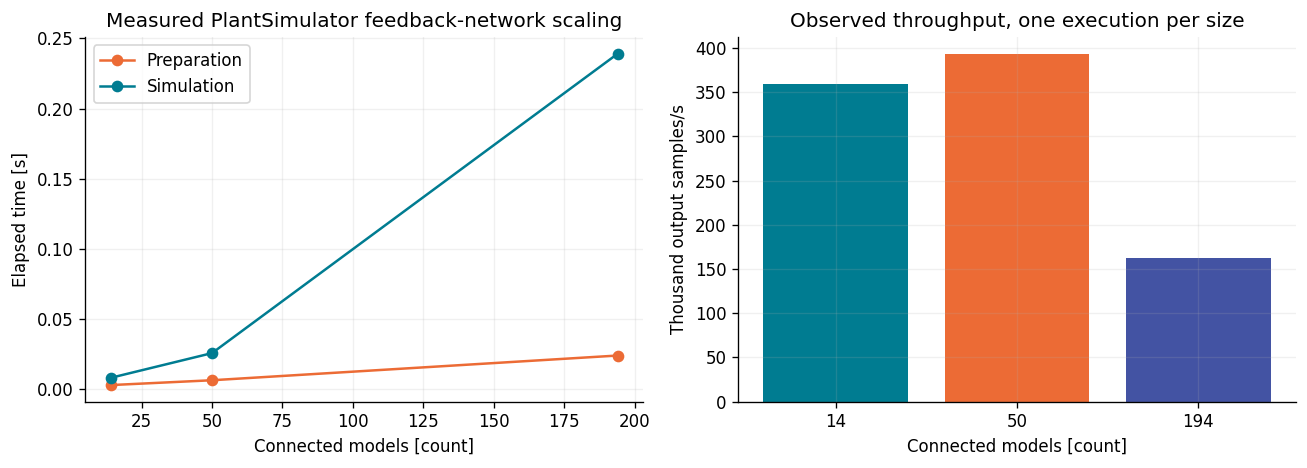

In [20]:
scaling_rows = []
for copies in [6, 24, 96]:
    prepare_start = time.perf_counter()
    fleet_case = make_control_case(copies=copies, samples=200)
    fleet_plant, fleet_frame, fleet_map = build_dotnet_case(fleet_case)
    prepare_seconds = time.perf_counter() - prepare_start
    started = time.perf_counter()
    fleet_result = bridge.simulate(fleet_plant, fleet_frame, dt, fleet_map)
    elapsed = time.perf_counter() - started
    models_count = 2 * copies + 2
    check(
        f"Closed-loop fleet {copies}",
        fleet_plant.GetModels().Count == models_count,
        f"{copies} PID loops + shared utility + header; {fleet_result.size} finite values",
    )
    scaling_rows.append(
        {
            "Control loops": copies,
            "Connected models": models_count,
            "Time samples": len(fleet_frame),
            "Preparation [s]": prepare_seconds,
            "Simulation [s]": elapsed,
            "Output samples/s": fleet_result.size / elapsed,
        }
    )
scaling = pd.DataFrame(scaling_rows)
display(scaling.round(3))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(
    scaling["Connected models"],
    scaling["Preparation [s]"],
    "o-",
    label="Preparation",
    color=COLORS[1],
)
axes[0].plot(
    scaling["Connected models"],
    scaling["Simulation [s]"],
    "o-",
    label="Simulation",
    color=COLORS[0],
)
axes[0].set(
    xlabel="Connected models [count]",
    ylabel="Elapsed time [s]",
    title="Measured PlantSimulator feedback-network scaling",
)
axes[0].legend()
axes[1].bar(
    scaling["Connected models"].astype(str), scaling["Output samples/s"] / 1000, color=COLORS[:3]
)
axes[1].set(
    xlabel="Connected models [count]",
    ylabel="Thousand output samples/s",
    title="Observed throughput, one execution per size",
)
finish(fig, "12_scaling")

## 10. Process input JSON becomes a material graph

**Yes: process JSON can supply topology, operating values and an analytics tag map. It does not, by itself, supply dynamic time constants or a TimeSeriesAnalysis model.** This example makes the conversion explicit and runs the physical process using NeqSim's native `ProcessSystem.fromJson` builder.

The reference [comparesimulations2 notebook](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/comparesimulations2.ipynb) combines a Python process factory with JSON operating settings. Here we build a similar, smaller **24-unit oil-stabilization and flash-gas-compression process**, with its equipment and connections declared in the input JSON itself. This is a new synthetic case, not a reproduction of the reference notebook's numerical results or petroleum assay.

The feed is 120 kg/s of a nine-component hydrocarbon mixture at 60 bara and 60 °C. Three separators operate initially at 32, 8 and 2 bara, with reheating to 60 °C. Flash gas is recompressed and combined; scrubber condensate returns to either the LP or MP stage. Export compression reaches 120 bara; oil is cooled and pumped to 20 bara. PR equilibrium and constant equipment efficiencies are used. There is no water phase, compressor map, hydraulic network or product-vapour-pressure specification. The cooled gas product can contain condensed hydrocarbon; it is an exported total stream, not a guaranteed dry-gas specification.

| Input JSON part | NeqSim use | Graph / time-series use |
|---|---|---|
| `fluid` | EOS, composition and starting conditions | Composition scenario and model provenance |
| `process` equipment and `inlet` / `inlets` | Native equipment construction and wiring | Directed edges with source ports and input indices |
| Equipment properties | Pressures, efficiencies and temperatures | Operating point and manipulated-variable targets |
| `metadata.products` | Adapter resolves equipment outlet references | Named output tags and balance boundary |
| `metadata.optimization` | Adapter changes declared property targets | Bounds, route alternatives and assumed constraints |
| `metadata.time_series` | No native dynamic effect | Explicitly assumed sample interval and response times |

`metadata` is notebook adapter information; TSA does not directly import NeqSim process JSON. Keep the native process input and the separately exported TSA plant JSON distinct.

### 10.1 Declare the similar process

All process connections below are data. The two allowed return routes represent pre-engineered alternatives. A graph cannot certify that any arbitrary connection is mechanically possible: pressure compatibility, phase handling, controls and equipment design still need engineering checks.

In [21]:
import copy
import networkx as nx


def make_stabilization_json(route="LP"):
    """Synthetic three-stage oil stabilization and flash-gas recompression."""
    if route not in ("LP", "MP"):
        raise ValueError("Condensate return must be one of the engineered LP/MP alternatives.")
    units = [
        {"type": "Stream", "name": "Feed", "properties": {"flowRate": [120.0, "kg/sec"]}},
        {
            "type": "ThrottlingValve",
            "name": "HP valve",
            "inlet": "Feed",
            "properties": {"outletPressure": [32.0, "bara"]},
        },
        {
            "type": "Heater",
            "name": "HP heater",
            "inlet": "HP valve.out",
            "properties": {"outTemperature": [60.0, "C"]},
        },
        {"type": "Separator", "name": "HP separator", "inlet": "HP heater.out"},
        {
            "type": "ThrottlingValve",
            "name": "MP valve",
            "inlet": "HP separator.liquidOut",
            "properties": {"outletPressure": [8.0, "bara"]},
        },
        {"type": "Mixer", "name": "MP mixer", "inlets": ["MP valve.out"]},
        {
            "type": "Heater",
            "name": "MP heater",
            "inlet": "MP mixer.out",
            "properties": {"outTemperature": [60.0, "C"]},
        },
        {"type": "Separator", "name": "MP separator", "inlet": "MP heater.out"},
        {
            "type": "ThrottlingValve",
            "name": "LP valve",
            "inlet": "MP separator.liquidOut",
            "properties": {"outletPressure": [2.0, "bara"]},
        },
        {"type": "Mixer", "name": "LP mixer", "inlets": ["LP valve.out"]},
        {
            "type": "Heater",
            "name": "LP heater",
            "inlet": "LP mixer.out",
            "properties": {"outTemperature": [60.0, "C"]},
        },
        {"type": "Separator", "name": "LP separator", "inlet": "LP heater.out"},
        {
            "type": "Compressor",
            "name": "LP compressor",
            "inlet": "LP separator.gasOut",
            "properties": {"outletPressure": [8.0, "bara"], "isentropicEfficiency": 0.76},
        },
        {
            "type": "Mixer",
            "name": "MP gas mixer",
            "inlets": ["LP compressor.out", "MP separator.gasOut"],
        },
        {
            "type": "Compressor",
            "name": "MP compressor",
            "inlet": "MP gas mixer.out",
            "properties": {"outletPressure": [32.0, "bara"], "isentropicEfficiency": 0.76},
        },
        {
            "type": "Mixer",
            "name": "HP gas mixer",
            "inlets": ["MP compressor.out", "HP separator.gasOut"],
        },
        {
            "type": "Cooler",
            "name": "Gas cooler",
            "inlet": "HP gas mixer.out",
            "properties": {"outTemperature": [30.0, "C"]},
        },
        {"type": "Separator", "name": "Gas scrubber", "inlet": "Gas cooler.out"},
        {
            "type": "ThrottlingValve",
            "name": "Return valve",
            "inlet": "Gas scrubber.liquidOut",
            "properties": {"outletPressure": [2.0 if route == "LP" else 8.0, "bara"]},
        },
        {
            "type": "Recycle",
            "name": "Condensate recycle",
            "inlet": "Return valve.out",
            "properties": {"tolerance": 1e-8, "absoluteFlowTolerance": 1e-6},
        },
        {
            "type": "Compressor",
            "name": "Export compressor",
            "inlet": "Gas scrubber.gasOut",
            "properties": {"outletPressure": [120.0, "bara"], "isentropicEfficiency": 0.78},
        },
        {
            "type": "Cooler",
            "name": "Export cooler",
            "inlet": "Export compressor.out",
            "properties": {"outTemperature": [40.0, "C"]},
        },
        {
            "type": "Cooler",
            "name": "Oil cooler",
            "inlet": "LP separator.liquidOut",
            "properties": {"outTemperature": [40.0, "C"]},
        },
        {
            "type": "Pump",
            "name": "Oil pump",
            "inlet": "Oil cooler.out",
            "properties": {"outletPressure": [20.0, "bara"], "isentropicEfficiency": 0.75},
        },
    ]
    by_name = {unit["name"]: unit for unit in units}
    by_name[f"{route} mixer"]["inlets"].append("Condensate recycle.out")
    return {
        "fluid": {
            "model": "PR",
            "temperature": 333.15,
            "pressure": 60.0,
            "mixingRule": "classic",
            "multiPhaseCheck": True,
            "components": {
                "methane": 0.54,
                "ethane": 0.07,
                "propane": 0.06,
                "n-butane": 0.04,
                "n-pentane": 0.03,
                "n-hexane": 0.03,
                "n-heptane": 0.03,
                "n-decane": 0.10,
                "nC16": 0.10,
            },
        },
        "process": units,
        "metadata": {
            "case": "Synthetic oil stabilization; inspired by comparesimulations2",
            "condensate_return": route,
            "allowed_returns": ["LP", "MP"],
            "products": {"gas": "Export cooler.out", "oil": "Oil pump.out"},
            "optimization": {
                "variables": [
                    {
                        "name": "HP pressure",
                        "unit": "bara",
                        "bounds": [24.0, 44.0],
                        "targets": [
                            ["HP valve", "outletPressure"],
                            ["MP compressor", "outletPressure"],
                        ],
                    },
                    {
                        "name": "MP pressure",
                        "unit": "bara",
                        "bounds": [4.0, 14.0],
                        "targets": [
                            ["MP valve", "outletPressure"],
                            ["LP compressor", "outletPressure"],
                        ],
                    },
                ],
                "objective": "Minimize total compressor and pump shaft power at fixed feed",
                "minimum_oil_fraction_of_base": 0.998,
            },
            "time_series": {
                "sample_interval_s": 2.0,
                "assumed_tau_s": {
                    "LP compressor": 45.0,
                    "MP compressor": 60.0,
                    "Export compressor": 30.0,
                    "Oil pump": 90.0,
                },
            },
        },
    }


def set_json_pressures(case, values):
    updated = copy.deepcopy(case)
    units = {unit["name"]: unit for unit in updated["process"]}
    for value, variable in zip(values, updated["metadata"]["optimization"]["variables"]):
        for equipment, property_name in variable["targets"]:
            units[equipment]["properties"][property_name] = [float(value), variable["unit"]]
    if updated["metadata"]["condensate_return"] == "MP":
        units["Return valve"]["properties"]["outletPressure"] = [float(values[1]), "bara"]
    return updated


print("Native JSON process factory ready:", len(make_stabilization_json()["process"]), "units")

Native JSON process factory ready: 24 units


### 10.2 Parse connections, identify recycle groups and draw the graph

A material flowsheet with condensate return is a **directed graph with a cycle**, rather than a tree. A strongly connected component groups the equipment whose states depend on the recycle. Removing the declared recycle-return edge provides a topological ordering for analysis; NeqSim's actual `Recycle` equipment still closes the loop during simulation.

The adapter rejects duplicate names, missing sources, unsupported ports and disconnected equipment. This small adapter reads products through equipment outlet references and deliberately excludes Stream aliases. The earlier native Stream-inlet issue [NeqSim #3728](https://github.com/equinor/neqsim/issues/3728) is now closed and the updated source supports wiring such inlets; the adapter retains its explicit, narrower product-reference contract.

JSON equipment types: ['Compressor', 'Cooler', 'Heater', 'Mixer', 'Pump', 'Recycle', 'Separator', 'Stream', 'ThrottlingValve']


,Return,Equipment,Connections,Equipment in recycle group,Tear destination
0,LP,24,26,11,LP mixer
1,MP,24,26,15,MP mixer


,Source,Port,Destination,Input
0,Feed,out,HP valve,0
1,HP valve,out,HP heater,0
2,HP heater,out,HP separator,0
3,HP separator,liquidOut,MP valve,0
4,HP separator,gasOut,HP gas mixer,1
5,MP valve,out,MP mixer,0
6,MP mixer,out,MP heater,0
7,MP heater,out,MP separator,0
8,MP separator,liquidOut,LP valve,0
9,MP separator,gasOut,MP gas mixer,1


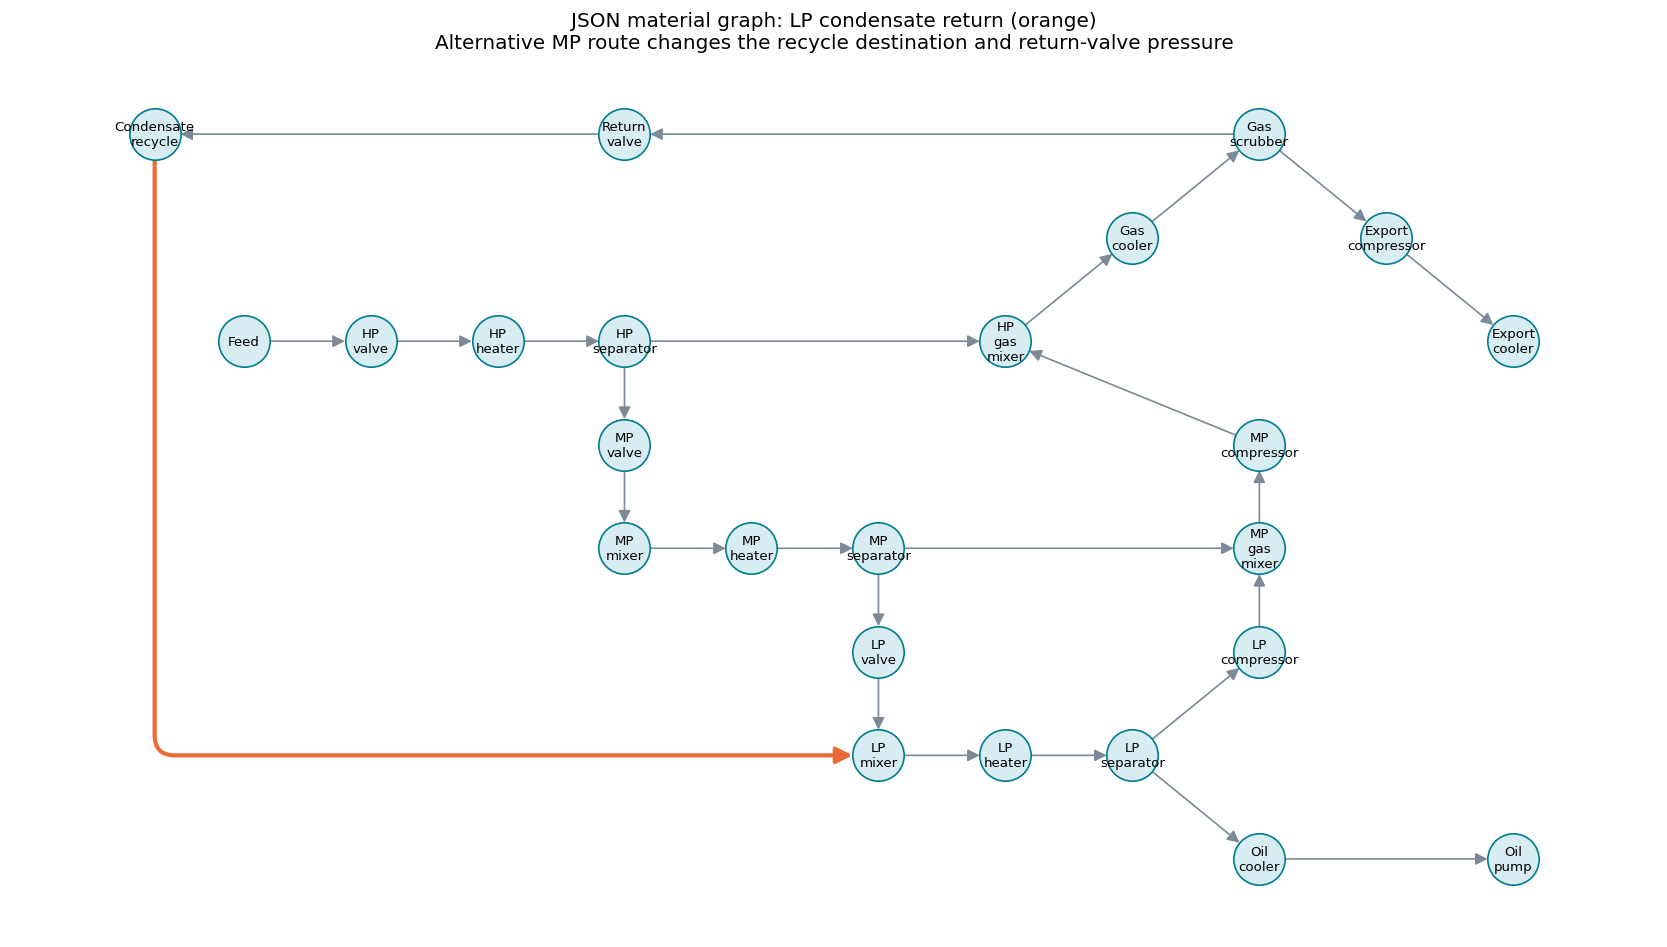

In [22]:
def process_graph(spec):
    """Strict adapter for the equipment/ports supported in this demonstration."""
    graph = nx.MultiDiGraph()
    for unit in spec["process"]:
        name = unit["name"]
        if name in graph:
            raise ValueError(f"Duplicate equipment name: {name}")
        if unit["type"] == "Stream" and ("inlet" in unit or "inlets" in unit):
            raise ValueError("Use an equipment outlet reference for products, not Stream aliases.")
        graph.add_node(name, kind=unit["type"])
    for unit in spec["process"]:
        references = unit.get("inlets", [unit["inlet"]] if "inlet" in unit else [])
        for index, reference in enumerate(references):
            upstream, _, port = reference.partition(".")
            if upstream not in graph:
                raise ValueError(f"Unknown source: {reference}")
            kind = graph.nodes[upstream]["kind"]
            allowed = {"gasOut", "liquidOut"} if kind == "Separator" else {"out"}
            if (port or "out") not in allowed:
                raise ValueError(f"Unsupported port: {reference}")
            graph.add_edge(upstream, unit["name"], port=port or "out", input_index=index)
    if nx.descendants(graph, "Feed") | {"Feed"} != set(graph.nodes):
        raise ValueError("All equipment must be reachable from Feed.")
    return graph


def graph_connections(graph):
    return pd.DataFrame(
        [
            {"Source": a, "Port": d["port"], "Destination": b, "Input": d["input_index"]}
            for a, b, d in graph.edges(data=True)
        ]
    )


json_base_spec = make_stabilization_json("LP")
json_graphs = {route: process_graph(make_stabilization_json(route)) for route in ("LP", "MP")}
json_topology_rows = []
for json_route, json_graph in json_graphs.items():
    json_cycles = [s for s in nx.strongly_connected_components(json_graph) if len(s) > 1]
    json_torn = json_graph.copy()
    json_tears = list(json_torn.out_edges("Condensate recycle", keys=True))
    json_torn.remove_edges_from(json_tears)
    check(f"{json_route} recycle graph", len(json_cycles) == 1, sorted(json_cycles[0]))
    check(
        f"{json_route} graph after recycle tear",
        nx.is_directed_acyclic_graph(json_torn),
        "Topological order available after removing the declared recycle return",
    )
    json_topology_rows.append(
        {
            "Return": json_route,
            "Equipment": len(json_graph),
            "Connections": json_graph.number_of_edges(),
            "Equipment in recycle group": len(json_cycles[0]),
            "Tear destination": json_tears[0][1],
        }
    )
json_topology = pd.DataFrame(json_topology_rows)
display(json_topology)
display(graph_connections(json_graphs["LP"]))

# Coordinates arrange the equipment; every drawn edge is parsed from JSON.
json_positions = {
    "Feed": (0, 5),
    "HP valve": (1, 5),
    "HP heater": (2, 5),
    "HP separator": (3, 5),
    "MP valve": (3, 4),
    "MP mixer": (3, 3),
    "MP heater": (4, 3),
    "MP separator": (5, 3),
    "LP valve": (5, 2),
    "LP mixer": (5, 1),
    "LP heater": (6, 1),
    "LP separator": (7, 1),
    "LP compressor": (8, 2),
    "MP gas mixer": (8, 3),
    "MP compressor": (8, 4),
    "HP gas mixer": (6, 5),
    "Gas cooler": (7, 6),
    "Gas scrubber": (8, 7),
    "Return valve": (3, 7),
    "Condensate recycle": (-0.7, 7),
    "Export compressor": (9, 6),
    "Export cooler": (10, 5),
    "Oil cooler": (8, 0),
    "Oil pump": (10, 0),
}
fig, ax = plt.subplots(figsize=(14, 8))
json_draw_graph = json_graphs["LP"]
json_recycle_edges = [(a, b) for a, b in json_draw_graph.edges() if a == "Condensate recycle"]
json_normal_edges = [(a, b) for a, b in json_draw_graph.edges() if a != "Condensate recycle"]
nx.draw_networkx_nodes(
    json_draw_graph,
    json_positions,
    ax=ax,
    node_size=950,
    node_color="#d8edf1",
    edgecolors="#007c91",
)
nx.draw_networkx_edges(
    json_draw_graph,
    json_positions,
    ax=ax,
    edgelist=json_normal_edges,
    node_size=950,
    arrowsize=15,
    edge_color="#7b8998",
)
nx.draw_networkx_edges(
    json_draw_graph,
    json_positions,
    ax=ax,
    edgelist=json_recycle_edges,
    node_size=950,
    arrowsize=20,
    edge_color="#ec6b35",
    width=2.5,
    connectionstyle="angle,angleA=-90,angleB=180,rad=20",
)
nx.draw_networkx_labels(
    json_draw_graph,
    json_positions,
    ax=ax,
    font_size=8,
    labels={n: n.replace(" ", "\n") for n in json_draw_graph},
)
ax.set_title(
    "JSON material graph: LP condensate return (orange)\n"
    "Alternative MP route changes the recycle destination and return-valve pressure"
)
ax.set_axis_off()
finish(fig, "15_json_material_graph")
print("JSON equipment types:", sorted({u["type"] for u in json_base_spec["process"]}))

json_bad_alias = copy.deepcopy(json_base_spec)
json_bad_alias["process"].append(
    {"type": "Stream", "name": "Misleading product", "inlet": "Export cooler.out"}
)
try:
    process_graph(json_bad_alias)
except ValueError as json_expected_error:
    check(
        "Enforce explicit product-reference adapter contract",
        "outlet reference" in str(json_expected_error),
        str(json_expected_error),
    )
else:
    raise AssertionError("Stream-with-inlet guard did not reject the ambiguous graph.")

### 10.3 Rebuild and audit the native process from JSON

`ProcessSystem.fromJson` returns a `SimulationResult`; extract its `ProcessSystem` before calling `run`. Every evaluation creates a fresh process, checks native validation and construction, requires recycle convergence and audits the two exported product streams.

The acceptance tolerances are $10^{-4}$ kg/s for total mass, $10^{-5}$ for the largest relative component molar imbalance and 0.2 kW for energy. These are numerical acceptance limits, not measurement uncertainty. Net heater/cooler duties and all compressor/pump shaft powers enter the energy audit. Reported small residuals reflect the converged numerical process; they are not forced to zero.

In [23]:
JsonProcessSystem = jpype.JClass("neqsim.process.processmodel.ProcessSystem")
JSON_DRIVERS = ["LP compressor", "MP compressor", "Export compressor", "Oil pump"]
JSON_HEATERS = ["HP heater", "MP heater", "LP heater", "Gas cooler", "Export cooler", "Oil cooler"]


def evaluate_json_process(spec):
    process_graph(spec)
    payload = json.dumps(spec, allow_nan=False)
    validation = JsonProcessSystem.validateJson(payload)
    if not validation.isValid() or list(validation.getWarnings()):
        raise ValueError(
            f"Errors: {list(validation.getErrors())}; "
            f"warnings: {list(validation.getWarnings())}"
        )
    built = JsonProcessSystem.fromJson(payload)
    if not built.isSuccess() or list(built.getWarnings()):
        raise RuntimeError(str(built.toJson()))
    process = built.getProcessSystem()
    process.run()
    recycle = process.getUnit("Condensate recycle")
    if not recycle.solved():
        raise RuntimeError("NeqSim recycle did not converge.")
    feed = process.getUnit("Feed")
    products = {
        k: process.resolveStreamReference(v) for k, v in spec["metadata"]["products"].items()
    }
    powers = {name: float(process.getUnit(name).getPower("kW")) for name in JSON_DRIVERS}
    heat = [float(process.getUnit(name).getDuty("kW")) for name in JSON_HEATERS]
    energy_error = sum(enthalpy_kw(s) for s in products.values()) - enthalpy_kw(feed)
    energy_error -= sum(heat) + sum(powers.values())
    mass_error = sum(s.getFlowRate("kg/sec") for s in products.values()) - 120.0
    component_error = 0.0
    for component in spec["fluid"]["components"]:
        incoming = feed.getFluid().getComponent(component).getNumberOfmoles()
        outgoing = sum(
            s.getFluid().getComponent(component).getNumberOfmoles() for s in products.values()
        )
        component_error = max(component_error, abs(outgoing - incoming) / max(incoming, 1e-12))
    if abs(mass_error) > 1e-4 or abs(energy_error) > 0.2 or component_error > 1e-5:
        raise RuntimeError(f"Balance failure: {mass_error}, {energy_error}, {component_error}")
    metrics = {
        **powers,
        "Power kW": sum(powers.values()),
        "Oil kg/s": float(products["oil"].getFlowRate("kg/sec")),
        "Gas kg/s": float(products["gas"].getFlowRate("kg/sec")),
        "Cooling kW": sum(max(-q, 0.0) for q in heat),
        "Heating kW": sum(max(q, 0.0) for q in heat),
        "Export discharge C": float(
            process.getUnit("Export compressor").getOutletStream().getTemperature("C")
        ),
        "Maximum discharge C": max(
            process.getUnit(n).getOutletStream().getTemperature("C") for n in JSON_DRIVERS[:3]
        ),
        "Mass error kg/s": float(mass_error),
        "Energy error kW": float(energy_error),
        "Component relative error": float(component_error),
        "Recycle kg/s": float(recycle.getOutletStream().getFlowRate("kg/sec")),
        "Recycle iterations": int(recycle.getIterations()),
    }
    if not np.isfinite(list(metrics.values())).all():
        raise RuntimeError("Nonfinite NeqSim result.")
    return metrics


json_base = evaluate_json_process(json_base_spec)
json_route_baselines = pd.DataFrame(
    {route: evaluate_json_process(make_stabilization_json(route)) for route in ("LP", "MP")}
).T
display(json_route_baselines.T.round(6))
check(
    "JSON physical balance closure",
    abs(json_base["Energy error kW"]) < 0.2,
    "Total/component mass and energy checked on every evaluation",
)
check(
    "JSON product references",
    abs(json_base["Oil kg/s"] + json_base["Gas kg/s"] - 120) < 1e-4,
    "Products resolved from equipment outlet references",
)

,LP,MP
LP compressor,422.818865,368.574359
MP compressor,1204.428611,1177.048275
Export compressor,5842.177307,5840.160339
Oil pump,336.627059,336.898500
Power kW,7806.051842,7722.681473
Oil kg/s,90.625562,90.689702
Gas kg/s,29.374414,29.310232
Cooling kW,17232.528979,17082.846986
Heating kW,3386.382805,3315.751234
Export discharge C,139.275229,139.361268


## 11. Use graph alternatives and optimize the physical process

The discrete decision chooses the condensate-return destination. The continuous decisions are HP and MP separator pressures; the LP separator remains at 2 bara. The JSON target map changes the matching compressor discharge pressures, and an MP return also changes the return-valve pressure. This preserves pressure compatibility as the optimizer moves.

At fixed feed, minimize total compressor and pump shaft power while retaining at least 99.8% of baseline oil mass recovery. Driver limits, heating/cooling capacities and a 220 °C maximum compressor discharge temperature are **assumed teaching-case limits**. They are exported with the optimized input. A real study must add stable-oil quality, export phase/specification checks, hydraulic losses, compressor maps and economics before accepting an operating recommendation.

The graph supplies the allowed route alternatives and property dependencies. NeqSim supplies phase splits, recycle flows, power and conservation checks. A 50-point two-route scan explores the domain; two-start constrained SLSQP refines each route. We compare successful feasible local solutions, then reconstruct and replay the winning JSON independently. This is not a proof of a global optimum.

Fresh NeqSim evaluations: 151; saving: 613.67 kW (7.86%)


,Return,HP bara,MP bara,Power kW,Oil kg/s,Cooling kW,Heating kW,Maximum discharge C
0,MP,38.3579,9.2766,7192.3797,90.8283,16578.8009,3336.0278,182.9101
1,LP,36.6109,8.4544,7445.8495,90.7277,16909.9257,3419.8679,185.0896


,Return,Success,Message,Evaluations
0,LP,True,Optimization terminated successfully,27
1,LP,True,Optimization terminated successfully,27
2,MP,True,Optimization terminated successfully,30
3,MP,True,Optimization terminated successfully,27


Oil recovery             4.245651e-03
Cooling                  1.634223e-01
Heating                  1.433651e-01
Discharge temperature    1.685906e-01
LP compressor           -5.750955e-14
MP compressor           -1.429967e-13
Export compressor        2.106601e-01
Oil pump                 2.682602e-02
Name: Fractional constraint margin, dtype: float64

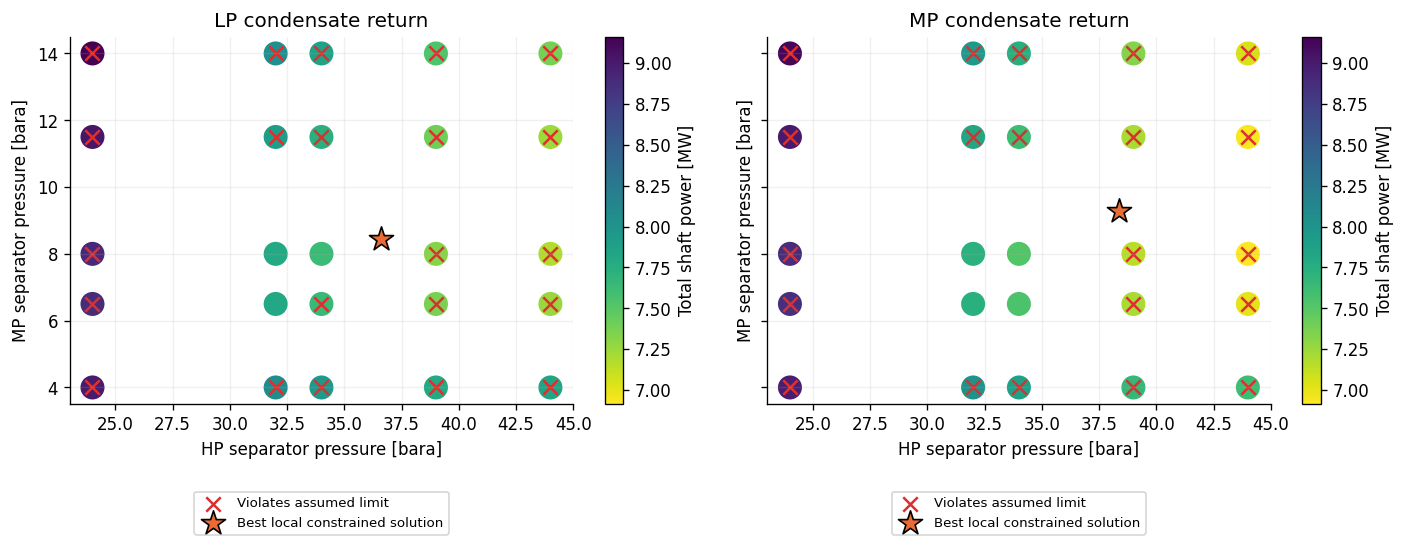

In [24]:
# Assumed equipment limits for this teaching case, not vendor curves or guarantees.
json_limits = {
    "minimum_oil_kg_s": json_base["Oil kg/s"] * 0.998,
    "driver_kW": {
        name: json_base[name] * factor
        for name, factor in zip(JSON_DRIVERS, [1.20, 1.25, 1.05, 1.03])
    },
    "cooling_kW": json_base["Cooling kW"] * 1.15,
    "heating_kW": json_base["Heating kW"] * 1.15,
    "maximum_discharge_C": 220.0,
}
json_base_spec["metadata"]["optimization"]["limits"] = json_limits
json_cache = {}


def json_evaluate_at(route, pressures):
    key = (route, *np.round(pressures, 7))
    if key not in json_cache:
        spec = set_json_pressures(make_stabilization_json(route), pressures)
        json_cache[key] = evaluate_json_process(spec)
    return json_cache[key]


def json_constraint_margins(result):
    margins = {
        "Oil recovery": result["Oil kg/s"] / json_limits["minimum_oil_kg_s"] - 1,
        "Cooling": 1 - result["Cooling kW"] / json_limits["cooling_kW"],
        "Heating": 1 - result["Heating kW"] / json_limits["heating_kW"],
        "Discharge temperature": 1 - result["Maximum discharge C"] / 220.0,
    }
    for driver, limit in json_limits["driver_kW"].items():
        margins[driver] = 1 - result[driver] / limit
    return margins


def json_feasible(result, tolerance=1e-7):
    return min(json_constraint_margins(result).values()) >= -tolerance


json_bounds = [v["bounds"] for v in json_base_spec["metadata"]["optimization"]["variables"]]
check("JSON baseline feasible", json_feasible(json_base), json_constraint_margins(json_base))
json_scan_rows = []
for json_route in ("LP", "MP"):
    for json_hp in [24.0, 32.0, 34.0, 39.0, 44.0]:
        for json_mp in [4.0, 6.5, 8.0, 11.5, 14.0]:
            json_result = json_evaluate_at(json_route, [json_hp, json_mp])
            json_scan_rows.append(
                {
                    "Return": json_route,
                    "HP bara": json_hp,
                    "MP bara": json_mp,
                    **json_result,
                    "Feasible": json_feasible(json_result),
                }
            )
json_scan = pd.DataFrame(json_scan_rows)
json_opt_rows = []
json_solver_rows = []
for json_route in ("LP", "MP"):
    json_candidates = json_scan[(json_scan.Return == json_route) & json_scan.Feasible]
    if json_candidates.empty:
        raise RuntimeError(f"No feasible starting point for {json_route}.")
    json_seed = json_candidates.loc[
        json_candidates["Power kW"].idxmin(), ["HP bara", "MP bara"]
    ].to_numpy(dtype=float)
    json_solutions = []
    for json_start in ([32.0, 8.0], json_seed):
        json_solution = minimize(
            lambda p: json_evaluate_at(json_route, p)["Power kW"] / 1000,
            json_start,
            method="SLSQP",
            bounds=json_bounds,
            constraints={
                "type": "ineq",
                "fun": lambda p: np.array(
                    list(json_constraint_margins(json_evaluate_at(json_route, p)).values())
                ),
            },
            options={"maxiter": 45, "ftol": 1e-9, "eps": 1e-3},
        )
        json_solver_rows.append(
            {
                "Return": json_route,
                "Success": bool(json_solution.success),
                "Message": str(json_solution.message),
                "Evaluations": int(json_solution.nfev),
            }
        )
        json_candidate = json_evaluate_at(json_route, json_solution.x)
        if json_solution.success and json_feasible(json_candidate):
            json_solutions.append((json_solution.x, json_candidate))
    if not json_solutions:
        raise RuntimeError(f"No converged feasible optimizer for {json_route}.")
    json_best_p, json_best_r = min(json_solutions, key=lambda item: item[1]["Power kW"])
    json_opt_rows.append(
        {"Return": json_route, "HP bara": json_best_p[0], "MP bara": json_best_p[1], **json_best_r}
    )
json_optimized_routes = pd.DataFrame(json_opt_rows).sort_values("Power kW").reset_index(drop=True)
json_winner = json_optimized_routes.iloc[0]
json_best_pressures = json_winner[["HP bara", "MP bara"]].to_numpy(dtype=float)
json_optimized_spec = set_json_pressures(
    make_stabilization_json(json_winner.Return), json_best_pressures
)
json_optimized_spec["metadata"]["optimization"]["limits"] = copy.deepcopy(json_limits)
json_replay = evaluate_json_process(json.loads(json.dumps(json_optimized_spec)))
json_saving = json_base["Power kW"] - json_replay["Power kW"]
check(
    "JSON optimized solution feasible",
    json_feasible(json_replay),
    json_constraint_margins(json_replay),
)
check("JSON optimization improves baseline", json_saving > 0, f"{json_saving:.3f} kW")
check(
    "Optimized JSON round-trip replay",
    abs(json_replay["Power kW"] - json_winner["Power kW"]) < 1e-6,
    "Fresh native process reconstructed from serialized winning input JSON",
)
display(
    json_optimized_routes[
        [
            "Return",
            "HP bara",
            "MP bara",
            "Power kW",
            "Oil kg/s",
            "Cooling kW",
            "Heating kW",
            "Maximum discharge C",
        ]
    ].round(4)
)
display(pd.DataFrame(json_solver_rows))
display(pd.Series(json_constraint_margins(json_replay), name="Fractional constraint margin"))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True, sharey=True)
json_vmin, json_vmax = json_scan["Power kW"].agg(["min", "max"]) / 1000
for ax, json_route in zip(axes, ("LP", "MP")):
    json_subset = json_scan[json_scan.Return == json_route]
    json_scatter = ax.scatter(
        json_subset["HP bara"],
        json_subset["MP bara"],
        c=json_subset["Power kW"] / 1000,
        s=180,
        cmap="viridis_r",
        vmin=json_vmin,
        vmax=json_vmax,
    )
    json_bad = json_subset[~json_subset.Feasible]
    ax.scatter(
        json_bad["HP bara"],
        json_bad["MP bara"],
        marker="x",
        c="#dc3030",
        s=75,
        label="Violates assumed limit",
    )
    json_opt = json_optimized_routes[json_optimized_routes.Return == json_route].iloc[0]
    ax.scatter(
        json_opt["HP bara"],
        json_opt["MP bara"],
        marker="*",
        c="#ec6b35",
        s=230,
        edgecolors="black",
        label="Best local constrained solution",
    )
    ax.set(
        title=f"{json_route} condensate return",
        xlabel="HP separator pressure [bara]",
        ylabel="MP separator pressure [bara]",
    )
    ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.22))
    fig.colorbar(json_scatter, ax=ax, label="Total shaft power [MW]")
finish(fig, "16_json_routing_optimization")
print(
    f"Fresh NeqSim evaluations: {len(json_cache)}; saving: {json_saving:.2f} kW "
    f"({100 * json_saving / json_base['Power kW']:.2f}%)"
)

## 12. Project the optimized graph into a connected TSA dynamic case

Material connections and signal connections have different meanings. A separator has several material ports, while a TSA `UnitModel` has one scalar output. Copying the material edges directly into TSA would not reproduce the thermodynamic process or its recycle.

Instead, graph reachability identifies which declared pressure changes can affect each output. Central finite differences of the **complete converged NeqSim process** quantify local power and oil-recovery sensitivities. Those derivatives already include the physical recycle response; we must not add another recycle coupling to the reduced model. A halved differentiation step checks numerical stability.

We generate one connected `PlantSimulator` with two pressure actuators, four shaft-power responses, an oil-rate response and a total-power sum. Pressure gains come from NeqSim; actuator time constants (10 s) and response time constants (30–90 s) are explicitly assumed. They must be identified from qualified historian or native transient data for plant use.

The step and 90 s ramp move only 5% of the distance from the optimized pressures back toward the nominal pressures, inside the operating bounds. This keeps the example local. Final predictions are compared with a fresh nonlinear NeqSim evaluation. Derivative probes may lie just beyond an active equipment limit: they estimate a local slope and are not proposed operating points. The dynamic screening checks driver utilization and oil response; it does not model vessel inventories, pressure waves, surge or a fully coupled utility system.

Exported native process input JSON, material connections, TSA projection and trajectories.


,HP derivative / bara,MP derivative / bara
LP compressor,1.79432,104.08186
MP compressor,71.07170,-90.40531
Export compressor,-140.17641,0.71383
Oil pump,0.09488,-0.15586
Oil kg/s,0.02436,-0.03730


,Scenario,Power error kW,Oil error kg/s,Peak driver utilization,Minimum oil kg/s
0,Step,0.305313,0.000069,1.0,90.822943
1,90 s ramp,0.305313,0.000069,1.0,90.822943


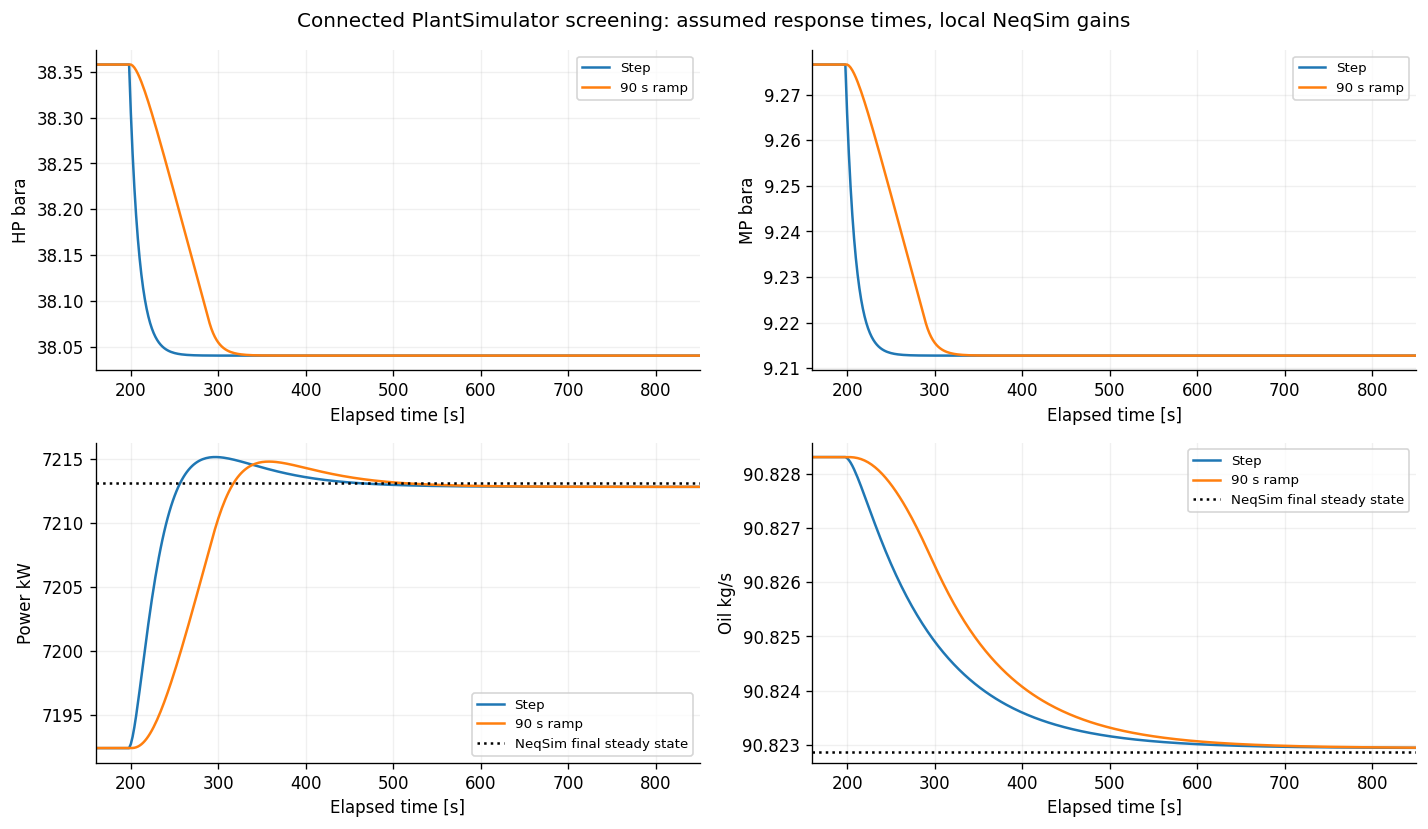

In [25]:
json_projection_outputs = [*JSON_DRIVERS, "Oil kg/s"]
json_projection_equipment = [*JSON_DRIVERS, "Oil pump"]
json_selected_graph = process_graph(json_optimized_spec)
json_variable_defs = json_optimized_spec["metadata"]["optimization"]["variables"]
json_influence = np.zeros((len(json_projection_outputs), 2), dtype=bool)
for column, variable in enumerate(json_variable_defs):
    possible = set()
    for equipment, _ in variable["targets"]:
        possible |= {equipment} | nx.descendants(json_selected_graph, equipment)
    json_influence[:, column] = [equipment in possible for equipment in json_projection_equipment]


def json_local_jacobian(step_bara):
    jacobian = np.zeros((len(json_projection_outputs), 2))
    for column in range(2):
        delta = np.eye(2)[column] * step_bara
        # Central differences are derivative probes, not operating recommendations.
        plus = json_evaluate_at(json_winner.Return, json_best_pressures + delta)
        minus = json_evaluate_at(json_winner.Return, json_best_pressures - delta)
        jacobian[:, column] = [
            (plus[name] - minus[name]) / (2 * step_bara) for name in json_projection_outputs
        ]
    return jacobian


json_jacobian = json_local_jacobian(0.05)
json_jacobian_half = json_local_jacobian(0.025)
json_derivative_error = np.max(
    abs(json_jacobian - json_jacobian_half) / np.maximum(abs(json_jacobian_half), 1e-3)
)
check("JSON sensitivity step convergence", json_derivative_error < 0.03, json_derivative_error)
check(
    "Graph influence mask",
    np.all(abs(json_jacobian[~json_influence]) < 1e-5),
    "Reachability permits influence; finite differences quantify it",
)
json_jacobian = json_jacobian_half
json_jacobian_table = pd.DataFrame(
    json_jacobian,
    index=json_projection_outputs,
    columns=["HP derivative / bara", "MP derivative / bara"],
)
display(json_jacobian_table.round(5))


def json_build_dynamic_plant():
    actuators = [unit_model(f"json_pressure_{i}", [1.0], tau=10.0) for i in range(2)]
    responses = []
    definitions = []
    for row, (output, equipment) in enumerate(
        zip(json_projection_outputs, json_projection_equipment)
    ):
        indices = np.flatnonzero(json_influence[row]).tolist()
        tau = json_optimized_spec["metadata"]["time_series"]["assumed_tau_s"][equipment]
        response = unit_model(
            f"json_response_{row}",
            json_jacobian[row, indices],
            bias=json_replay[output],
            tau=tau,
            reference=json_best_pressures[indices],
        )
        responses.append(response)
        definitions.append(
            {
                "output": output,
                "equipment": equipment,
                "pressure_inputs": indices,
                "linear_gains": json_jacobian[row, indices].tolist(),
                "reference_bara": json_best_pressures[indices].tolist(),
                "bias": json_replay[output],
                "assumed_tau_s": tau,
            }
        )
    total = unit_model("json_total_power", np.ones(len(JSON_DRIVERS)))
    models = [*actuators, *responses, total]
    plant = bridge.plant(models, "JSON stabilization local dynamics")
    signals = [
        str(plant.AddExternalSignal(model, SignalType.External_U, 0)) for model in actuators
    ]
    for response, definition in zip(responses, definitions):
        for input_index, pressure_index in enumerate(definition["pressure_inputs"]):
            assert plant.ConnectModels(actuators[pressure_index], response, input_index)
    for index, response in enumerate(responses[: len(JSON_DRIVERS)]):
        assert plant.ConnectModels(response, total, index)
    output_ids = [str(model.GetOutputID()) for model in models]
    return plant, signals, output_ids, definitions


# A small excursion toward the nominal pressures stays inside the optimization bounds.
json_target_pressures = json_best_pressures + 0.05 * (np.array([32.0, 8.0]) - json_best_pressures)
json_target_truth = json_evaluate_at(json_winner.Return, json_target_pressures)
json_dt = json_optimized_spec["metadata"]["time_series"]["sample_interval_s"]
json_time = np.arange(0.0, 1600.0 + json_dt, json_dt)
json_dynamic_results = {}
json_dynamic_rows = []
for json_scenario, json_ramp_seconds in [("Step", 0.0), ("90 s ramp", 90.0)]:
    json_plant, json_signal_ids, json_output_ids, json_model_definitions = (
        json_build_dynamic_plant()
    )
    json_fraction = (
        (json_time >= 200).astype(float)
        if json_ramp_seconds == 0
        else np.clip((json_time - 200) / json_ramp_seconds, 0, 1)
    )
    json_commands = json_best_pressures + json_fraction[:, None] * (
        json_target_pressures - json_best_pressures
    )
    json_frame = pd.DataFrame(json_commands, columns=json_signal_ids, index=json_time)
    json_simulated = bridge.simulate(json_plant, json_frame, json_dt, json_output_ids)
    json_simulated.columns = ["HP bara", "MP bara", *json_projection_outputs, "Power kW"]
    json_dynamic_results[json_scenario] = json_simulated
    json_power_error = abs(json_simulated["Power kW"].iloc[-1] - json_target_truth["Power kW"])
    json_oil_error = abs(json_simulated["Oil kg/s"].iloc[-1] - json_target_truth["Oil kg/s"])
    check(
        f"{json_scenario} local power replay",
        json_power_error / json_target_truth["Power kW"] < 0.005,
        f"Final error {json_power_error:.4f} kW versus fresh NeqSim",
    )
    check(
        f"{json_scenario} local oil replay",
        json_oil_error / json_target_truth["Oil kg/s"] < 0.001,
        f"Final error {json_oil_error:.6f} kg/s versus fresh NeqSim",
    )
    json_dynamic_rows.append(
        {
            "Scenario": json_scenario,
            "Power error kW": json_power_error,
            "Oil error kg/s": json_oil_error,
            "Peak driver utilization": max(
                json_simulated[name].max() / limit
                for name, limit in json_limits["driver_kW"].items()
            ),
            "Minimum oil kg/s": json_simulated["Oil kg/s"].min(),
        }
    )
json_dynamic_summary = pd.DataFrame(json_dynamic_rows)
check(
    "Connected JSON projection size",
    len(json_output_ids) == 8,
    "Two actuators, five physical responses, total power; one PlantSimulator",
)
check(
    "JSON dynamic operating limits",
    bool(
        (json_dynamic_summary["Peak driver utilization"] <= 1 + 1e-7).all()
        and (json_dynamic_summary["Minimum oil kg/s"] >= json_limits["minimum_oil_kg_s"]).all()
    ),
    "Step and ramp: all driver capacities and oil-recovery floor respected",
)
display(json_dynamic_summary.round(6))
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for json_scenario, json_simulated in json_dynamic_results.items():
    for ax, column in zip(axes.flat, ["HP bara", "MP bara", "Power kW", "Oil kg/s"]):
        ax.plot(json_time, json_simulated[column], label=json_scenario)
        ax.set(xlabel="Elapsed time [s]", ylabel=column, xlim=(160, 850))
for ax, column in zip(axes[1], ["Power kW", "Oil kg/s"]):
    ax.axhline(json_target_truth[column], color="black", ls=":", label="NeqSim final steady state")
for ax in axes.flat:
    ax.legend(fontsize=8)
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
fig.suptitle("Connected PlantSimulator screening: assumed response times, local NeqSim gains")
finish(fig, "17_json_local_dynamics")

for json_filename, json_payload in {
    "stabilization_base.json": json_base_spec,
    "stabilization_optimized.json": json_optimized_spec,
    "stabilization_tsa_projection.json": {
        "source_material_json": "stabilization_optimized.json",
        "actuator_tau_s": 10.0,
        "sample_interval_s": json_dt,
        "models": json_model_definitions,
        "step_target_bara": json_target_pressures.tolist(),
        "time_constants_status": "Assumed; not identified from the input JSON or measured data",
    },
}.items():
    (outdir / json_filename).write_text(json.dumps(json_payload, indent=2, allow_nan=False))
(outdir / "stabilization_tsa_plant.json").write_text(str(json_plant.SerializeTxt()))
for json_filename, json_table in {
    "stabilization_connections.csv": graph_connections(json_selected_graph),
    "stabilization_scan.csv": json_scan,
    "stabilization_route_optima.csv": json_optimized_routes,
    "stabilization_jacobian.csv": json_jacobian_table,
    "stabilization_dynamic_validation.csv": json_dynamic_summary,
    "stabilization_dynamic_step.csv": json_dynamic_results["Step"],
    "stabilization_dynamic_ramp.csv": json_dynamic_results["90 s ramp"],
}.items():
    json_table.to_csv(outdir / json_filename)
print("Exported native process input JSON, material connections, TSA projection and trajectories.")

### 12.1 Full-process historian: physics before identification

The preceding example projects a local NeqSim Jacobian into assumed TSA response models. Now we **identify** the responses from an independent synthetic historian and use those learned models to improve operation.

We keep the same 24-unit material process and the selected condensate route. NeqSim solves 72 independently rebuilt operating blocks across HP 36.5–38.5 bara and MP 8.5–9.5 bara. The two pressure inputs vary independently, providing information to separate their gains. Six outputs cover all four shaft powers, oil recovery and export-compressor discharge temperature. TSA `CorrelationCalculator` checks pressure-input correlation; correlation itself is not evidence of causation.

Steady-state thermodynamics does not determine a time response. To create a controlled test, each NeqSim equilibrium target drives an explicitly assumed first-order response, calculated independently with the exact exponential solution, then receives seeded measurement noise. These are **synthetic process/measurement lags**, not a native NeqSim inventory or hydraulic transient model. Their known time constants are used only to generate and assess the teaching data; the identifier sees inputs and noisy outputs. The very low noise isolates integration and model-structure error and does not claim field instrument accuracy.

$$y_k=e^{-\Delta t/\tau}y_{k-1}+(1-e^{-\Delta t/\tau})y_{ss,k}+\epsilon_k$$

Here $y_{ss,k}$ is the relevant NeqSim equilibrium output, $\tau$ is the assumed response time in seconds, $\Delta t=2$ s and $\epsilon_k$ is measurement noise. Noise is added after propagating the noise-free state. The first 44 operating blocks train the models, the next 12 calibrate their assessment, and the last 16 remain unseen test data. These are offline simulation experiments; every excitation point is thermodynamically checked, but not every point is a permitted live-plant operating condition under the assumed equipment limits.

TSA input correlation: -0.067; 72 independently computed nonlinear operating blocks


HP bara                    MP bara          
                     min        max count       min       max
Partition                                                    
Training       36.710630  38.436307  1540  8.555554  9.484809
Calibration    36.587383  38.128645   420  8.564032  9.376876
Held-out test  36.549944  38.120815   560  8.561008  9.469582

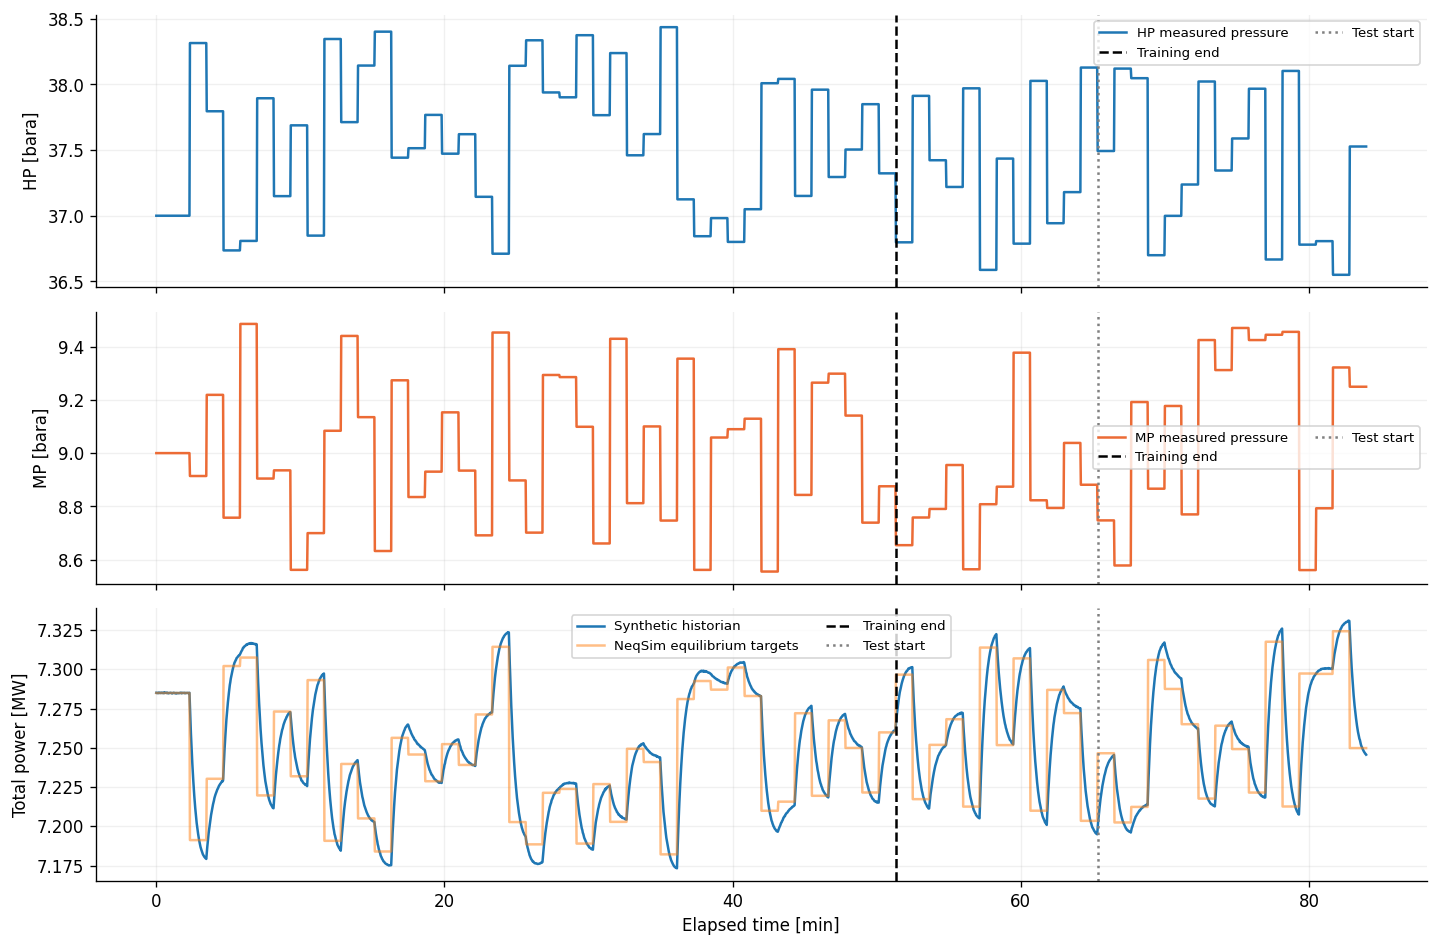

In [26]:
# This independent synthetic historian uses NeqSim steady targets and exact exponential lags.
# No TSA model is used to generate its output values.
FULL_OUTPUTS = [*JSON_DRIVERS, "Oil kg/s", "Export discharge C"]
FULL_UNITS = ["kW", "kW", "kW", "kW", "kg/s", "C"]
full_dt = 2.0
full_block_samples = 35
full_block_count = 72
full_domain = np.array([[36.5, 38.5], [8.5, 9.5]])
full_tau_assumed = np.array([45.0, 60.0, 30.0, 90.0, 90.0, 40.0])
full_noise_sd = np.array([0.08, 0.08, 0.08, 0.0003, 0.0002, 0.003])
full_rng = np.random.default_rng(260916)
full_block_pressures = full_rng.uniform(
    full_domain[:, 0], full_domain[:, 1], size=(full_block_count, 2)
)
full_block_pressures[:2] = [37.0, 9.0]
full_block_results = [
    json_evaluate_at(json_winner.Return, pressures) for pressures in full_block_pressures
]
full_block_targets = np.array(
    [[result[name] for name in FULL_OUTPUTS] for result in full_block_results]
)
full_inputs = np.repeat(full_block_pressures, full_block_samples, axis=0)
full_steady_targets = np.repeat(full_block_targets, full_block_samples, axis=0)
full_truth = np.empty_like(full_steady_targets)
full_truth[0] = full_steady_targets[0]
full_decay = np.exp(-full_dt / full_tau_assumed)
for full_sample in range(1, len(full_truth)):
    full_truth[full_sample] = (
        full_decay * full_truth[full_sample - 1]
        + (1 - full_decay) * full_steady_targets[full_sample]
    )
full_measurements = full_truth + full_rng.normal(size=full_truth.shape) * full_noise_sd
full_time = np.arange(len(full_inputs)) * full_dt
full_train_end = 44 * full_block_samples
full_cal_end = 56 * full_block_samples
full_historian = pd.DataFrame(full_measurements, columns=FULL_OUTPUTS, index=full_time)
full_historian.insert(0, "MP bara", full_inputs[:, 1])
full_historian.insert(0, "HP bara", full_inputs[:, 0])
full_historian.index.name = "Elapsed time s"
full_historian["Partition"] = np.select(
    [np.arange(len(full_time)) < full_train_end, np.arange(len(full_time)) < full_cal_end],
    ["Training", "Calibration"],
    default="Held-out test",
)
check(
    "Full-process historian qualified",
    np.isfinite(full_measurements).all(),
    "Synchronized 2 s samples; contiguous train/calibration/test blocks",
)
full_normalized_inputs = full_inputs[:full_train_end] - full_inputs[:full_train_end].mean(axis=0)
full_normalized_inputs /= full_normalized_inputs.std(axis=0)
check(
    "Full-process excitation rank",
    np.linalg.cond(full_normalized_inputs) < 2.0,
    np.linalg.cond(full_normalized_inputs),
)
full_input_correlation = float(
    CorrelationCalculator.Calculate(
        netarray(full_inputs[:full_train_end, 0]), netarray(full_inputs[:full_train_end, 1]), None
    )
)
check(
    "TSA pressure excitation correlation",
    abs(full_input_correlation) < 0.3,
    full_input_correlation,
)
display(
    full_historian.groupby("Partition", sort=False).agg(
        {"HP bara": ["min", "max", "count"], "MP bara": ["min", "max"]}
    )
)
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(full_time / 60, full_inputs[:, 0], label="HP measured pressure")
axes[0].set(ylabel="HP [bara]")
axes[1].plot(full_time / 60, full_inputs[:, 1], color=COLORS[1], label="MP measured pressure")
axes[1].set(ylabel="MP [bara]")
axes[2].plot(
    full_time / 60, full_measurements[:, :4].sum(axis=1) / 1000, label="Synthetic historian"
)
axes[2].plot(
    full_time / 60,
    full_steady_targets[:, :4].sum(axis=1) / 1000,
    alpha=0.5,
    label="NeqSim equilibrium targets",
)
axes[2].set(ylabel="Total power [MW]", xlabel="Elapsed time [min]")
for ax in axes:
    ax.axvline(full_time[full_train_end] / 60, color="black", ls="--", label="Training end")
    ax.axvline(full_time[full_cal_end] / 60, color="gray", ls=":", label="Test start")
    ax.legend(fontsize=8, ncol=2)
finish(fig, "18_full_process_historian")
print(
    f"TSA input correlation: {full_input_correlation:.3f}; "
    f"{full_block_count} independently computed nonlinear operating blocks"
)

### 12.2 TSA identifies six multivariable process responses

For each output, native `UnitIdentifier.IdentifyLinear` estimates two pressure gains, a bias and a response time. `IdentifyLinearAndStatic` provides a native static baseline on the same training samples. Time-delay estimation is disabled because the controlled generator has no transport delay; real historian studies must consider delay identification and sensor alignment.

The fitted models receive input data continuously through calibration and test without refitting or measured-output resets. Compare held-out dynamic RMSE with static RMSE and normalize it by the **training** output range. Identification warnings, gains and time constants are shown explicitly. The discrete TSA filter uses backward Euler, so its fitted time constant need not equal the generator's continuous-time constant exactly.

Interpret the fitted gains as conditional local effects: increasing HP pressure lowers export-compressor power, while increasing MP pressure raises LP-compressor power and lowers MP-compressor power. Their competing duties explain why changing one separator pressure cannot be judged from a single compressor. These empirical sensitivities are valid only for this route, composition and training domain.

The earlier graph tells us which influences are possible; the time-series experiment quantifies them. A recycle remains inside each nonlinear NeqSim solve. We do not duplicate material-recycle edges in the scalar signal graph, which would count the same physical coupling twice.

,Output,Unit,HP gain / bara,MP gain / bara,Assumed true tau s,Identified tau s,Warnings
0,LP compressor,kW,1.74770,102.31000,45.0,43.912,none
1,MP compressor,kW,70.98400,-91.56100,60.0,59.012,none
2,Export compressor,kW,-144.16000,0.57037,30.0,29.128,none
3,Oil pump,kW,0.09883,-0.15419,90.0,89.159,none
4,Oil kg/s,kg/s,0.02485,-0.03626,90.0,86.436,none
5,Export discharge C,C,-2.22320,-0.04542,40.0,39.085,none


,Output,Dynamic RMSE,Static RMSE,NRMSE / training range
1,LP compressor,0.221226,19.120845,0.003050
3,MP compressor,0.492834,28.452136,0.003434
5,Export compressor,0.666322,41.257442,0.002857
7,Oil pump,0.001568,0.045534,0.009067
9,Oil kg/s,0.000795,0.010954,0.018169
11,Export discharge C,0.006978,0.664082,0.002049


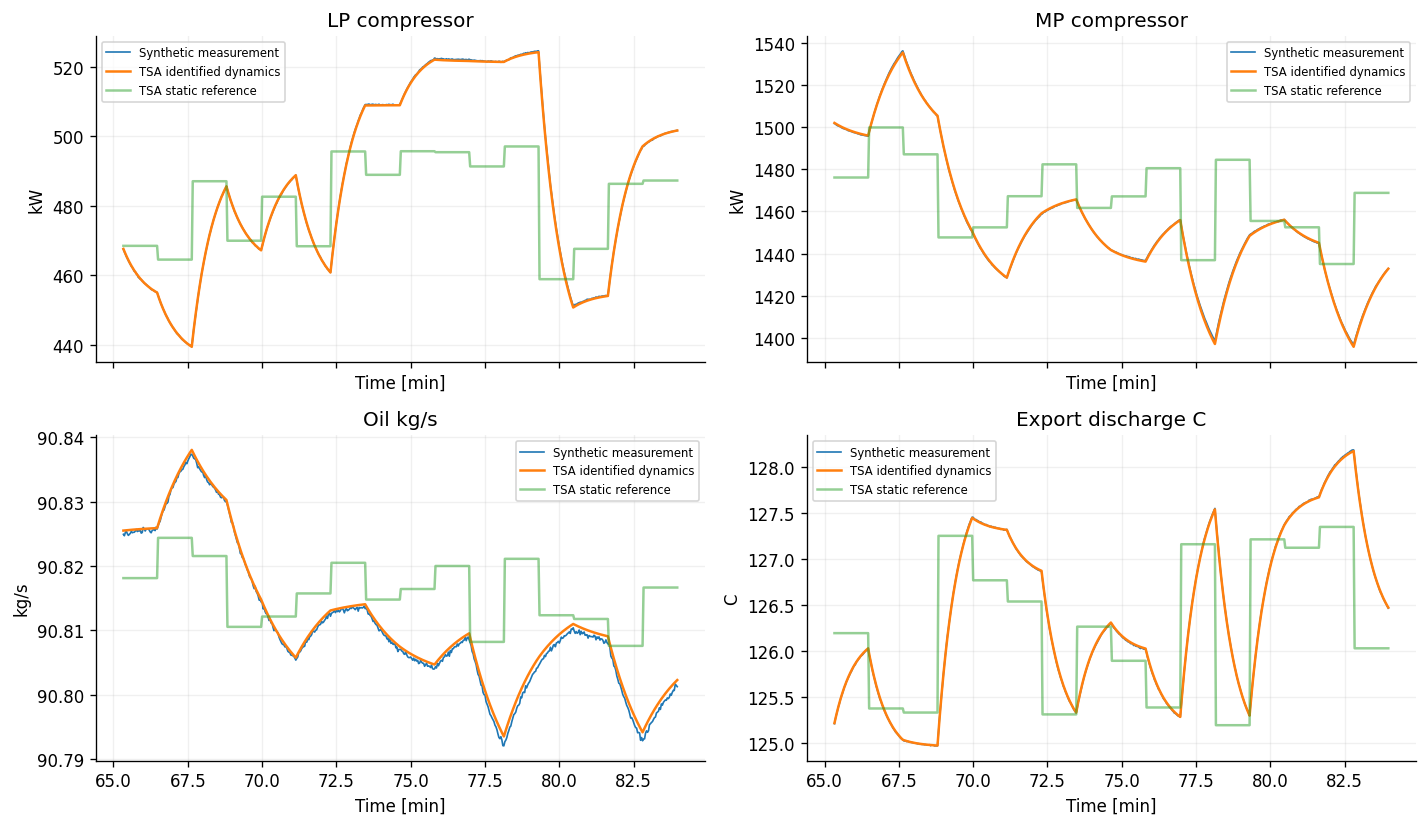

In [27]:
full_identified = {}
full_static_models = {}
full_fit_rows = []
full_parameter_rows = []
full_dynamic_predictions = np.zeros_like(full_measurements)
full_static_predictions = np.zeros_like(full_measurements)
for full_column, full_output in enumerate(FULL_OUTPUTS):
    full_training = UnitDataSet(f"Full process: {full_output}")
    full_training.SetU(
        netarray(full_inputs[:full_train_end, 0]), netarray(full_inputs[:full_train_end, 1])
    )
    full_training.Y_meas = netarray(full_measurements[:full_train_end, full_column])
    full_training.CreateTimeStamps(full_dt)
    full_model, _ = UnitIdentifier.IdentifyLinear(full_training, None, False)
    full_static, _ = UnitIdentifier.IdentifyLinearAndStatic(full_training, None, False)
    full_parameters = full_model.GetModelParameters()
    check(
        f"Full-process identification: {full_output}",
        full_parameters.Fitting.WasAbleToIdentify,
        str(full_parameters.Fitting.SolverID),
    )
    check(
        f"Full-process static fit: {full_output}",
        full_static.GetModelParameters().Fitting.WasAbleToIdentify,
        "TSA static reference fit",
    )
    full_identified[full_output] = full_model
    full_static_models[full_output] = full_static
    full_model.WarmStart()
    full_dynamic_predictions[:, full_column] = [
        full_model.Iterate(netarray(pressures), full_dt)[0] for pressures in full_inputs
    ]
    full_static_predictions[:, full_column] = [
        full_static.GetSteadyStateOutput(netarray(pressures)) for pressures in full_inputs
    ]
    full_range = float(np.ptp(full_measurements[:full_train_end, full_column]))
    for full_partition, full_slice in [
        ("Calibration", slice(full_train_end, full_cal_end)),
        ("Held-out test", slice(full_cal_end, None)),
    ]:
        full_error = (
            full_dynamic_predictions[full_slice, full_column]
            - full_measurements[full_slice, full_column]
        )
        full_static_error = (
            full_static_predictions[full_slice, full_column]
            - full_measurements[full_slice, full_column]
        )
        full_fit_rows.append(
            {
                "Output": full_output,
                "Partition": full_partition,
                "Dynamic RMSE": float(np.sqrt(np.mean(full_error**2))),
                "Static RMSE": float(np.sqrt(np.mean(full_static_error**2))),
                "NRMSE / training range": float(np.sqrt(np.mean(full_error**2)) / full_range),
            }
        )
    full_parameter_rows.append(
        {
            "Output": full_output,
            "Unit": FULL_UNITS[full_column],
            "HP gain / bara": float(full_parameters.LinearGains[0]),
            "MP gain / bara": float(full_parameters.LinearGains[1]),
            "Assumed true tau s": full_tau_assumed[full_column],
            "Identified tau s": float(full_parameters.TimeConstant_s),
            "Warnings": ", ".join(map(str, full_parameters.GetWarningList())) or "none",
        }
    )
full_fit_scores = pd.DataFrame(full_fit_rows)
full_parameter_table = pd.DataFrame(full_parameter_rows)
full_test_scores = full_fit_scores[full_fit_scores.Partition == "Held-out test"]
check(
    "Full-process held-out model error",
    full_test_scores["NRMSE / training range"].max() < 0.12,
    full_test_scores["NRMSE / training range"].max(),
)
check(
    "TSA dynamic models improve static replay",
    bool((full_test_scores["Dynamic RMSE"] < full_test_scores["Static RMSE"]).all()),
    "All six responses evaluated on unseen chronological blocks",
)
display(full_parameter_table.round(5))
display(full_test_scores.drop(columns="Partition").round(6))
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
full_test_slice = slice(full_cal_end, None)
for ax, full_column in zip(axes.flat, [0, 1, 4, 5]):
    full_plot_time = full_time[full_test_slice] / 60
    ax.plot(
        full_plot_time,
        full_measurements[full_test_slice, full_column],
        lw=1,
        label="Synthetic measurement",
    )
    ax.plot(
        full_plot_time,
        full_dynamic_predictions[full_test_slice, full_column],
        label="TSA identified dynamics",
    )
    ax.plot(
        full_plot_time,
        full_static_predictions[full_test_slice, full_column],
        alpha=0.5,
        label="TSA static reference",
    )
    ax.set(title=FULL_OUTPUTS[full_column], ylabel=FULL_UNITS[full_column], xlabel="Time [min]")
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    ax.legend(fontsize=7)
finish(fig, "19_full_process_identification")

### 12.3 A decision made with TSA and accepted by NeqSim

The current local operating point is 37/9 bara HP/MP. SciPy searches only inside the identification domain, evaluating the **identified TSA models' native `GetSteadyStateOutput`** for power and recovery. The candidate retains a nominal 2% driver-capacity allowance for model mismatch; this is not a probabilistic confidence bound.

This is how the two libraries work together: TSA supplies a cheap learned response for repeated search evaluations; NeqSim rebuilds the proposed physical process and checks all original driver, recovery, heating/cooling and discharge-temperature constraints, plus mass/energy closure. A candidate that fails native replay is rejected. The table separates the learned prediction from the accepted nonlinear result.

The stored demonstration yields a verified reduction of about 56.3 kW from the local starting point, with learned total-power prediction within about 1 kW of the nonlinear replay. The result table is recomputed on every run.

The new candidate can use slightly more power than the earlier ideal physical optimum because it includes a driver backoff. Its improvement is measured against the stated **current local point**; do not add that saving to the earlier baseline-to-optimum saving.

In [28]:
def full_tsa_equilibrium(pressures):
    """Ask the identified TSA models for their equilibrium outputs."""
    result = {
        name: float(model.GetSteadyStateOutput(netarray(pressures)))
        for name, model in full_identified.items()
    }
    result["Power kW"] = sum(result[name] for name in JSON_DRIVERS)
    return result


full_start_pressure = np.array([37.0, 9.0])
full_start_truth = json_evaluate_at(json_winner.Return, full_start_pressure)
full_capacity_fraction = 0.98


def full_tsa_constraints(pressures):
    predicted = full_tsa_equilibrium(pressures)
    return np.array(
        [
            *(
                full_capacity_fraction - predicted[name] / limit
                for name, limit in json_limits["driver_kW"].items()
            ),
            predicted["Oil kg/s"] / json_limits["minimum_oil_kg_s"] - 1,
        ]
    )


full_search = minimize(
    lambda p: full_tsa_equilibrium(p)["Power kW"] / 1000,
    full_start_pressure,
    method="SLSQP",
    bounds=full_domain.tolist(),
    constraints={"type": "ineq", "fun": full_tsa_constraints},
    options={"ftol": 1e-10, "maxiter": 60},
)
check("TSA-assisted setpoint search converged", full_search.success, full_search.message)
full_candidate_pressure = np.asarray(full_search.x)
full_candidate_prediction = full_tsa_equilibrium(full_candidate_pressure)
# Acceptance always includes fresh nonlinear NeqSim utility/temperature/recovery checks.
full_candidate_spec = set_json_pressures(
    make_stabilization_json(json_winner.Return), full_candidate_pressure
)
full_candidate_truth = evaluate_json_process(full_candidate_spec)
check(
    "TSA proposal passes full NeqSim replay",
    json_feasible(full_candidate_truth),
    json_constraint_margins(full_candidate_truth),
)
check(
    "TSA proposal saves real process power",
    full_candidate_truth["Power kW"] < full_start_truth["Power kW"],
    full_start_truth["Power kW"] - full_candidate_truth["Power kW"],
)
full_decision_table = pd.DataFrame(
    {
        "Current local point: NeqSim": {
            "HP bara": full_start_pressure[0],
            "MP bara": full_start_pressure[1],
            **full_start_truth,
        },
        "TSA candidate prediction": {
            "HP bara": full_candidate_pressure[0],
            "MP bara": full_candidate_pressure[1],
            **full_candidate_prediction,
        },
        "Accepted candidate: NeqSim": {
            "HP bara": full_candidate_pressure[0],
            "MP bara": full_candidate_pressure[1],
            **full_candidate_truth,
        },
    }
).loc[["HP bara", "MP bara", *JSON_DRIVERS, "Power kW", "Oil kg/s"]]
display(full_decision_table.round(4))
print(
    f"Additional local reduction verified in NeqSim: "
    f"{full_start_truth['Power kW'] - full_candidate_truth['Power kW']:.3f} kW"
)
print("The 2% driver backoff is an engineering allowance, not a statistical confidence bound.")

Additional local reduction verified in NeqSim: 56.299 kW
The 2% driver backoff is an engineering allowance, not a statistical confidence bound.


,Current local point: NeqSim,TSA candidate prediction,Accepted candidate: NeqSim
HP bara,37.0000,37.8131,37.8131
MP bara,9.0000,9.1886,9.1886
LP compressor,476.4022,497.2350,497.2652
MP compressor,1434.4850,1475.4250,1474.8725
Export compressor,5036.6793,4919.5379,4919.0781
Oil pump,337.3339,337.3849,337.3858
Power kW,7284.9003,7229.5829,7228.6015
Oil kg/s,90.8043,90.8182,90.8181


### 12.4 Native PlantSimulator executes the full-process control case

The learned responses now run together in **one 11-model TSA plant**: two `PidModel` controllers, two pressure-actuator responses, six identified output responses and one total-power model. Both pressure signals connect to each identified response; four power outputs connect to the sum. Controller feedback is executed inside `PlantSimulator`, including native engineering-unit output limits. Python supplies setpoints and converts arrays; it does not implement the feedback time step or clip actuator outputs.

Compare PI response settings of 20 and 60 s. The actuator response time of 10 s is still an explicit assumption; the six process-response times are learned from the historian. Consistent initial PID outputs seed the native initializer as in the earlier six-loop case. We check tracking, driver/recovery limits, and serialization replay. Final oil and power are also compared visually with the independent NeqSim accepted state; small offsets expose reduced-model error.

These loops control an idealized pressure response. Real valve characteristics, vessel inventory, recycle stability, surge and utility feedback require separate qualification. Passing this screening does not certify an operating move.

,PI lambda s,HP IAE bara s,MP IAE bara s,Peak driver utilization,Final total power kW
0,20.0,16.26112,3.7713,0.98,7229.58292
1,60.0,48.78336,11.3139,0.98,7229.58292


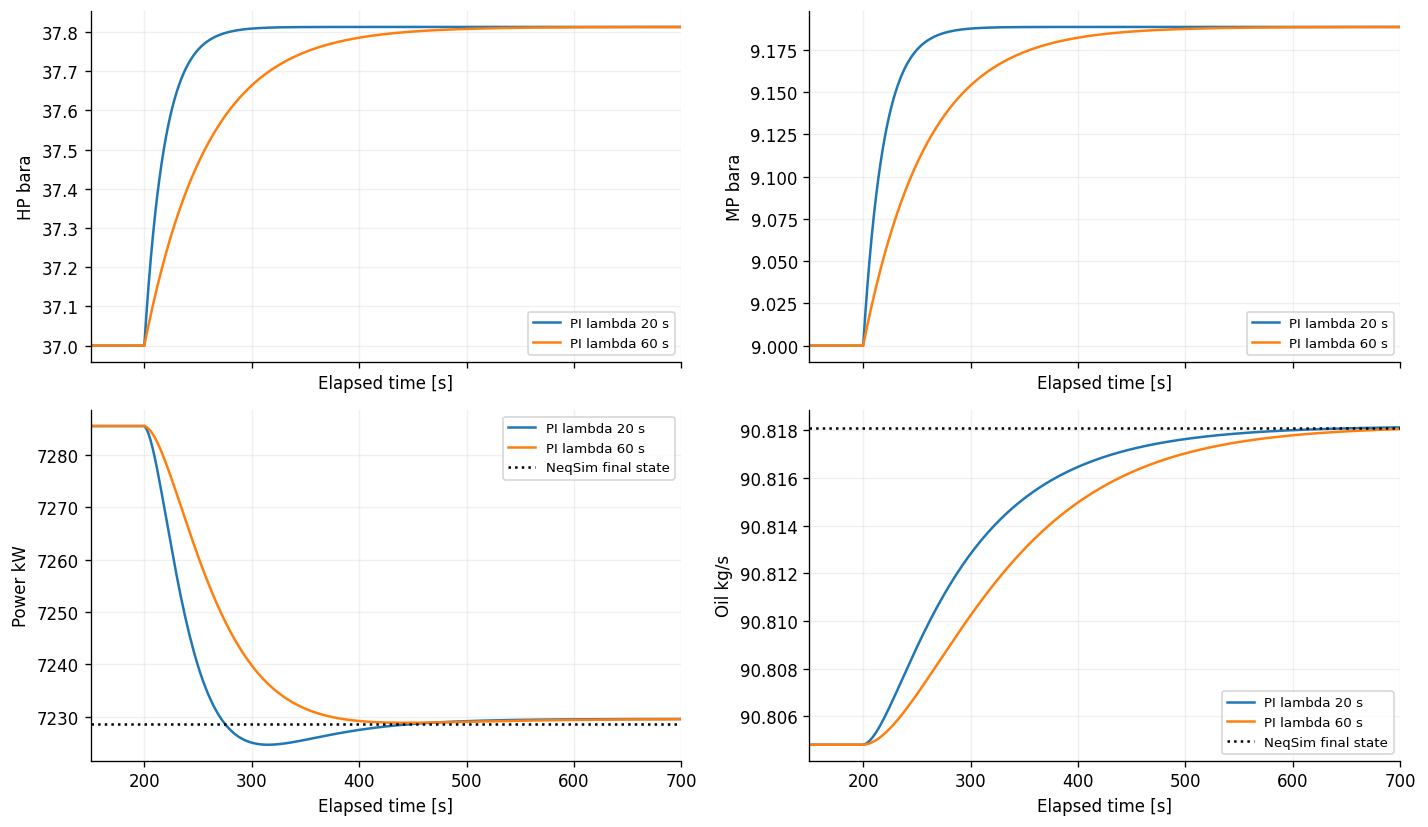

In [29]:
def build_full_tsa_plant(pressure_setpoints, controller_lambda_s=20.0):
    """Two native PID pressure loops drive six learned process responses and their power sum."""
    actuators = [unit_model(f"full_pressure_{i}", [1.0], tau=10.0) for i in range(2)]
    controllers = []
    for index in range(2):
        parameters = PidParameters()
        parameters.Kp = 10.0 / controller_lambda_s
        parameters.Ti_s = 10.0
        parameters.u0 = float(pressure_setpoints[0, index])
        parameters.Scaling.Set(
            0.0, 100.0, float(full_domain[index, 0]), float(full_domain[index, 1]), False
        )
        controllers.append(PidModel(parameters, f"full_pid_{index}"))
    responses = []
    for index, name in enumerate(FULL_OUTPUTS):
        parameters = full_identified[name].GetModelParameters()
        responses.append(
            unit_model(
                f"full_response_{index}",
                list(parameters.LinearGains),
                float(parameters.Bias),
                float(parameters.TimeConstant_s),
                list(parameters.U0),
            )
        )
    total = unit_model("full_total_power", np.ones(4))
    models = [*controllers, *actuators, *responses, total]
    plant = bridge.plant(models, "Full stabilization: learned responses and pressure control")
    frame = pd.DataFrame(index=np.arange(len(pressure_setpoints)) * full_dt)
    for index, (actuator, controller) in enumerate(zip(actuators, controllers)):
        assert plant.ConnectModels(actuator, controller)
        assert plant.ConnectModels(controller, actuator, 0)
        signal = plant.AddExternalSignal(controller, SignalType.Setpoint_Yset, 0)
        frame[str(signal)] = pressure_setpoints[:, index]
        frame[str(controller.GetOutputID())] = float(pressure_setpoints[0, index])
    for response in responses:
        for index, actuator in enumerate(actuators):
            assert plant.ConnectModels(actuator, response, index)
    for index, response in enumerate(responses[:4]):
        assert plant.ConnectModels(response, total, index)
    output_ids = [str(model.GetOutputID()) for model in models]
    output_names = [
        "HP command bara",
        "MP command bara",
        "HP bara",
        "MP bara",
        *FULL_OUTPUTS,
        "Power kW",
    ]
    return plant, frame, dict(zip(output_ids, output_names))


full_control_time = np.arange(0.0, 1600.0 + full_dt, full_dt)
full_control_setpoints = np.tile(full_start_pressure, (len(full_control_time), 1))
full_control_setpoints[full_control_time >= 200] = full_candidate_pressure
full_control_runs = {}
full_control_rows = []
for full_lambda in (20.0, 60.0):
    full_control_plant, full_control_frame, full_output_map = build_full_tsa_plant(
        full_control_setpoints, full_lambda
    )
    full_control_result = bridge.simulate(
        full_control_plant, full_control_frame, full_dt, full_output_map
    ).rename(columns=full_output_map)
    full_control_runs[full_lambda] = full_control_result
    full_pressure_errors = (
        full_control_result[["HP bara", "MP bara"]].to_numpy() - full_control_setpoints
    )
    full_utilization = max(
        full_control_result[name].max() / limit for name, limit in json_limits["driver_kW"].items()
    )
    check(
        f"Full plant PI {full_lambda:g}: pressure tracking",
        abs(full_pressure_errors[-1]).max() < 1e-4,
        full_pressure_errors[-1],
    )
    check(
        f"Full plant PI {full_lambda:g}: driver/recovery limits",
        full_utilization <= 1.0
        and full_control_result["Oil kg/s"].min() >= json_limits["minimum_oil_kg_s"],
        f"Peak utilization {full_utilization:.6f}",
    )
    full_commands = full_control_result[["HP command bara", "MP command bara"]].to_numpy()
    check(
        f"Full plant PI {full_lambda:g}: native actuator limits",
        bool(
            (full_commands >= full_domain[:, 0] - 1e-8).all()
            and (full_commands <= full_domain[:, 1] + 1e-8).all()
        ),
        "No Python clipping",
    )
    full_control_rows.append(
        {
            "PI lambda s": full_lambda,
            "HP IAE bara s": np.abs(full_pressure_errors[:, 0]).sum() * full_dt,
            "MP IAE bara s": np.abs(full_pressure_errors[:, 1]).sum() * full_dt,
            "Peak driver utilization": full_utilization,
            "Final total power kW": full_control_result["Power kW"].iloc[-1],
        }
    )
full_control_summary = pd.DataFrame(full_control_rows)
check(
    "Full-process connected model count",
    len(full_output_map) == 11,
    "2 PidModels + 2 pressure responses + 6 identified responses + power sum",
)
# Repeat on the serialized graph, proving a reusable TSA handoff.
full_restored = PlantSimulatorSerializer.LoadFromJsonTxt(str(full_control_plant.SerializeTxt()))
full_roundtrip = bridge.simulate(
    full_restored, full_control_frame, full_dt, full_output_map
).rename(columns=full_output_map)
check(
    "Full-process learned plant JSON replay",
    np.allclose(full_roundtrip.to_numpy(), full_control_runs[60.0].to_numpy(), atol=1e-8, rtol=0),
    float(np.max(abs(full_roundtrip.to_numpy() - full_control_runs[60.0].to_numpy()))),
)
display(full_control_summary.round(5))
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for full_lambda, full_result in full_control_runs.items():
    for ax, column in zip(axes.flat, ["HP bara", "MP bara", "Power kW", "Oil kg/s"]):
        ax.plot(full_control_time, full_result[column], label=f"PI lambda {full_lambda:g} s")
        ax.set(ylabel=column, xlabel="Elapsed time [s]", xlim=(150, 700))
        ax.ticklabel_format(axis="y", style="plain", useOffset=False)
for ax, column in zip(axes[1], ["Power kW", "Oil kg/s"]):
    ax.axhline(full_candidate_truth[column], color="black", ls=":", label="NeqSim final state")
for ax in axes.flat:
    ax.legend(fontsize=8)
finish(fig, "20_full_process_native_pid")

### 12.5 Shared diagnosis: TSA residuals plus NeqSim physical evidence

At the accepted point, rebuild the full NeqSim process with export-compressor efficiency reduced from 0.78 to 0.74. This supplies a physically consistent power/temperature change. A later scenario introduces only a 120 kW power-meter bias. The same explicitly assumed lags generate the synthetic observed trajectories.

The learned TSA plant supplies the healthy prediction. A separate healthy interval calibrates residual bias and thresholds; native TSA `LowPass` filters each residual causally. Concurrent power and temperature deviations support a physical-degradation hypothesis. A power-only deviation supports a meter/model hypothesis. Checks assess later, predetermined stable intervals, without feeding scenario labels to the classifier. Composition changes, cooling changes and sensor bias can still confound diagnosis on a real plant.

The exports provide both sides of the handoff: accepted **NeqSim process input JSON**, serialized **TSA learned control plant JSON**, the tag order/units/domain contract, historian partitions, identification results, controller trajectories and diagnostic evidence. A production workflow would replace the synthetic historian with qualified plant data, retain chronological validation, and rerun NeqSim acceptance whenever composition, topology or equipment condition changes.

Saved the learned TSA plant, accepted NeqSim input, historian, validation and integration contract.


,Scenario,Export power kW,Export discharge C,Interpretation
0,NeqSim healthy,4919.0781,125.4738,Within baseline
1,NeqSim efficiency 0.74,5184.9742,128.6529,Physical degradation candidate
2,Sensor bias only,5039.0781,125.4738,Power meter/model candidate


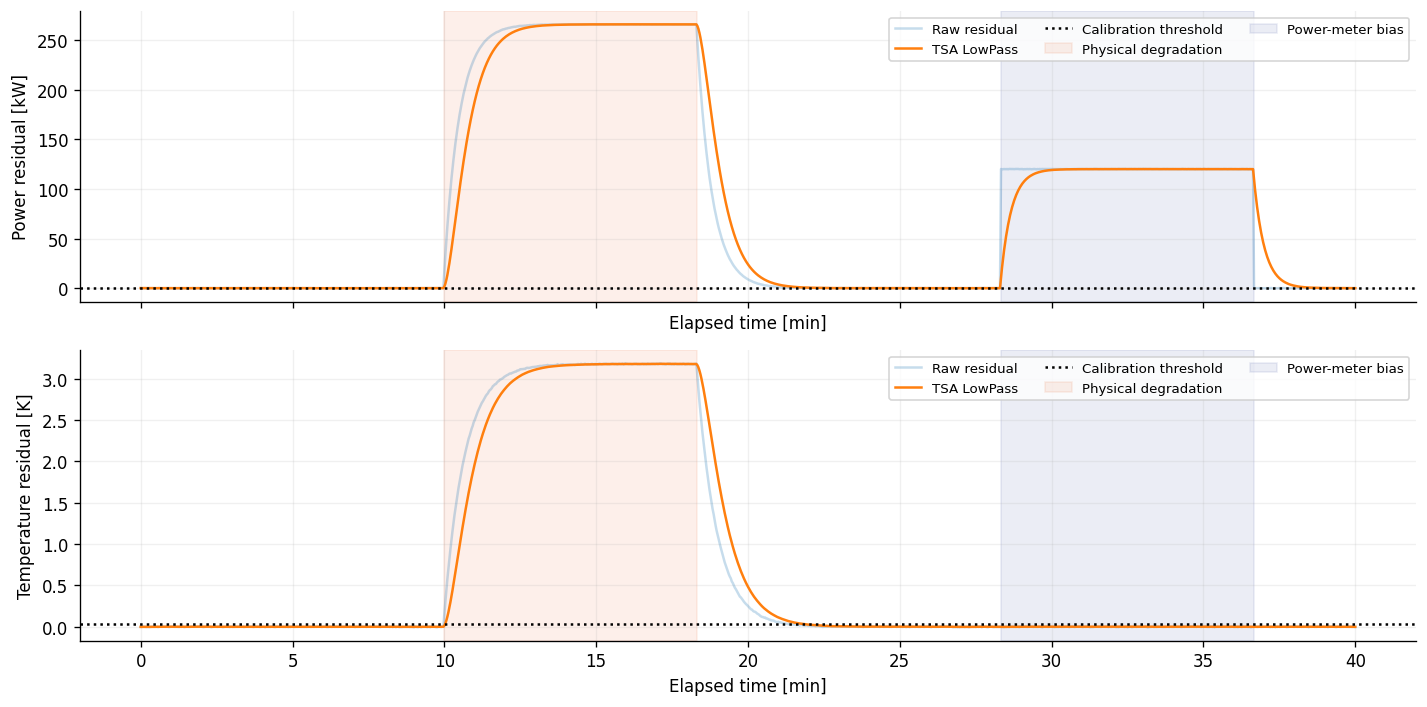

In [30]:
full_fault_spec = copy.deepcopy(full_candidate_spec)
for full_unit in full_fault_spec["process"]:
    if full_unit["name"] == "Export compressor":
        full_unit["properties"]["isentropicEfficiency"] = 0.74
full_fault_truth = evaluate_json_process(full_fault_spec)
full_fault_time = np.arange(0.0, 2400.0 + full_dt, full_dt)
full_fault_targets = np.tile(
    [full_candidate_truth[name] for name in FULL_OUTPUTS], (len(full_fault_time), 1)
)
full_physical_event = (full_fault_time >= 600) & (full_fault_time < 1100)
full_fault_targets[full_physical_event] = [full_fault_truth[name] for name in FULL_OUTPUTS]
full_fault_observations = np.empty_like(full_fault_targets)
full_fault_observations[0] = full_fault_targets[0]
for full_sample in range(1, len(full_fault_time)):
    full_fault_observations[full_sample] = (
        full_decay * full_fault_observations[full_sample - 1]
        + (1 - full_decay) * full_fault_targets[full_sample]
    )
full_fault_observations += full_rng.normal(size=full_fault_observations.shape) * full_noise_sd
full_meter_event = (full_fault_time >= 1700) & (full_fault_time < 2200)
full_fault_observations[full_meter_event, 2] += 120.0
full_monitor_plant, full_monitor_frame, full_monitor_map = build_full_tsa_plant(
    np.tile(full_candidate_pressure, (len(full_fault_time), 1))
)
full_monitor_prediction = bridge.simulate(
    full_monitor_plant, full_monitor_frame, full_dt, full_monitor_map
).rename(columns=full_monitor_map)
full_raw_residual = (
    full_fault_observations[:, [2, 5]]
    - full_monitor_prediction[["Export compressor", "Export discharge C"]].to_numpy()
)
full_calibration_mask = full_fault_time < 200
full_residual_bias = np.mean(full_raw_residual[full_calibration_mask], axis=0)
full_centered_residual = full_raw_residual - full_residual_bias
full_filters = [LowPass(full_dt), LowPass(full_dt)]
full_filtered_residual = np.array(
    [
        [float(full_filters[column].Filter(float(row[column]), 20.0)) for column in range(2)]
        for row in full_centered_residual
    ]
)
full_alarm_threshold = np.maximum(
    np.max(abs(full_filtered_residual[full_calibration_mask]), axis=0) * 3, [0.5, 0.03]
)
full_power_flag = full_filtered_residual[:, 0] > full_alarm_threshold[0]
full_temp_flag = full_filtered_residual[:, 1] > full_alarm_threshold[1]
full_diagnosis = np.select(
    [full_power_flag & full_temp_flag, full_power_flag & ~full_temp_flag],
    ["Physical degradation candidate", "Power meter/model candidate"],
    default="Within baseline",
)
full_healthy_eval = (full_fault_time >= 200) & (full_fault_time < 600)
full_physical_eval = (full_fault_time >= 800) & (full_fault_time < 1000)
full_meter_eval = (full_fault_time >= 1900) & (full_fault_time < 2100)
check(
    "Full-process healthy diagnostic interval",
    not np.any(full_power_flag[full_healthy_eval] | full_temp_flag[full_healthy_eval]),
    "Calibration ends before diagnostic evaluation",
)
check(
    "Full-process physical fault evidence",
    bool(np.all(full_diagnosis[full_physical_eval] == "Physical degradation candidate")),
    "Fresh full-process NeqSim efficiency reduction raises power and discharge temperature",
)
check(
    "Full-process sensor-only evidence",
    bool(np.all(full_diagnosis[full_meter_eval] == "Power meter/model candidate")),
    "Independent temperature does not corroborate the later 120 kW meter offset",
)
full_diagnostic_table = pd.DataFrame(
    {
        "Scenario": ["NeqSim healthy", "NeqSim efficiency 0.74", "Sensor bias only"],
        "Export power kW": [
            full_candidate_truth["Export compressor"],
            full_fault_truth["Export compressor"],
            full_candidate_truth["Export compressor"] + 120,
        ],
        "Export discharge C": [
            full_candidate_truth["Export discharge C"],
            full_fault_truth["Export discharge C"],
            full_candidate_truth["Export discharge C"],
        ],
        "Interpretation": [
            "Within baseline",
            "Physical degradation candidate",
            "Power meter/model candidate",
        ],
    }
)
display(full_diagnostic_table.round(4))
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for full_column, (ax, unit) in enumerate(
    zip(axes, ["Power residual [kW]", "Temperature residual [K]"])
):
    ax.plot(
        full_fault_time / 60,
        full_centered_residual[:, full_column],
        alpha=0.25,
        label="Raw residual",
    )
    ax.plot(full_fault_time / 60, full_filtered_residual[:, full_column], label="TSA LowPass")
    ax.axhline(
        full_alarm_threshold[full_column], color="black", ls=":", label="Calibration threshold"
    )
    ax.axvspan(10, 1100 / 60, alpha=0.1, color=COLORS[1], label="Physical degradation")
    ax.axvspan(1700 / 60, 2200 / 60, alpha=0.1, color=COLORS[2], label="Power-meter bias")
    ax.set(ylabel=unit, xlabel="Elapsed time [min]")
    ax.legend(fontsize=8, ncol=3)
finish(fig, "21_full_process_diagnostics")

full_exports = {
    "full_process_historian.csv": full_historian,
    "full_process_identified_parameters.csv": full_parameter_table,
    "full_process_validation.csv": full_fit_scores,
    "full_process_decision.csv": full_decision_table,
    "full_process_control_metrics.csv": full_control_summary,
    "full_process_control_20s.csv": full_control_runs[20.0],
    "full_process_control_60s.csv": full_control_runs[60.0],
    "full_process_diagnostic_truth.csv": full_diagnostic_table,
    "full_process_diagnostic_series.csv": pd.DataFrame(
        {
            "Time s": full_fault_time,
            "Power residual kW": full_filtered_residual[:, 0],
            "Temperature residual K": full_filtered_residual[:, 1],
            "Diagnosis": full_diagnosis,
        }
    ),
}
for full_filename, full_table in full_exports.items():
    full_table.to_csv(outdir / full_filename)
(outdir / "full_process_learned_control_plant.json").write_text(
    str(full_control_plant.SerializeTxt())
)
(outdir / "full_process_accepted_neqsim_input.json").write_text(
    json.dumps(full_candidate_spec, indent=2)
)
full_contract = {
    "source_process": "full_process_accepted_neqsim_input.json",
    "tsa_plant": "full_process_learned_control_plant.json",
    "physical_route": str(json_winner.Return),
    "sample_interval_s": full_dt,
    "pressure_input_order": ["HP bara", "MP bara"],
    "output_order": FULL_OUTPUTS,
    "training_domain_bara": full_domain.tolist(),
    "training_end_s": float(full_time[full_train_end]),
    "calibration_end_s": float(full_time[full_cal_end]),
    "synthetic_truth_time_constants_s": full_tau_assumed.tolist(),
    "time_constants_provenance": (
        "Assumed only for independent synthetic historian; " "TSA estimates from training data"
    ),
    "capacity_fraction_for_search": full_capacity_fraction,
    "accepted_pressures_bara": full_candidate_pressure.tolist(),
    "native_replay": full_candidate_truth,
    "diagnostic_residual_bias": full_residual_bias.tolist(),
    "diagnostic_thresholds": full_alarm_threshold.tolist(),
    "remaining_gaps": [
        "Field identification",
        "Product specifications",
        "Hydraulics and inventory dynamics",
        "Compressor maps",
        "Constraint uncertainty qualification",
    ],
}
(outdir / "full_process_integration_contract.json").write_text(json.dumps(full_contract, indent=2))
print(
    "Saved the learned TSA plant, accepted NeqSim input, historian, "
    "validation and integration contract."
)

## 13. Evidence, interpretation and export

The notebook's evidence reaches conservation checks and comparison against an independent analytical thermal solution. The dynamic and diagnostic observations are synthetic. They establish that the integration and algorithms work in these controlled cases; they do not establish plant accuracy or field detection rates.

| Question | What is demonstrated | Important boundary |
|---|---|---|
| Is the proposed wrapper verified? | Portable case, expected outputs and comparison harness | Wrapper repository inaccessible; direct Python.NET only |
| Can the libraries coexist? | Verified JVM and CoreCLR loaded in one Python process | Restart before changing assemblies |
| Can a large process be represented? | Six NeqSim trains, 67 units and a common header | Original facility is once-through; new stabilization case includes a recycle |
| Can operating load be optimized? | Bounded interpolation search and NeqSim replay | Assumed efficiency curves; local candidate |
| Can dynamics be identified? | Actual TSA identification, chronological test and time-step check | Lumped fixed-property cooler model |
| Can faults be distinguished? | Power/temperature residuals and independent sensor cross-check | Synthetic faults; competing causes remain |
| Can connected models scale? | Actual PlantSimulator runs up to 194 connected models with PID loops | Small fixed sample count; no universal speedup claim |
| Can control be screened? | Six PidModels inside PlantSimulator; limits and recovery | Ideal actuator; stress may extrapolate |

Exports include the measured/synthetic historian series, quality mask, operating scan, allocation, diagnostic results, model parameters, control metrics, binding fixtures and validation evidence. Figures remain embedded in the notebook and are also saved as PNG files. The directory is created in the current notebook working directory; in Colab, download it from the Files pane.

The added JSON cases export the baseline and optimized native process input, parsed material connections, route scan and optima, local Jacobian, TSA projection metadata, native TSA plant JSON and both dynamic trajectories. The zip file is a reproducibility handoff: the material JSON builds the physical process, while the projection metadata records the additional assumptions needed for time-series simulation.


Sections 12.1–12.5 add native TSA identification, static references, correlation, 11-model feedback simulation, filtering and serialization to the full material process. Their conclusions depend on synthetic lags and low measurement noise; plant accuracy and field diagnosis remain unvalidated.


In [31]:
validation = pd.DataFrame(checks)
display(validation)
check(
    "All recorded engineering checks passed",
    bool(validation.Passed.all()),
    f"{len(validation)} prior checks",
)
summary = {
    "facility_units": unit_count,
    "facility_feed_kg_s": float(baseline["Feed [kg/s]"].sum()),
    "facility_power_MW": float(baseline["Power [MW]"].sum()),
    "candidate_power_saving_MW": float(saving_mw),
    "held_out_dynamic_rmse_K": float(scores.loc["Held-out test", "TSA dynamic RMSE [K]"]),
    "held_out_static_rmse_K": float(scores.loc["Held-out test", "Static regression RMSE [K]"]),
    "physical_fault_detection_delay_windows": int(physical_detection[0] - 64),
    "healthy_validation_alarm_windows": healthy_false_alarms,
    "engineering_checks_passed": len(checks),
    "static_figures": len(figures),
    "closed_loop_models": 14,
    "largest_connected_plant": int(scaling["Connected models"].max()),
    "wrapper_backend_validated": False,
    "full_identified_outputs": len(full_identified),
    "full_connected_control_models": len(full_output_map),
    "full_held_out_max_nrmse": float(full_test_scores["NRMSE / training range"].max()),
    "full_local_verified_saving_kW": float(
        full_start_truth["Power kW"] - full_candidate_truth["Power kW"]
    ),
    "full_accepted_HP_bara": float(full_candidate_pressure[0]),
    "full_accepted_MP_bara": float(full_candidate_pressure[1]),
    "json_process_units": len(json_optimized_spec["process"]),
    "json_selected_return": str(json_winner.Return),
    "json_baseline_power_kW": float(json_base["Power kW"]),
    "json_optimized_power_kW": float(json_replay["Power kW"]),
    "json_power_saving_kW": float(json_saving),
    "json_optimized_HP_bara": float(json_best_pressures[0]),
    "json_optimized_MP_bara": float(json_best_pressures[1]),
    "json_native_evaluations": len(json_cache),
    "json_dynamic_models": len(json_output_ids),
    "json_sensitivity_step_relative_error": float(json_derivative_error),
    "json_dynamic_max_power_error_kW": float(json_dynamic_summary["Power error kW"].max()),
    "json_max_mass_error_kg_s": max(abs(r["Mass error kg/s"]) for r in json_cache.values()),
    "json_max_component_relative_error": max(
        r["Component relative error"] for r in json_cache.values()
    ),
    "json_max_energy_error_kW": max(abs(r["Energy error kW"]) for r in json_cache.values()),
}
parameter_export = {
    "input_tags": ["hot_inlet_C", "cooling_water_C"],
    "output_tag": "outlet_C",
    "linear_gains": list(fit_parameters.LinearGains),
    "input_reference": list(fit_parameters.U0),
    "bias": float(fit_parameters.Bias),
    "time_constant_s": float(fit_parameters.TimeConstant_s),
    "time_delay_s": float(fit_parameters.TimeDelay_s),
    "sample_interval_s": dt,
    "training_samples": train_end,
    "calibration_end": calibration_end,
    "calibration_abs_residual_threshold_K": calibration_threshold,
    "dynamic_training_domain": {
        "hot_inlet_C": [float(inputs[:train_end, 0].min()), float(inputs[:train_end, 0].max())],
        "cooling_water_C": [
            float(inputs[:train_end, 1].min()),
            float(inputs[:train_end, 1].max()),
        ],
        "fixed_gas_flow_kg_s": float(gas_flow),
        "fixed_cp_kJ_kgK": float(cp),
    },
    "separate_steady_response_domain": {
        "feed_kg_s": [13, 27],
        "suction_bara": 30,
        "export_bara": 180,
    },
}
for filename, frame in {
    "facility_baseline.csv": baseline,
    "operating_scan.csv": scan,
    "allocation.csv": allocation,
    "historian_clean.csv": historian,
    "historian_raw.csv": raw_historian,
    "quality_flags.csv": quality,
    "compressor_monitoring.csv": monitoring,
    "inverse_diagnostics.csv": inverse_results,
    "scaling.csv": scaling,
    "control_scenarios.csv": control_summary,
    "python_interface_evidence.csv": interface_evidence,
    "validation.csv": pd.DataFrame(checks),
}.items():
    frame.to_csv(outdir / filename)
(outdir / "identified_model.json").write_text(json.dumps(parameter_export, indent=2))
(outdir / "provenance.json").write_text(json.dumps(provenance, indent=2))
(outdir / "summary.json").write_text(json.dumps(summary, indent=2))
archive_path = shutil.make_archive(str(outdir), "zip", outdir)
display(pd.Series(summary, name="Computed outcome").to_frame())
print(f"Saved {len(list(outdir.iterdir()))} result files and {archive_path}")

Saved 62 result files and /workspace/scratch/9af6cc165f55/final-run2/neqsim_tsa_results.zip


,Check,Passed,Evidence
0,Typed interface list and out tuple,True,Two connected CLR models
1,Connected model analytical response,True,1.3322676295501878e-15
2,Downstream signal propagation,True,Connected input index 0; gain 0.5 and bias 3
3,Mole fractions sum to one,True,"{'methane': 0.82, 'ethane': 0.08, 'propane': 0.045, 'n-butane': 0.025, 'n-pentane': 0.012, 'n-hexane': 0.007, 'CO2': 0.009, 'water': 0.002}"
4,Train total mass balances,True,1.9617918400882672e-11
5,Train enthalpy balances,True,2.4556356947869062e-11
6,Component molar balances,True,9.948747990190384e-13
7,Header mass balance,True,-2.842170943040401e-14
8,Header energy balance,True,0.0
9,Physical power and cooling signs,True,All compressor powers and cooling requirements positive


,Computed outcome
facility_units,67
facility_feed_kg_s,120.0
facility_power_MW,32.079332
candidate_power_saving_MW,0.050776
held_out_dynamic_rmse_K,0.026372
held_out_static_rmse_K,1.281017
physical_fault_detection_delay_windows,0
healthy_validation_alarm_windows,0
engineering_checks_passed,98
static_figures,21


## 14. How to extend this into an industrial study

**Start with one qualified process section.** Map historian tags to the exposed NeqSim stream and equipment objects. State whether each flow is mass, molar, standard volume or actual volume. Record absolute versus gauge pressure and clock alignment. Estimate process delays before matching measurements with predictions.

**Choose the dynamic fidelity deliberately.** For plant-wide monitoring, use TSA unit models where the operating regime is stable and the dominant dynamics are identifiable. For vessel inventory, phase redistribution, network hydraulics or slugging, qualify the appropriate native NeqSim dynamic equipment and connect its time-stamped outputs to the same analytics interface. Do not obtain a transient model merely by calling a steady process repeatedly.

**Improve uncertainty and discrimination.** Add composition uncertainty and independent flow/temperature sensors. Use blocked resampling and residual autocorrelation checks before treating alarm thresholds as probabilities. Here the threshold is an empirical calibration quantile, not a guaranteed coverage bound. Validate closed-loop identification separately because controller action correlates inputs, outputs and disturbances.

**Add operation-specific constraints.** Compressor maps, surge margin, shaft speed, cooler capacity, liquid handling and pressure-drop constraints can change the optimum. A real cooling system needs a coupled return-water balance and exchanger relations; the fixed-temperature cooler and prescribed utility event in this notebook do not provide that model.

### Exercises

1. Reduce Train E's driver rating by 10%, rerun allocation and identify the binding constraints.
2. Replace the thermal capacitance with a geometry-based metal and fluid inventory estimate. Compare identified and physical time constants.
3. Add a 10 s transport delay and enable delay estimation. Keep a separate held-out segment.
4. Add correlated sensor noise and repeat the alarm calibration. Inspect residual autocorrelation before choosing persistence thresholds.
5. Introduce a composition shift in the NeqSim diagnostic plant. Determine whether the two-residual signature can still distinguish efficiency from composition.
6. Once the Python wrapper is accessible, run the exported binding case through its verified API and extend coverage to PID identification and select/cascade loops.
7. Replace the header temperature approximation with repeated NeqSim enthalpy mixing and quantify its error across a composition envelope.

8. Replace the synthetic stabilization mixture with a characterized assay and add an oil-quality constraint. Re-optimize both condensate routes.
9. Identify the JSON projection time constants from independent pressure-step data and validate at several operating points; add new local models if one linearization is insufficient.
10. Partition a larger material graph into strongly connected process areas, and exchange explicit boundary tags. Preserve physical recycle closure in NeqSim before projecting each area's measured or calculated responses into TSA.

### Sources and API references

- [NeqSim source revision used here](https://github.com/equinor/neqsim/tree/1165998ef6a4658ee7ee1bff05bde327c3801178): process systems, compressors, coolers, separators and SRK properties.
- [Equinor TimeSeriesAnalysis](https://github.com/equinor/TimeSeriesAnalysis) and [NuGet 1.4.38](https://www.nuget.org/packages/TimeSeriesAnalysis/1.4.38): Apache-2.0 industrial time-series modeling library.
- [Proposed Python wrapper](https://github.com/equinor/timeseriesanalysis-py): linked from review feedback; source and API unavailable to this validation session.
- [Plant feedback examples](https://github.com/equinor/TimeSeriesAnalysis/blob/c8d65e97fe8a0ce8b79d3d8dd3867de4bbe6edaf/TimeSeriesAnalysis.Tests/Test/PlantSimulations/BasicPIDandSisoTests.cs) and [initializer](https://github.com/equinor/TimeSeriesAnalysis/blob/c8d65e97fe8a0ce8b79d3d8dd3867de4bbe6edaf/Dynamic/PlantSimulator/PlantSimulatorInitalizer.cs): feedback connections, starting state and overloads.
- [Python.NET integration](https://equinor.github.io/TimeSeriesAnalysis/articles/python.html): loading the .NET assembly from Python.
- [UnitIdentifier documentation](https://equinor.github.io/TimeSeriesAnalysis/articles/unitIdentifier.html): identification structure and parameters.
- [UnitModel source](https://github.com/equinor/TimeSeriesAnalysis/blob/c8d65e97fe8a0ce8b79d3d8dd3867de4bbe6edaf/Dynamic/SimulatableModels/UnitModel.cs), [PlantSimulator source](https://github.com/equinor/TimeSeriesAnalysis/blob/c8d65e97fe8a0ce8b79d3d8dd3867de4bbe6edaf/Dynamic/PlantSimulator/PlantSimulator.cs) and [LowPass discretization](https://github.com/equinor/TimeSeriesAnalysis/blob/c8d65e97fe8a0ce8b79d3d8dd3867de4bbe6edaf/TimeSeriesAnalysis/Filters/LowPass.cs): exact API and numerical behavior inspected during authoring.
- Related notebooks: [data reconciliation and Bayesian digital twin](../process/data_reconciliation_bayesian_digital_twin.ipynb), [wellstream steady and dynamic flow](../fluidflow/wellstream_steady_dynamic_multiphase_master.ipynb), and [examples catalog](../examples_of_NeqSim_in_Colab.ipynb).

The earlier JSON case exposed [NeqSim #3728](https://github.com/equinor/neqsim/issues/3728), now resolved in the updated source. This teaching adapter retains direct product outlet references. The deliberately simplified dynamic storage, cooling network and control-actuator models are notebook assumptions, not claims that those capabilities are absent from NeqSim.
- [Native JSON process construction and models](https://github.com/equinor/neqsim/blob/1165998ef6a4658ee7ee1bff05bde327c3801178/docs/process/json_process_models_and_systems.md) and [JsonProcessBuilder source](https://github.com/equinor/neqsim/blob/1165998ef6a4658ee7ee1bff05bde327c3801178/src/main/java/neqsim/process/processmodel/JsonProcessBuilder.java): schema, outlet references, deferred wiring and recycle handling.
- [Reference oil/gas process comparison](https://github.com/EvenSol/NeqSim-Colab/blob/7eb0bac3a1eab0d486ec7c9e24065ac240dbb7cb/notebooks/process/comparesimulations2.ipynb): inspiration for staged oil separation, gas recompression and condensate return.

- [TSA static/dynamic identification API](https://github.com/equinor/TimeSeriesAnalysis/blob/c8d65e97fe8a0ce8b79d3d8dd3867de4bbe6edaf/Dynamic/Identification/UnitIdentifier.cs), [correlation](https://github.com/equinor/TimeSeriesAnalysis/blob/c8d65e97fe8a0ce8b79d3d8dd3867de4bbe6edaf/TimeSeriesAnalysis/CorrelationCalculator.cs) and [causal LowPass filter](https://github.com/equinor/TimeSeriesAnalysis/blob/c8d65e97fe8a0ce8b79d3d8dd3867de4bbe6edaf/TimeSeriesAnalysis/Filters/LowPass.cs): APIs used in the full-process workflow.
